In [1]:
library(keras)
library(tensorflow)
library(tidyverse)
library(recipes)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'recipes'


L'objet suivant est masqué depuis 'package:stringr':

    fixed


L'objet suivant est masqué depuis 'package:stats':

    step




In [2]:
ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

In [3]:
dataNN<-read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)
id_variable <- match('building_id', colnames(dataNN))
target_variables<-which(grepl('damage_grade',colnames(dataNN)))

I try without removing nzv values. We will try it later to see if it improves predict.

In [4]:
normalizer<-layer_normalization(axis = -1L)  %>%  
adapt(as.matrix(dataNN[,-target_variables]))

We use categorical_crossentropy as loss function since this corresponds to our multioutput classification program

In [7]:
neuralmodel <- keras_model_sequential() %>% 
normalizer  %>% 
layer_dense(37, activation = 'relu') %>%
layer_dense(3,activation='softmax')

neuralmodel %>% compile(
    loss = 'categorical_crossentropy',
    optimizer = optimizer_adam(0.001),
    metrics=c('AUC')
  )
neuralmodel

ERROR: Error in normalizer(.): impossible de trouver la fonction "normalizer"


In [5]:
classConverter <- function(predict_data,test_data) {
    yhat<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    y<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    for (i in 1:nrow(predict_data)){
        yhat[i,]<-which.max(predict_data[i,])
        y[i,]<-which.max(test_data[i,target_indices])  
    }
    mylist <- list(yhat,y)
}

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - 100 epochs: 0.753066892986652"
  |==============                                                        |  20%[1] "F1-Score Micro - 2 fold - 100 epochs: 0.75761901087879"
  |=====================                                                 |  30%

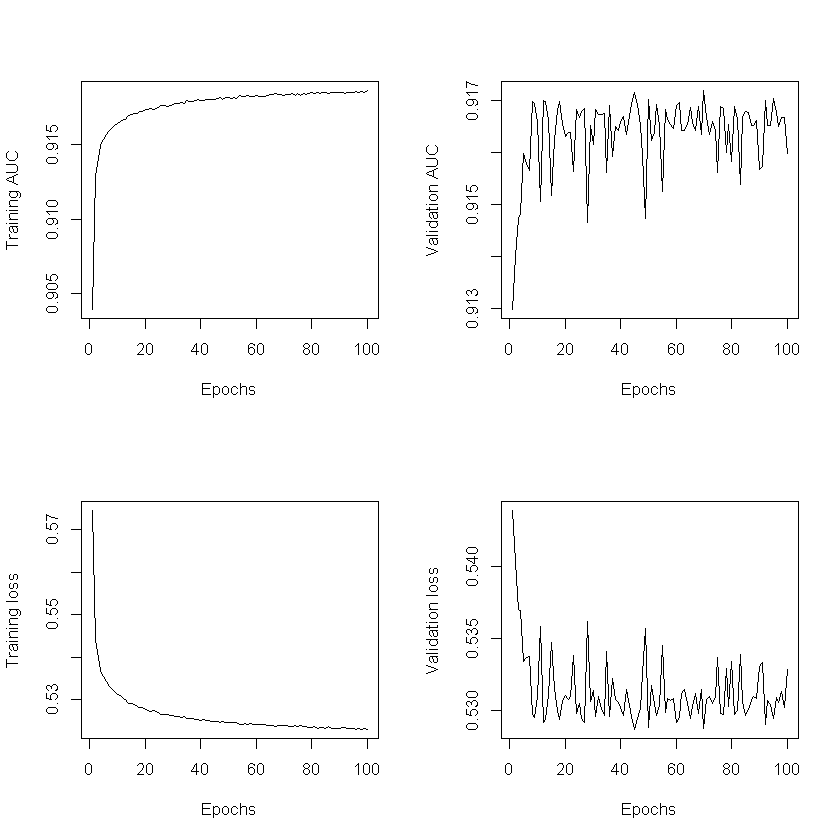

[1] "F1-Score Micro - 3 fold - 100 epochs: 0.755767301905717"
  |============================                                          |  40%

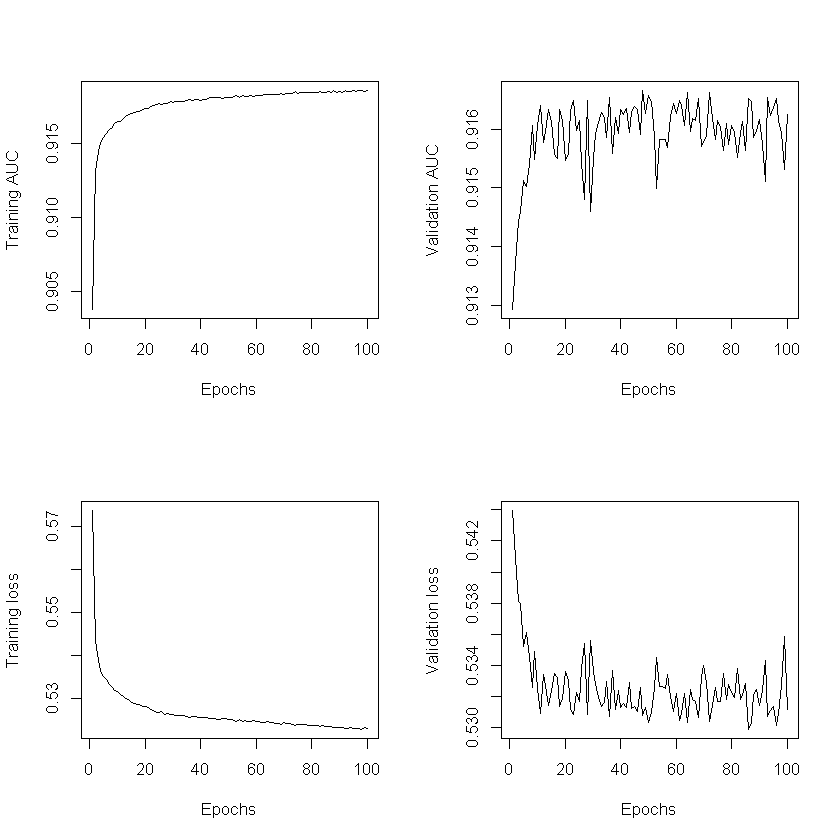

[1] "F1-Score Micro - 4 fold - 100 epochs: 0.755458683743538"
  |===================================                                   |  50%

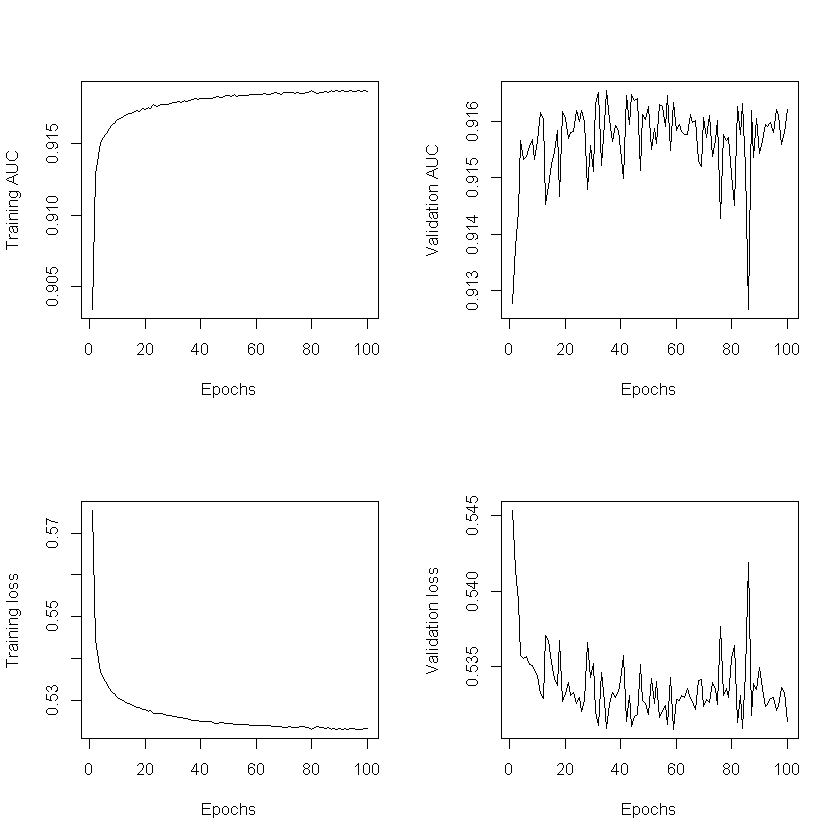

[1] "F1-Score Micro - 5 fold - 100 epochs: 0.7538384383921"
  |==========================================                            |  60%

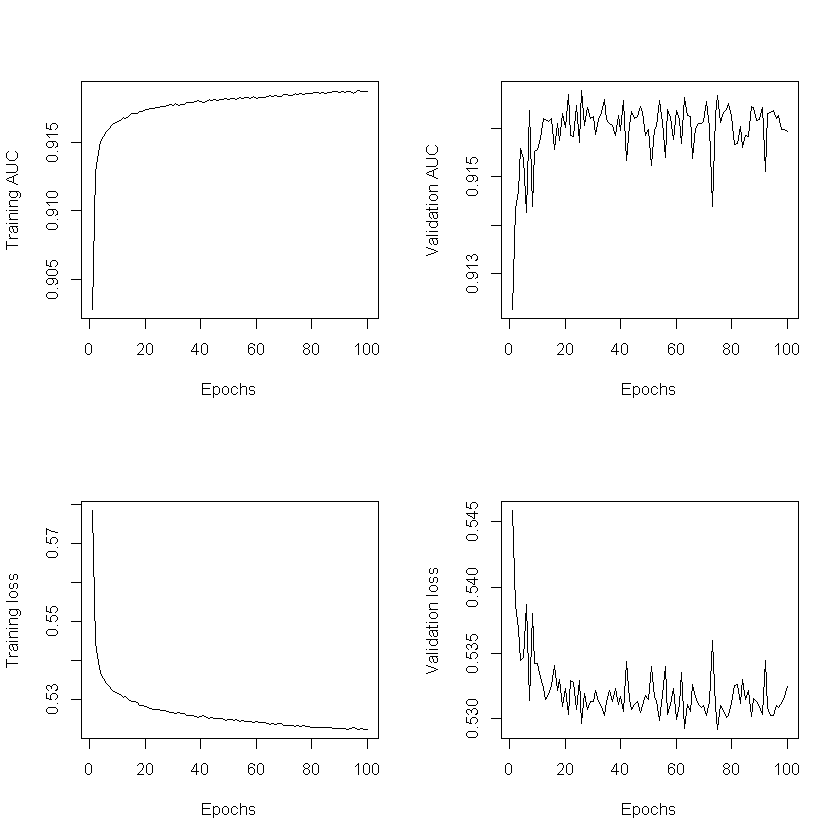

[1] "F1-Score Micro - 6 fold - 100 epochs: 0.751870997608209"
  |=================================================                     |  70%

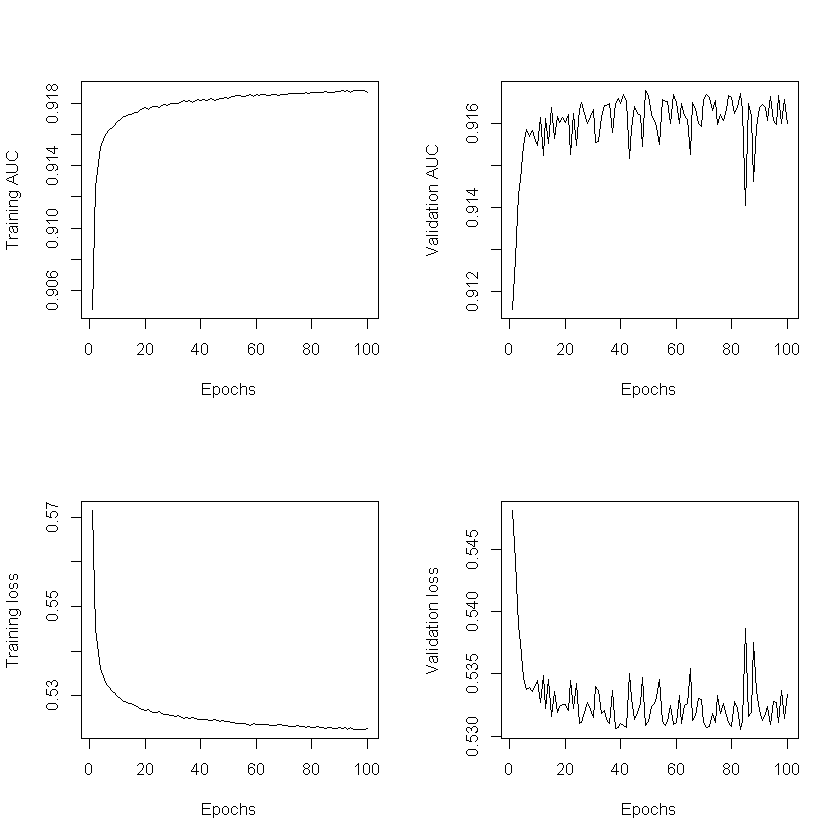

[1] "F1-Score Micro - 7 fold - 100 epochs: 0.755265797392176"
  |========================================================              |  80%

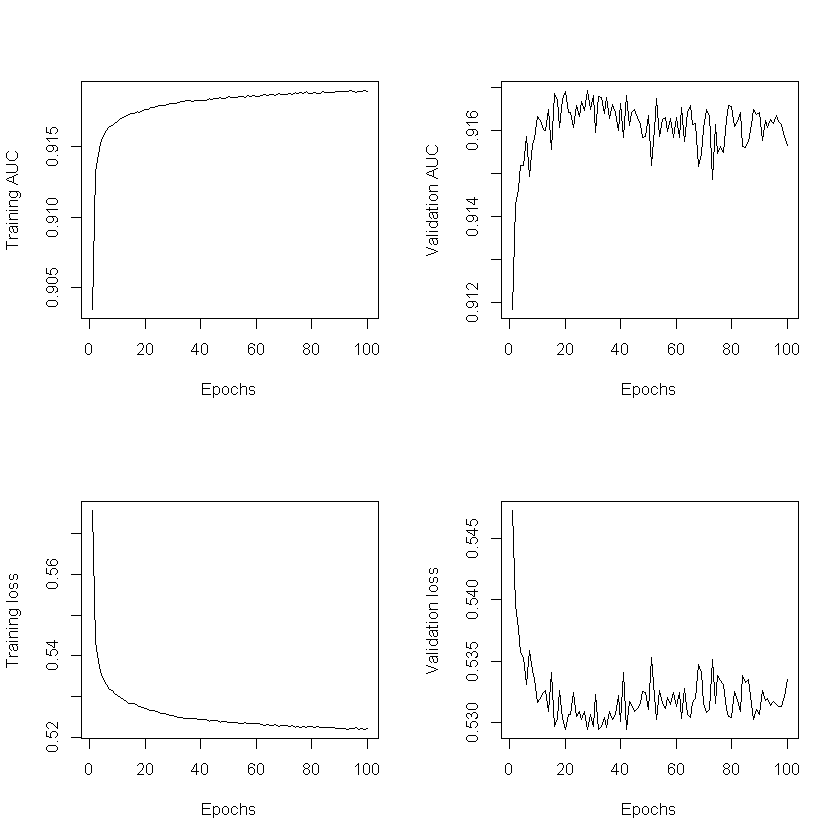

[1] "F1-Score Micro - 8 fold - 100 epochs: 0.756500270040892"
  |===============================================================       |  90%

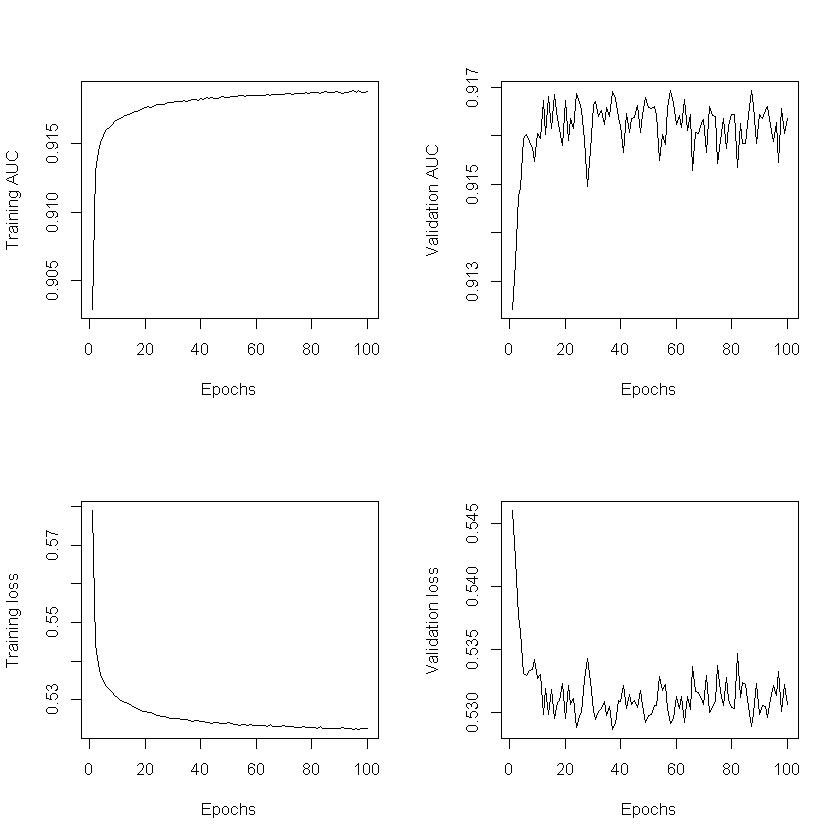

[1] "F1-Score Micro - 9 fold - 100 epochs: 0.757348969986884"
  |======================================================================| 100%

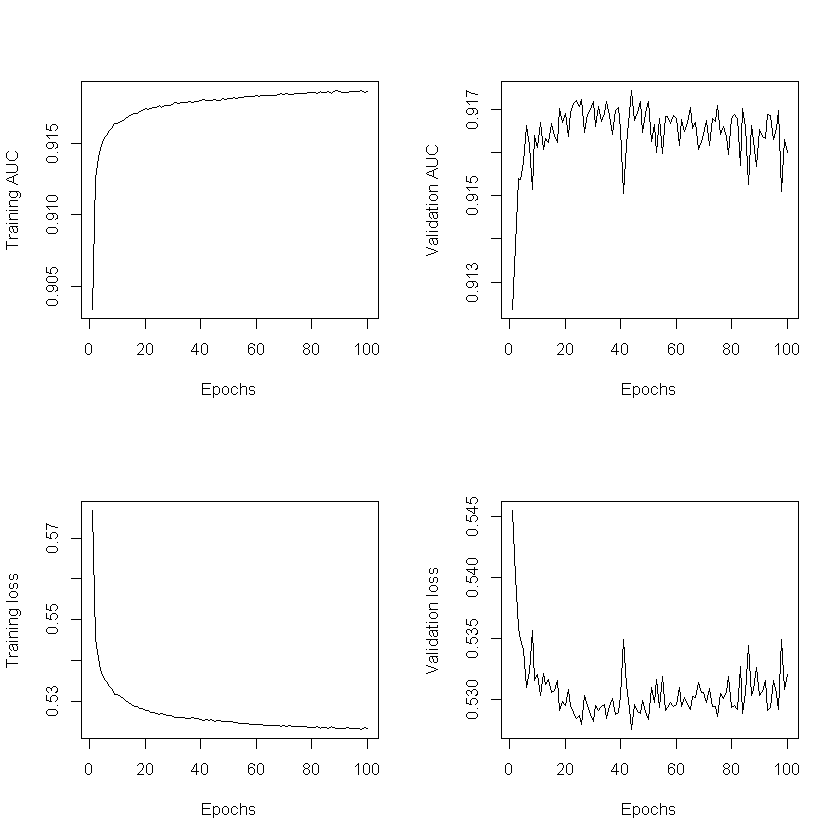

[1] "F1-Score Micro - 10 fold - 100 epochs: 0.754563346582796"


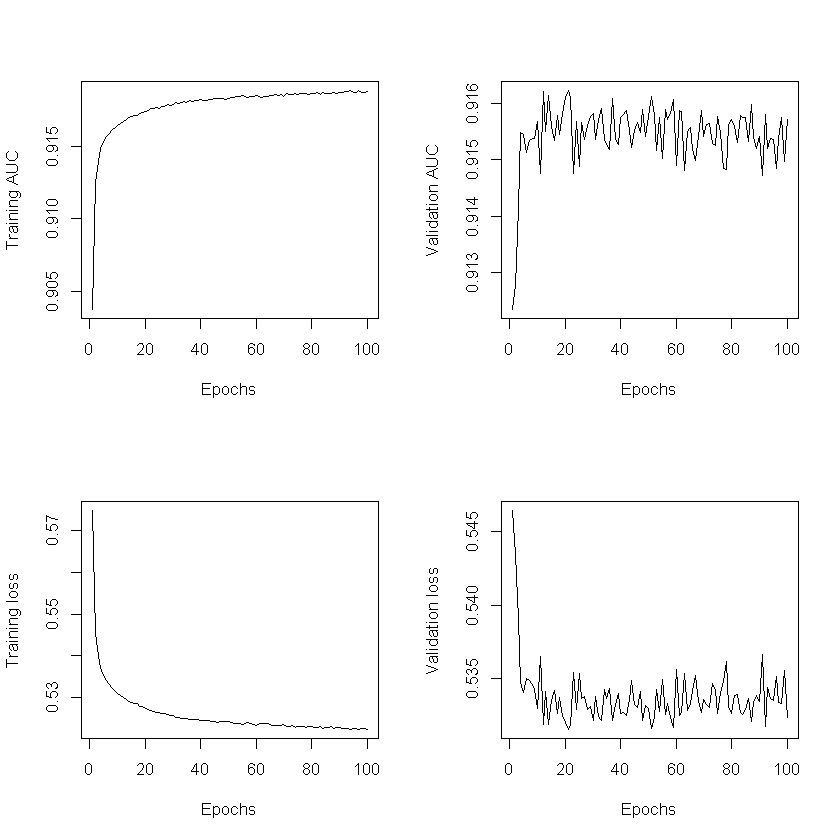

[1] "Mean F1-Score Micro: 0.755129970951776"


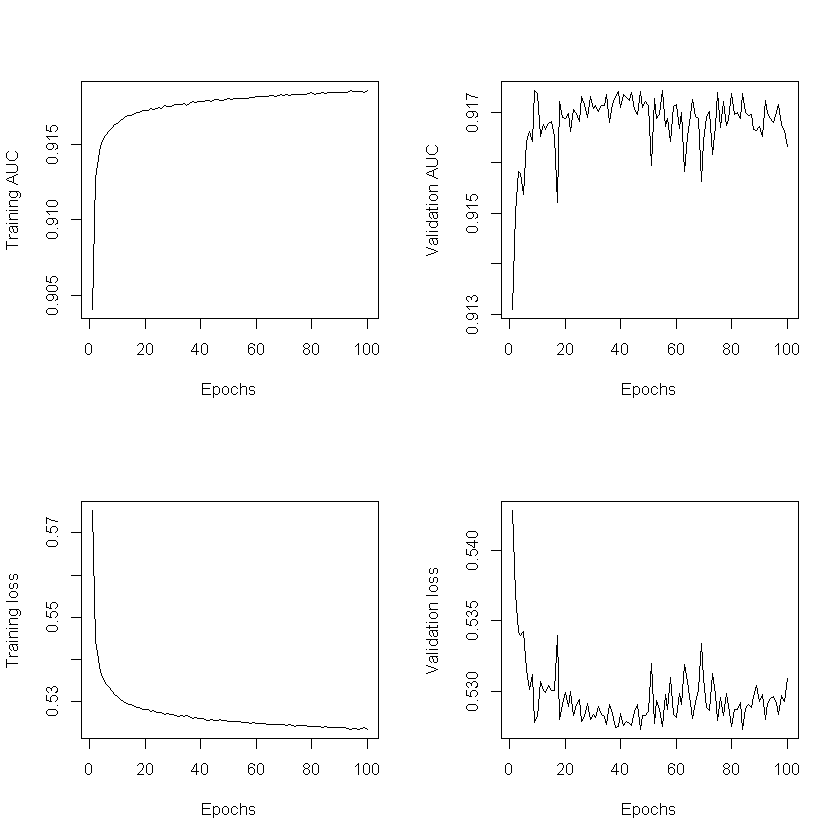

In [25]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(37, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 100
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 5*j,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x=x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - 30 epochs: 0.75893063806805"
  |==============                                                        |  20%[1] "F1-Score Micro - 2 fold - 30 epochs: 0.756693156392254"
  |=====================                                                 |  30%

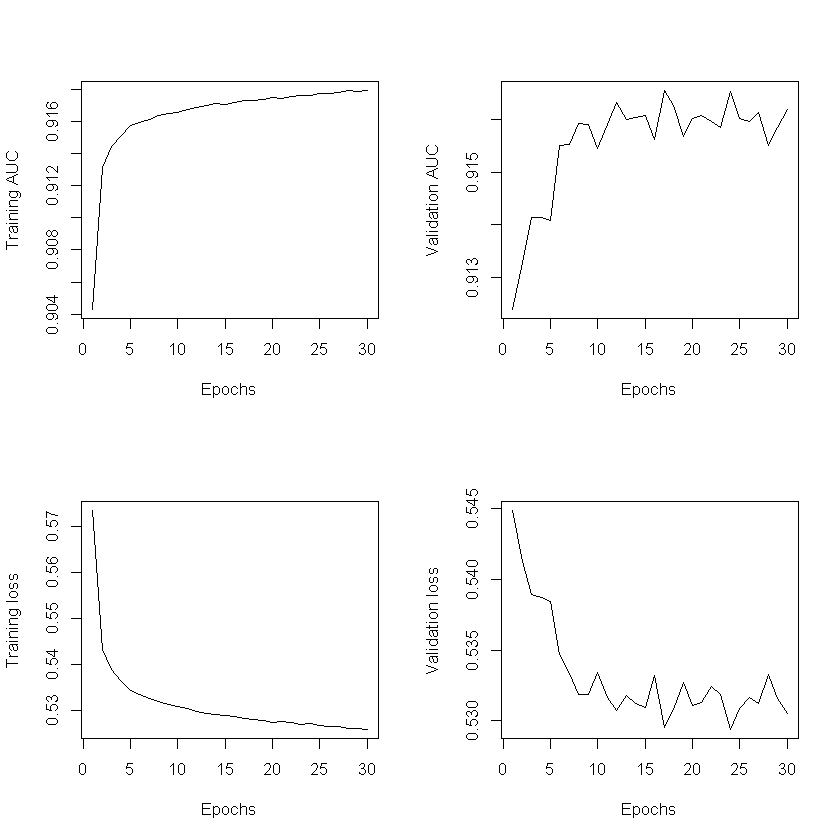

[1] "F1-Score Micro - 3 fold - 30 epochs: 0.753182624797469"
  |============================                                          |  40%

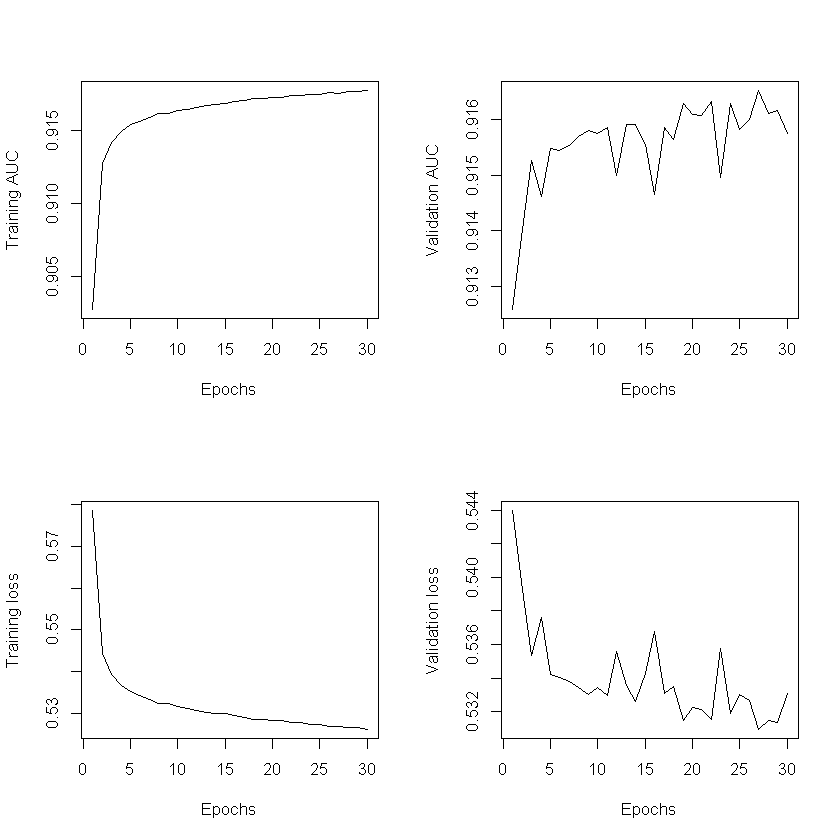

[1] "F1-Score Micro - 4 fold - 30 epochs: 0.754609983797546"
  |===================================                                   |  50%

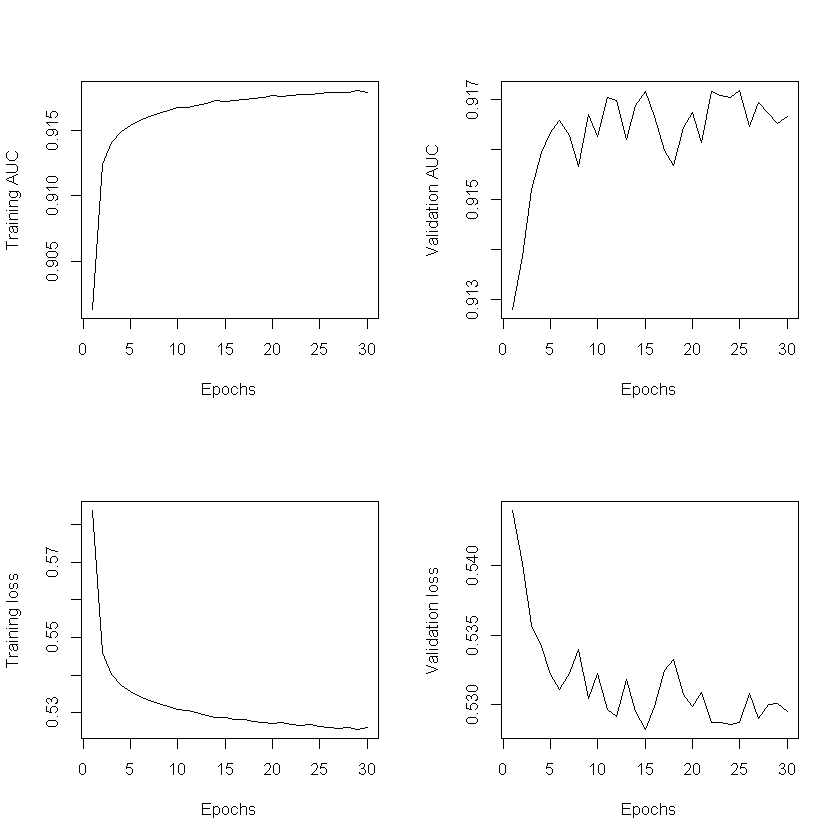

[1] "F1-Score Micro - 5 fold - 30 epochs: 0.750212174986498"
  |==========================================                            |  60%

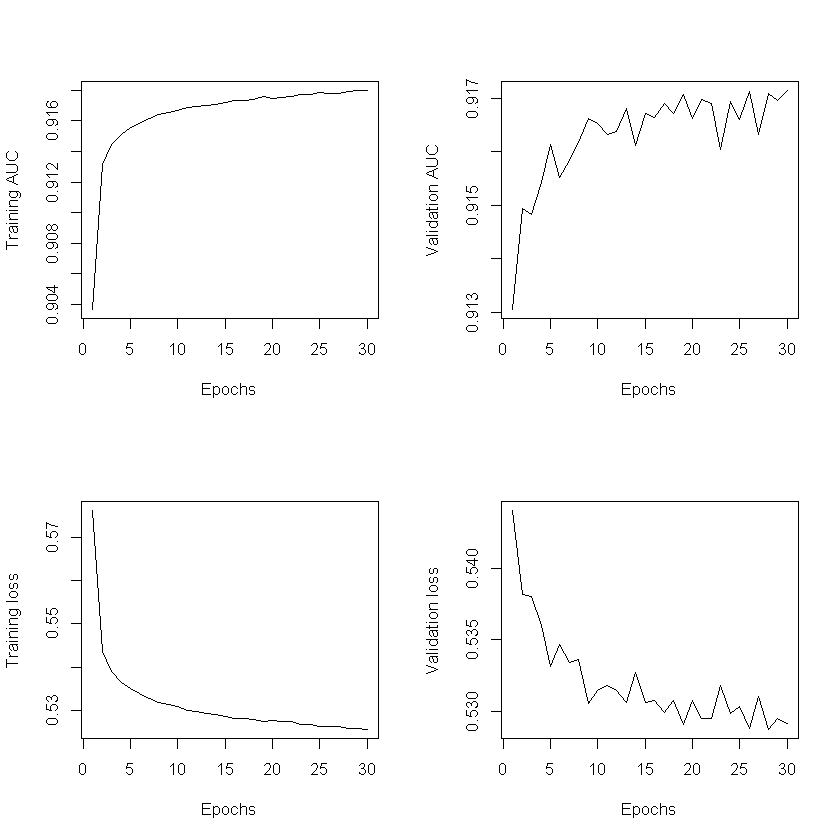

[1] "F1-Score Micro - 6 fold - 30 epochs: 0.755690147365172"
  |=================================================                     |  70%

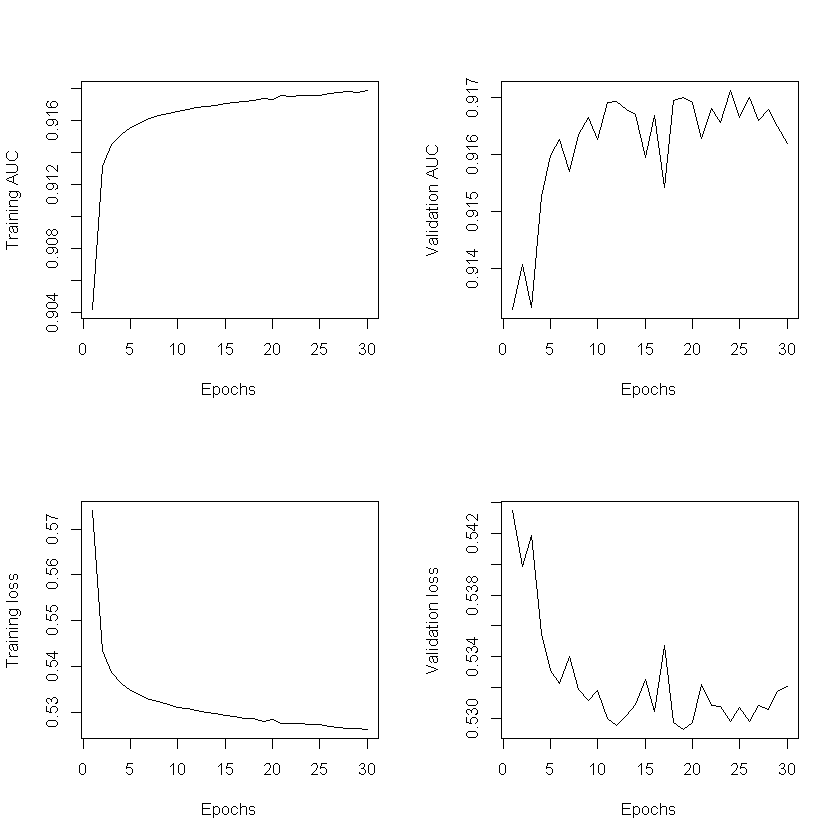

[1] "F1-Score Micro - 7 fold - 30 epochs: 0.752989738446108"
  |========================================================              |  80%

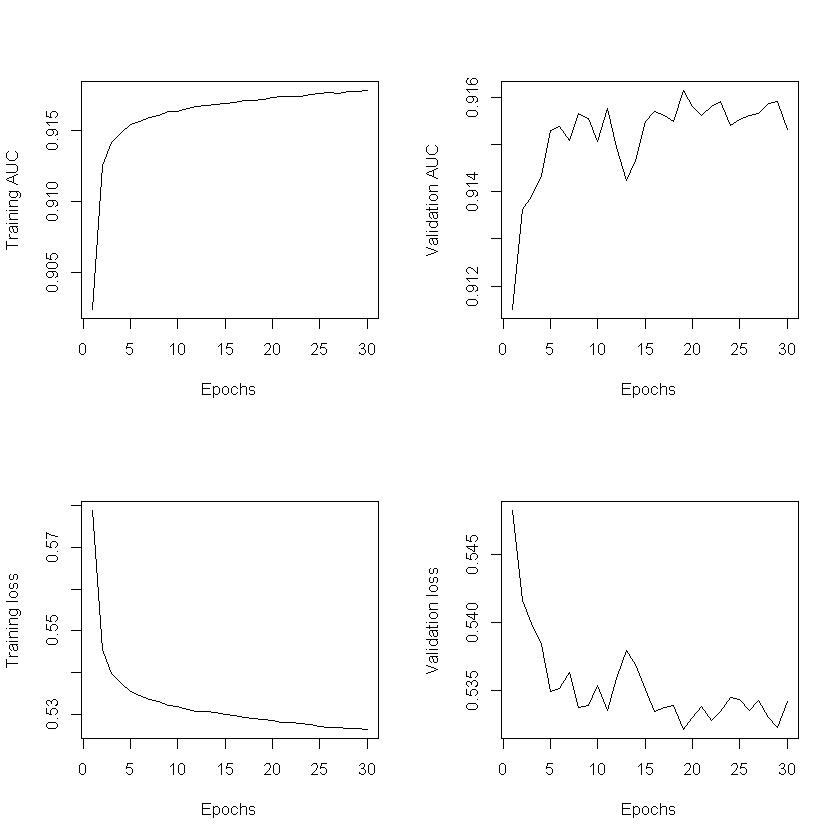

[1] "F1-Score Micro - 8 fold - 30 epochs: 0.758390556284237"
  |===============================================================       |  90%

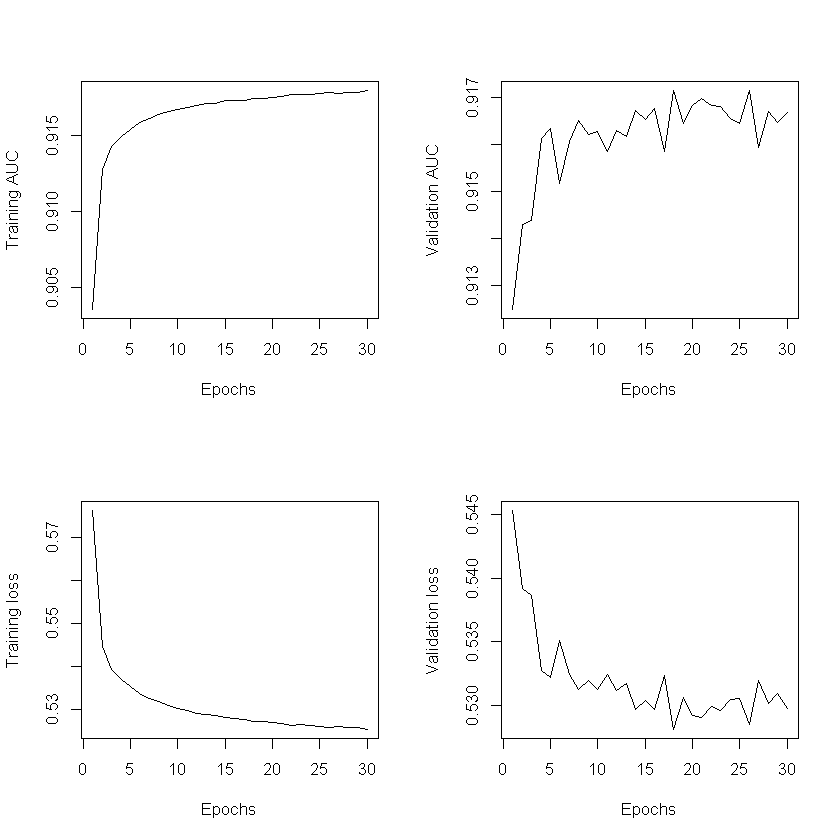

[1] "F1-Score Micro - 9 fold - 30 epochs: 0.753761283851555"
  |======================================================================| 100%

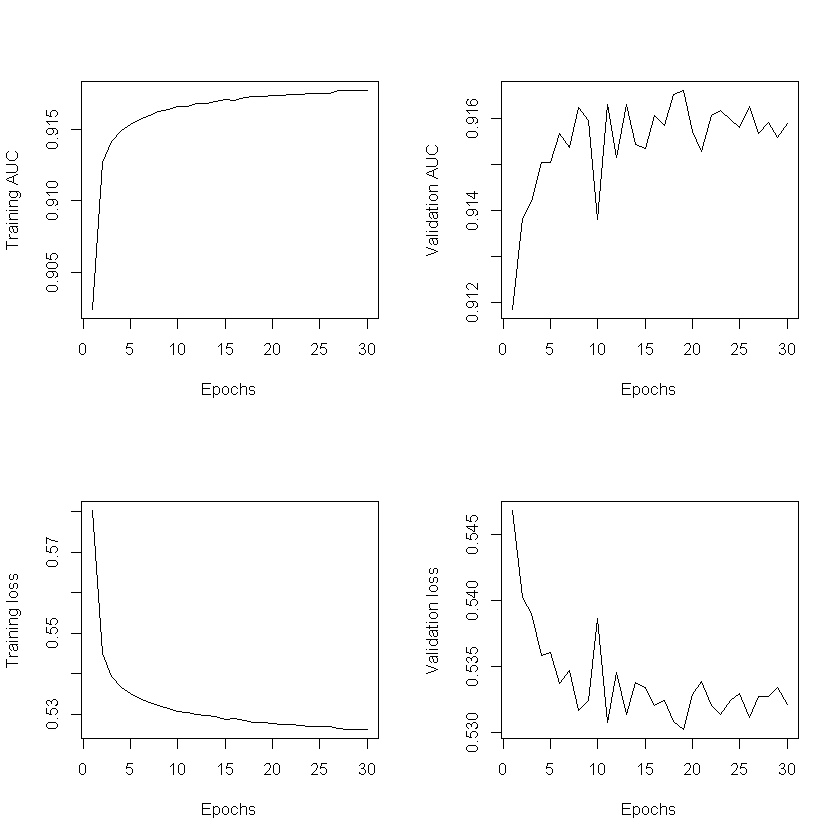

[1] "F1-Score Micro - 10 fold - 30 epochs: 0.759695905530043"


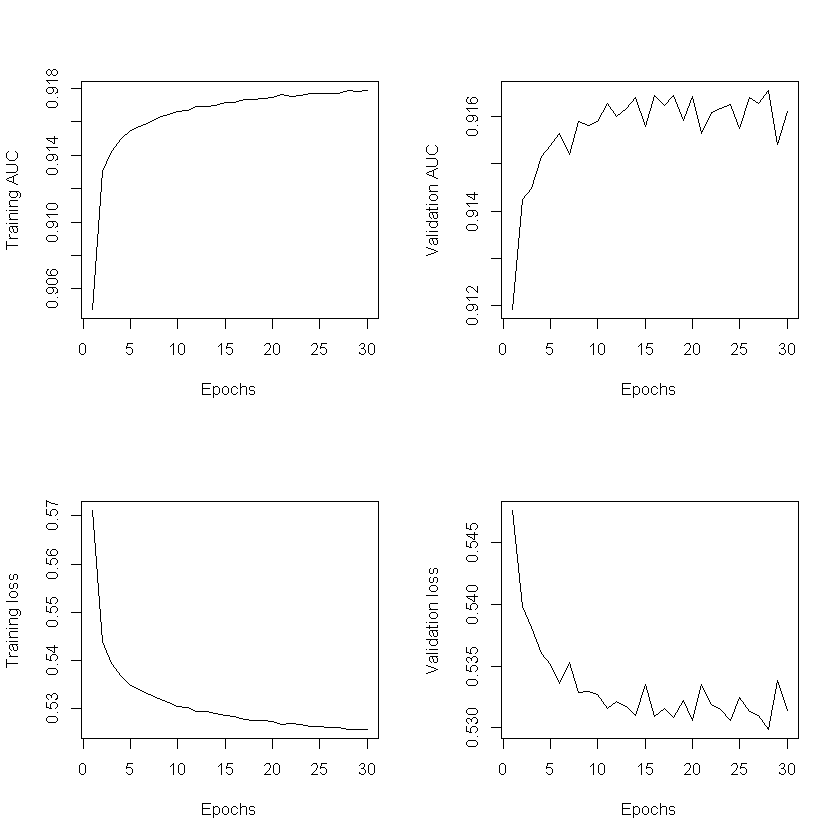

[1] "Mean F1-Score Micro: 0.755415620951893"


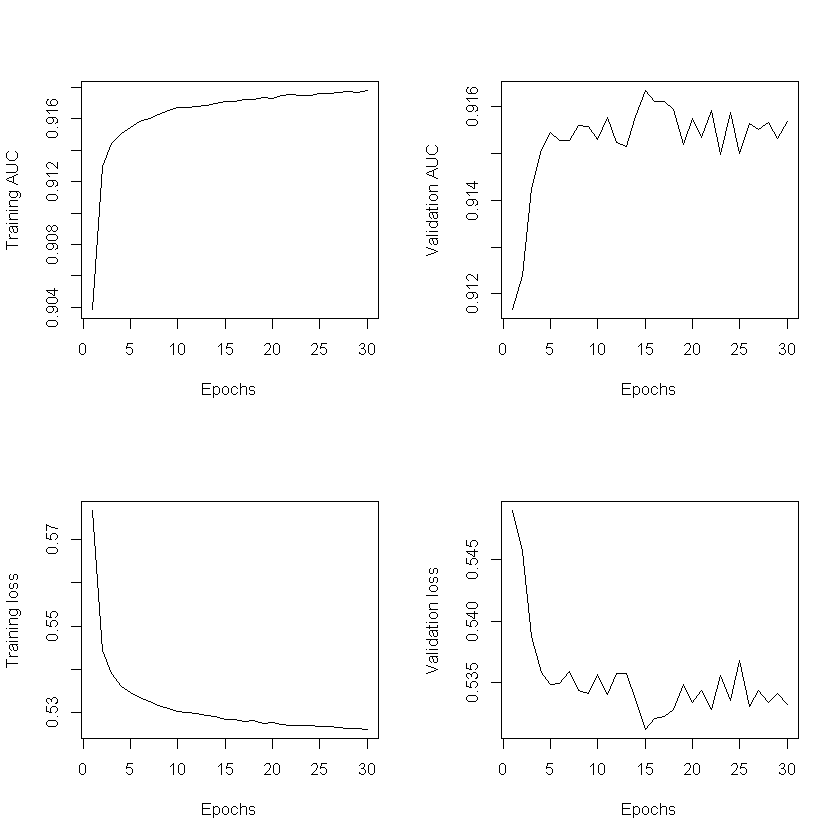

In [26]:
k = 10

accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)
target_indices<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in 6:6){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(35, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(0.001),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]


        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_indices]),
        as.matrix(train_data[,target_indices]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 5*j
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_indices]))

        yhaty <- classConverter(yhat,test_data)

        accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -", 5*j,'epochs:',accuracy_vec[i]))
        par(mfrow=c(2,2)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='Training AUC')
        plot(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',xlab="Epochs",ylab='Validation AUC')
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Training loss')
        plot(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',xlab="Epochs",ylab='Validation loss')
        rm('neuralmodel','model_history')
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - Learning rate 1e-04 :  0.756230229148985"
[1] "F1-Score Micro - 1 fold - Learning rate 5e-04 :  0.755535838284083"


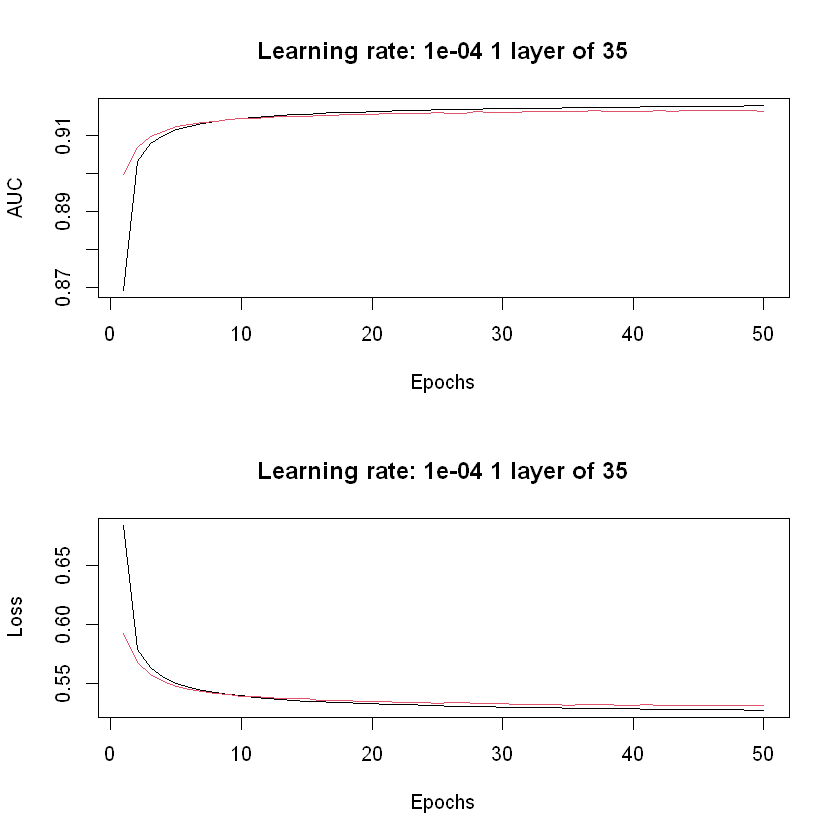

[1] "F1-Score Micro - 1 fold - Learning rate 0.001 :  0.757078929094977"


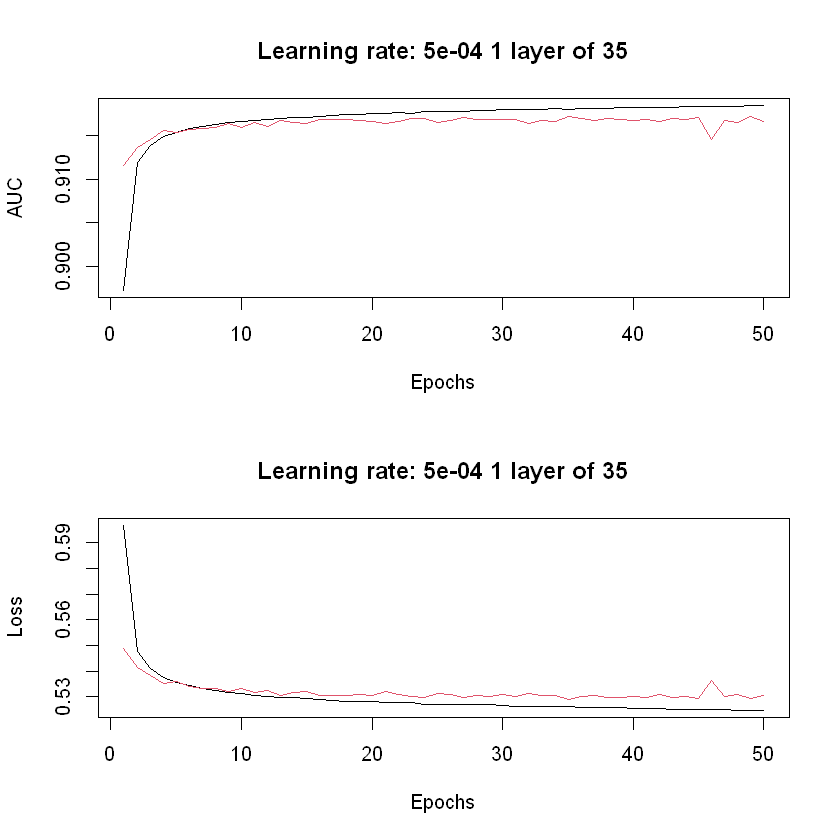

[1] "F1-Score Micro - 1 fold - Learning rate 0.005 :  0.751215184013579"
  |==============                                                        |  20%

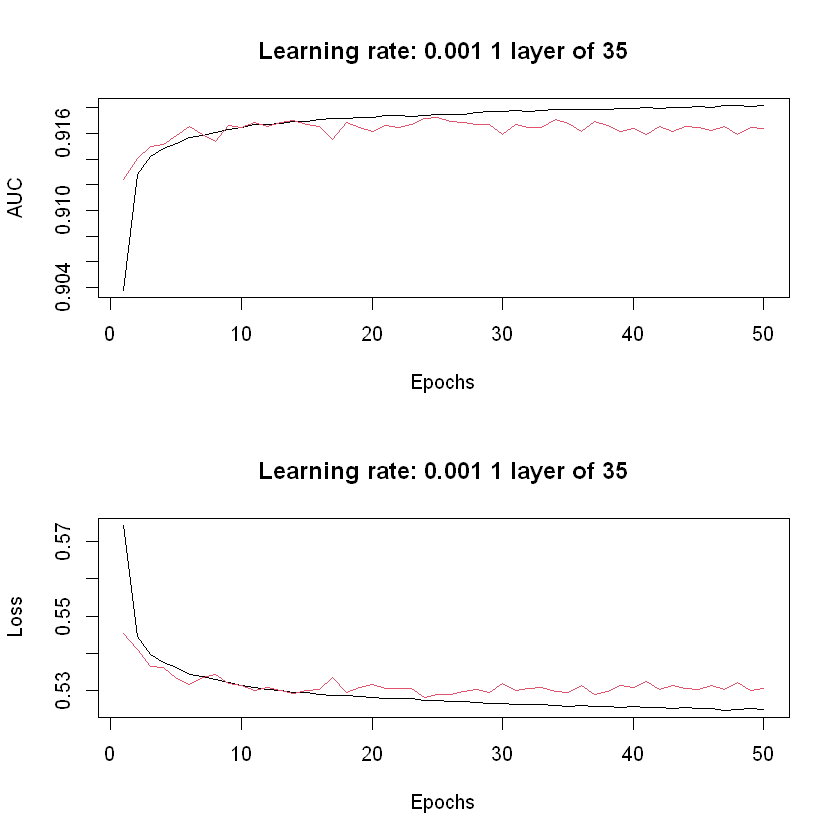

[1] "F1-Score Micro - 2 fold - Learning rate 1e-04 :  0.759239256230229"


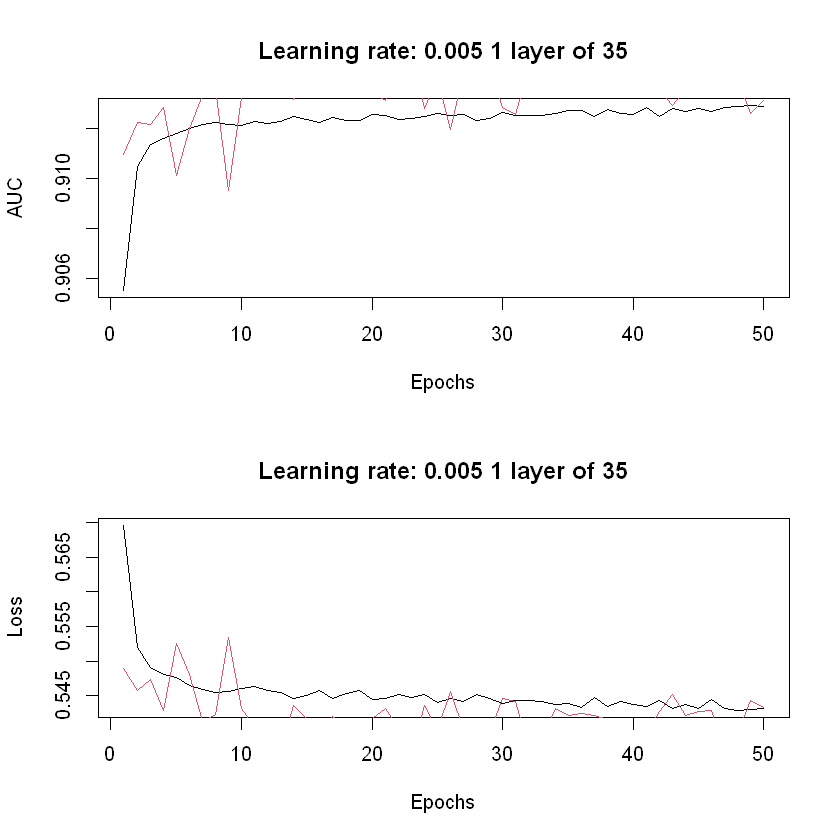

[1] "F1-Score Micro - 2 fold - Learning rate 5e-04 :  0.759200678959957"


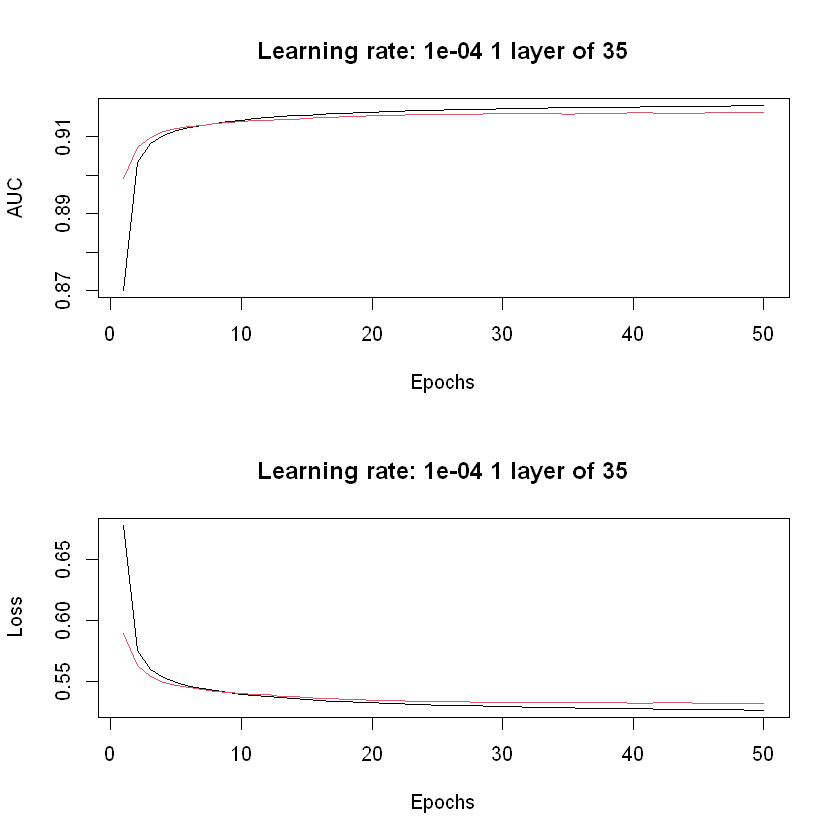

[1] "F1-Score Micro - 2 fold - Learning rate 0.001 :  0.75958645166268"


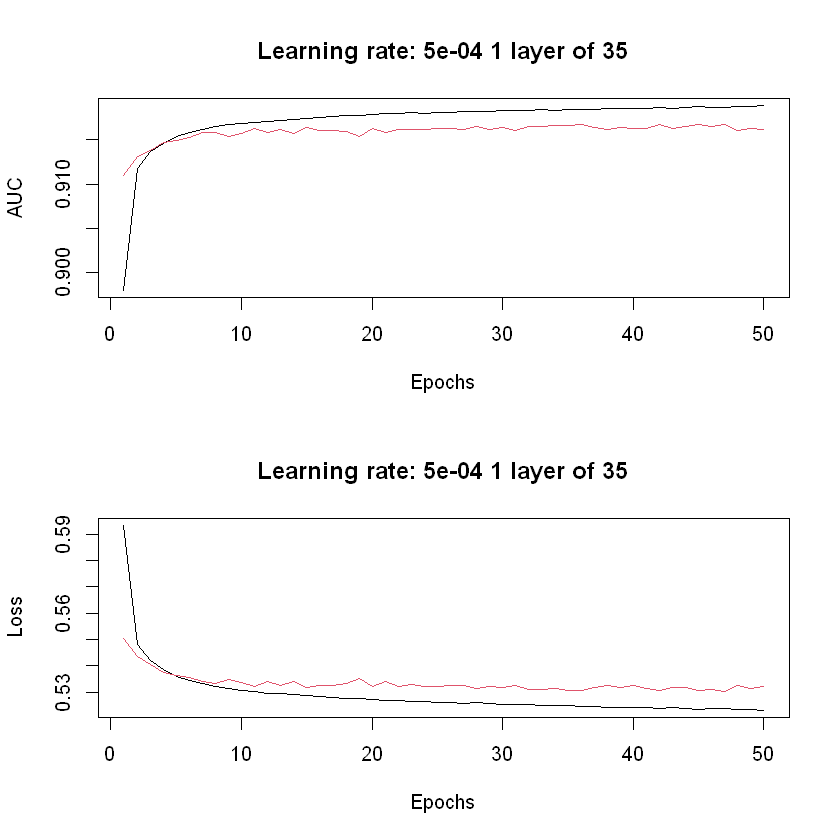

[1] "F1-Score Micro - 2 fold - Learning rate 0.005 :  0.758043360851786"
  |=====================                                                 |  30%

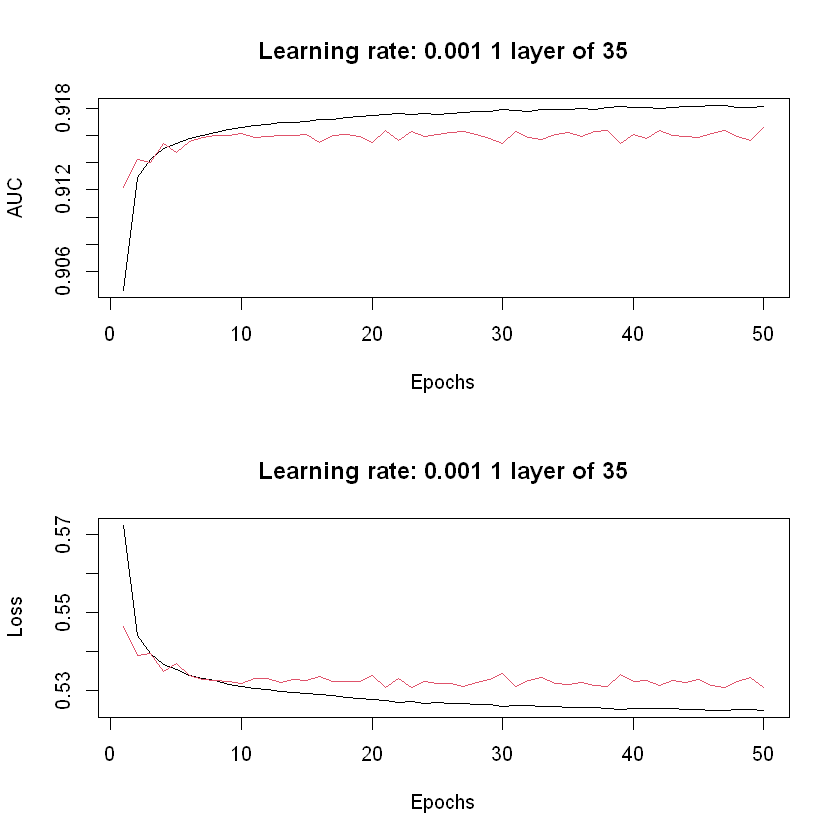

[1] "F1-Score Micro - 3 fold - Learning rate 1e-04 :  0.753568397500193"


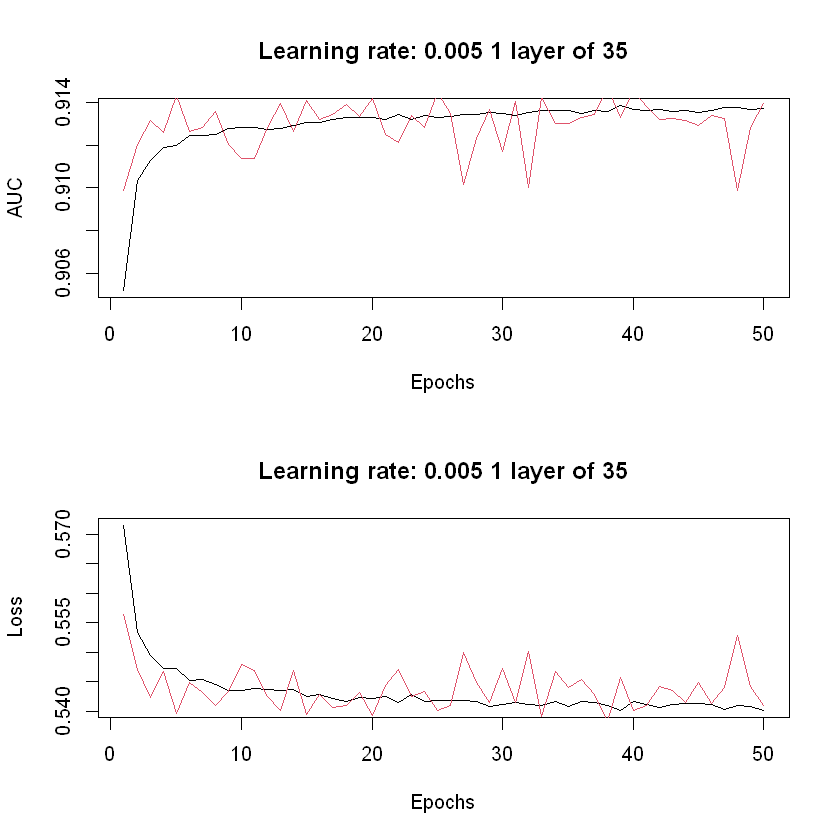

[1] "F1-Score Micro - 3 fold - Learning rate 5e-04 :  0.755497261013811"


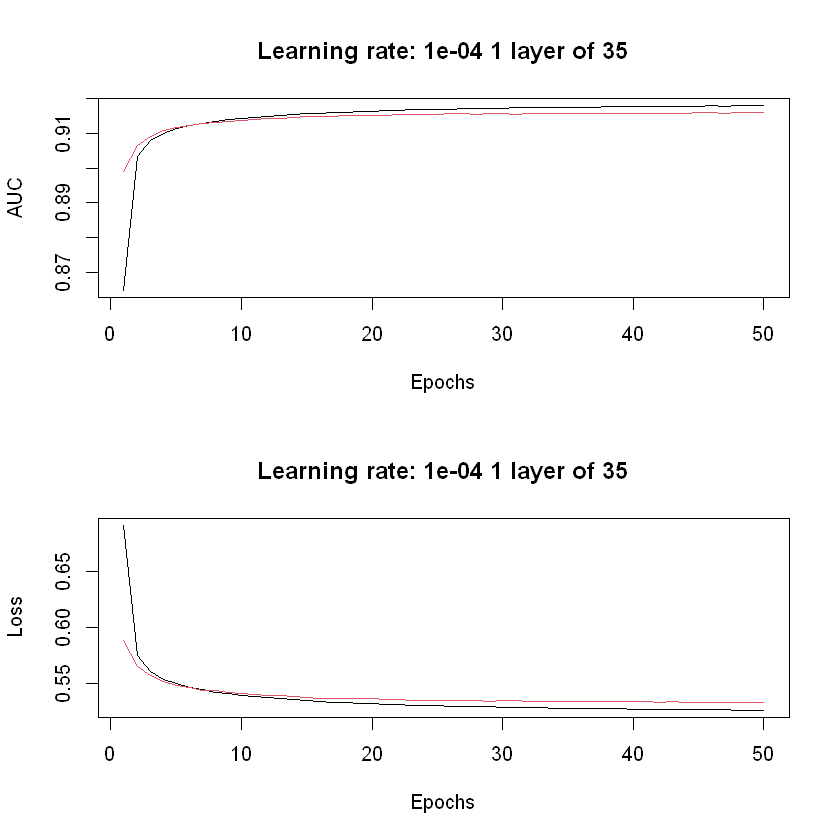

[1] "F1-Score Micro - 3 fold - Learning rate 0.001 :  0.754069902013733"


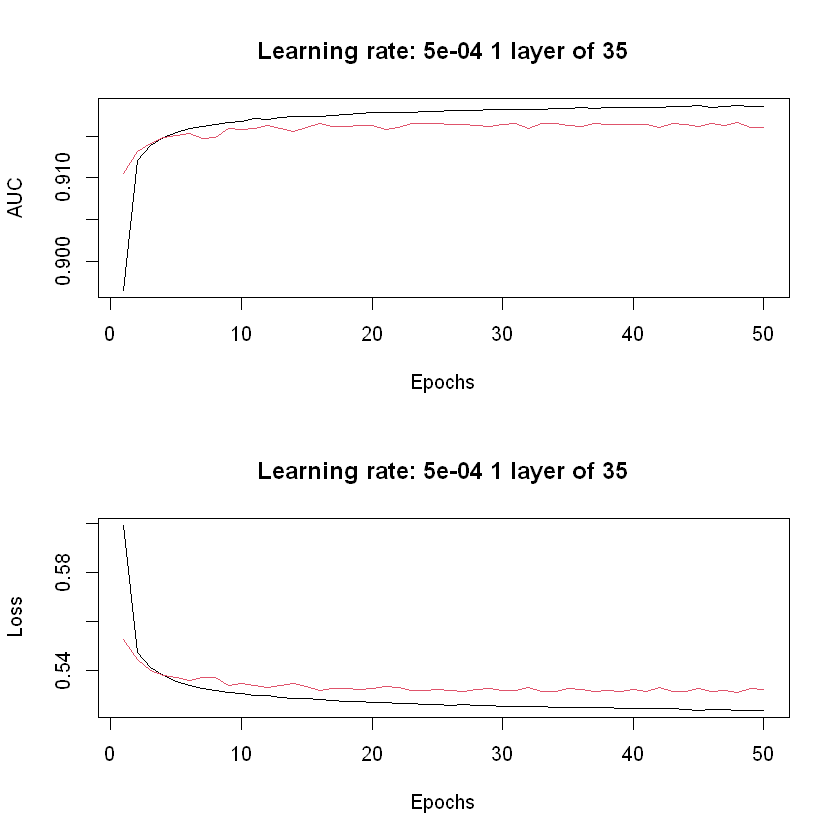

[1] "F1-Score Micro - 3 fold - Learning rate 0.005 :  0.748321888743153"
  |============================                                          |  40%

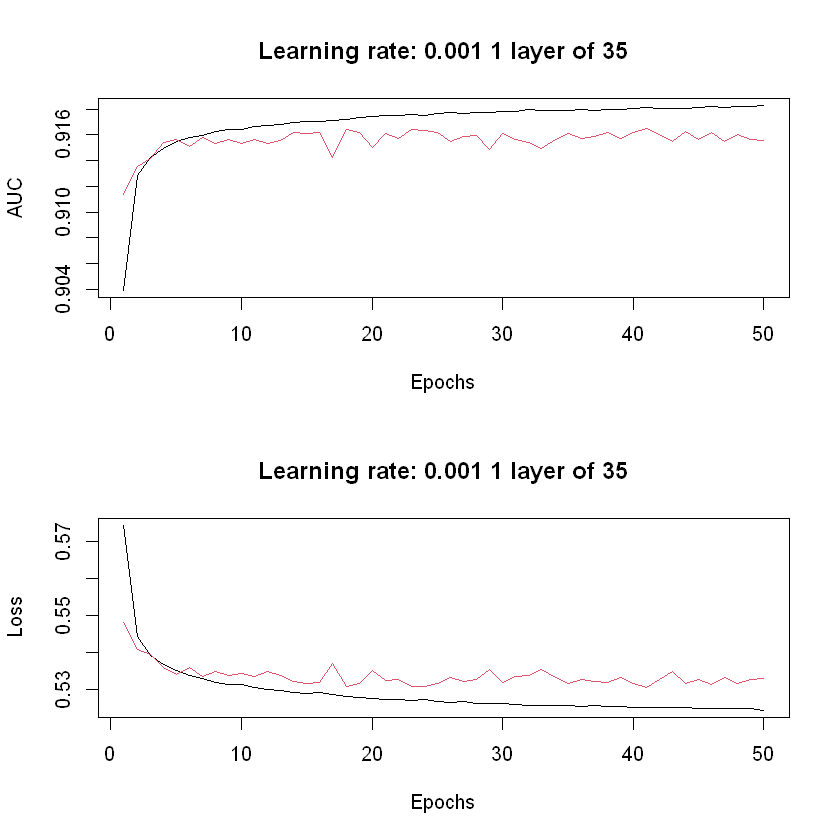

[1] "F1-Score Micro - 4 fold - Learning rate 1e-04 :  0.757966206311241"


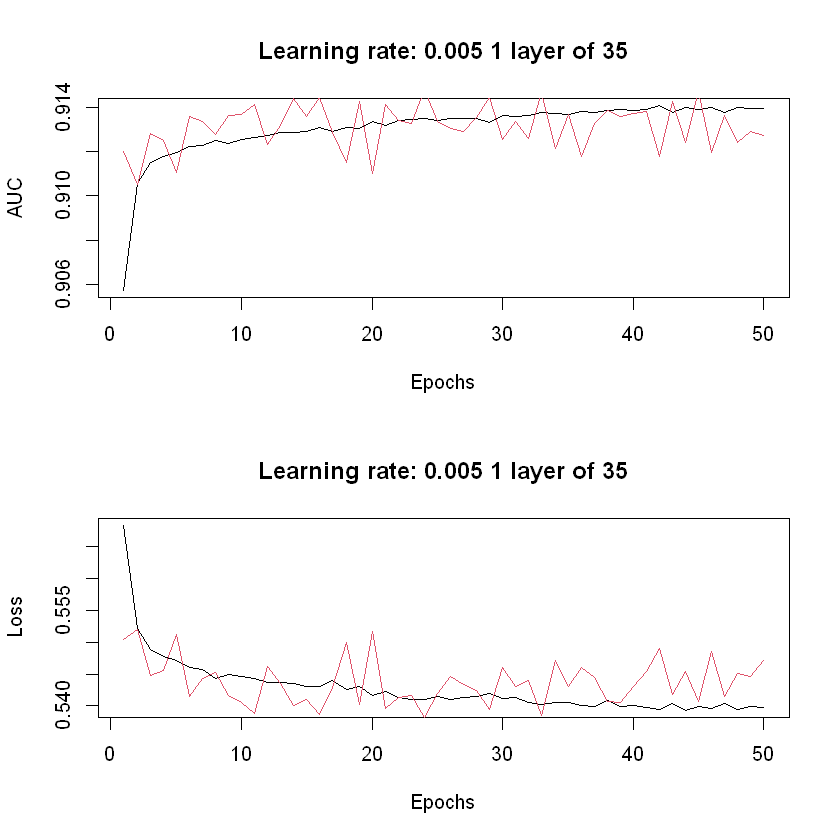

[1] "F1-Score Micro - 4 fold - Learning rate 5e-04 :  0.756268806419258"


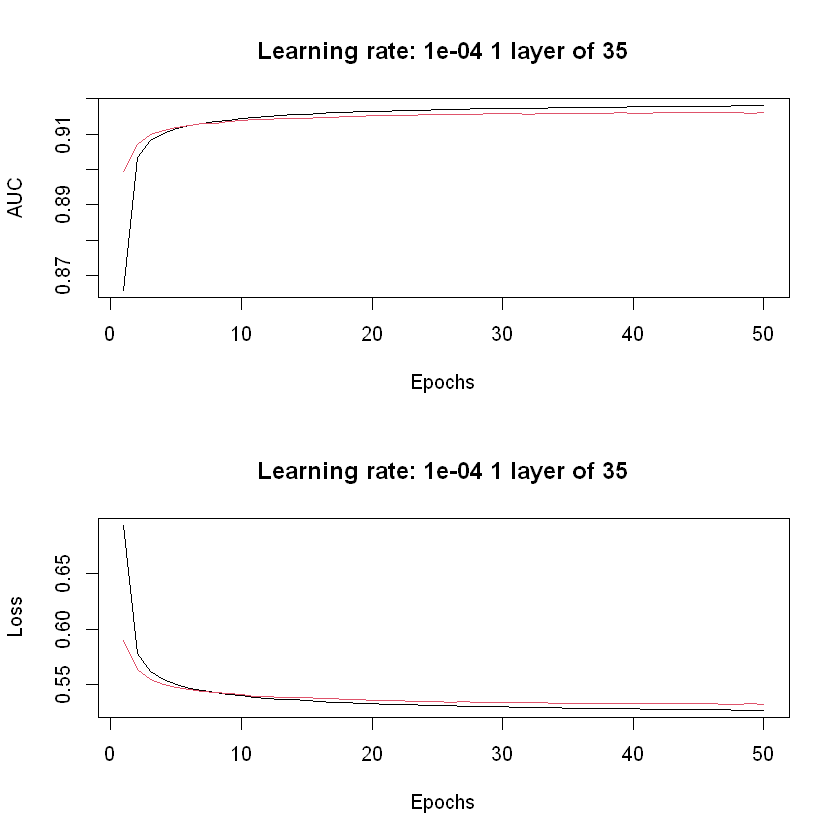

[1] "F1-Score Micro - 4 fold - Learning rate 0.001 :  0.754687138338091"


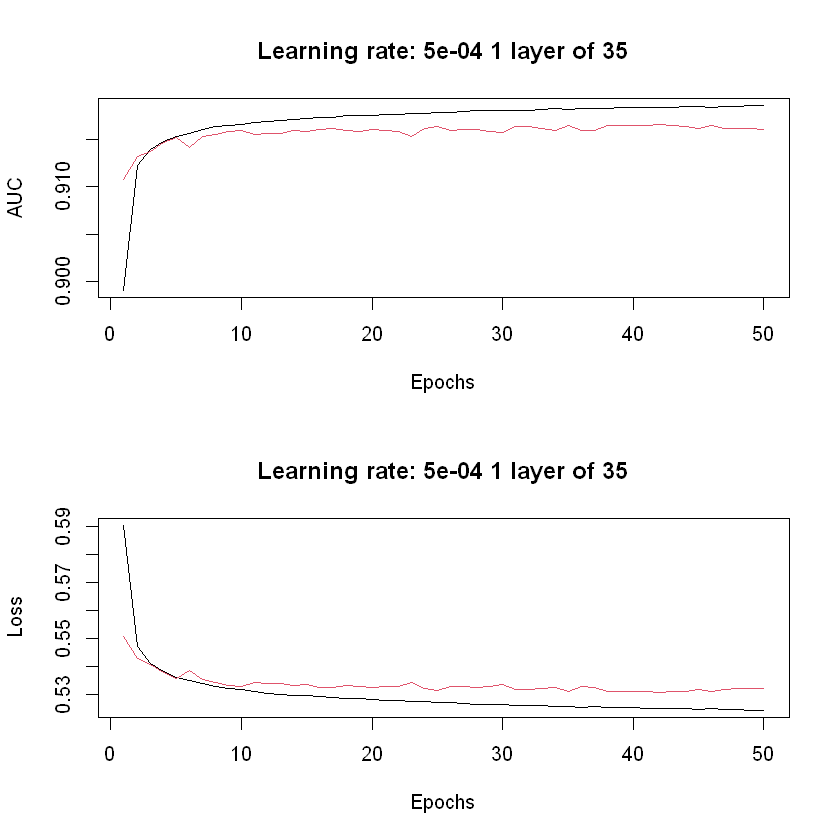

[1] "F1-Score Micro - 4 fold - Learning rate 0.005 :  0.75237250212175"
  |===================================                                   |  50%

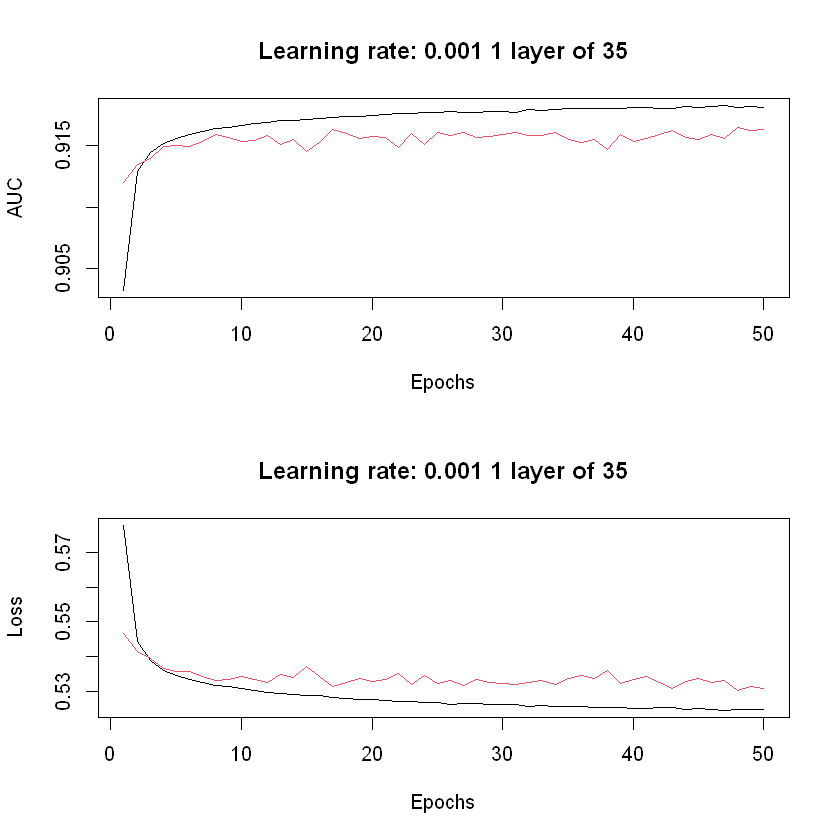

[1] "F1-Score Micro - 5 fold - Learning rate 1e-04 :  0.755150065581359"


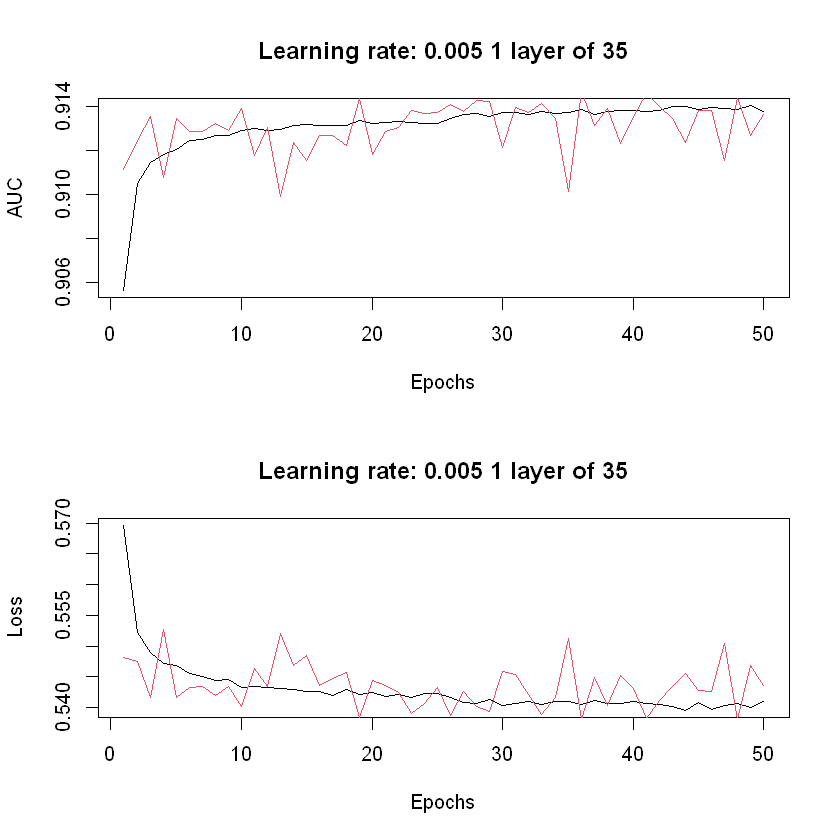

[1] "F1-Score Micro - 5 fold - Learning rate 5e-04 :  0.756191651878713"


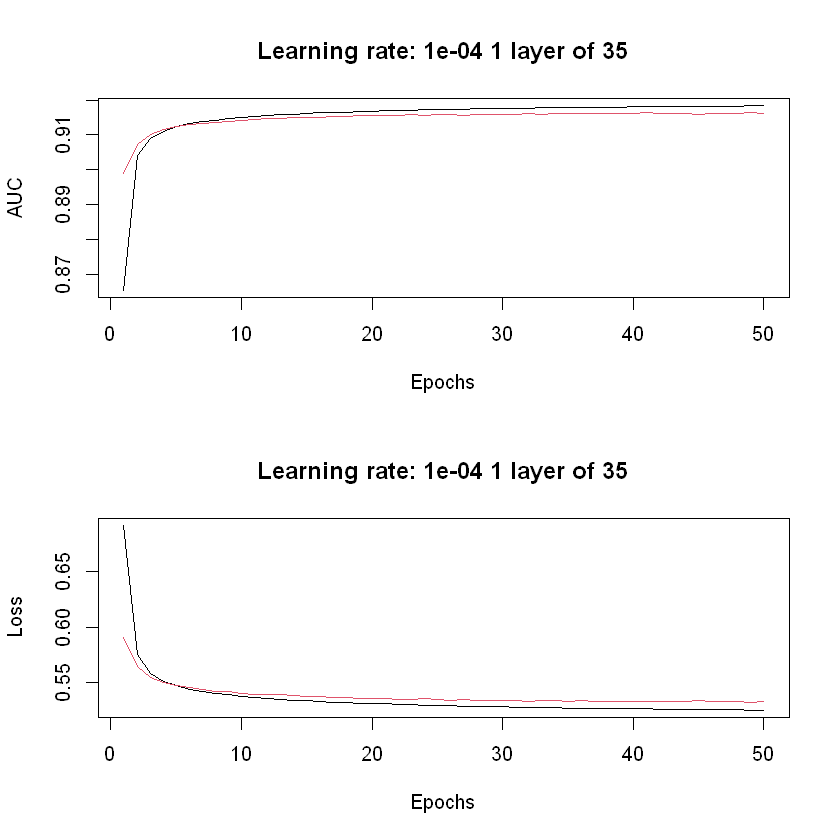

[1] "F1-Score Micro - 5 fold - Learning rate 0.001 :  0.755265797392176"


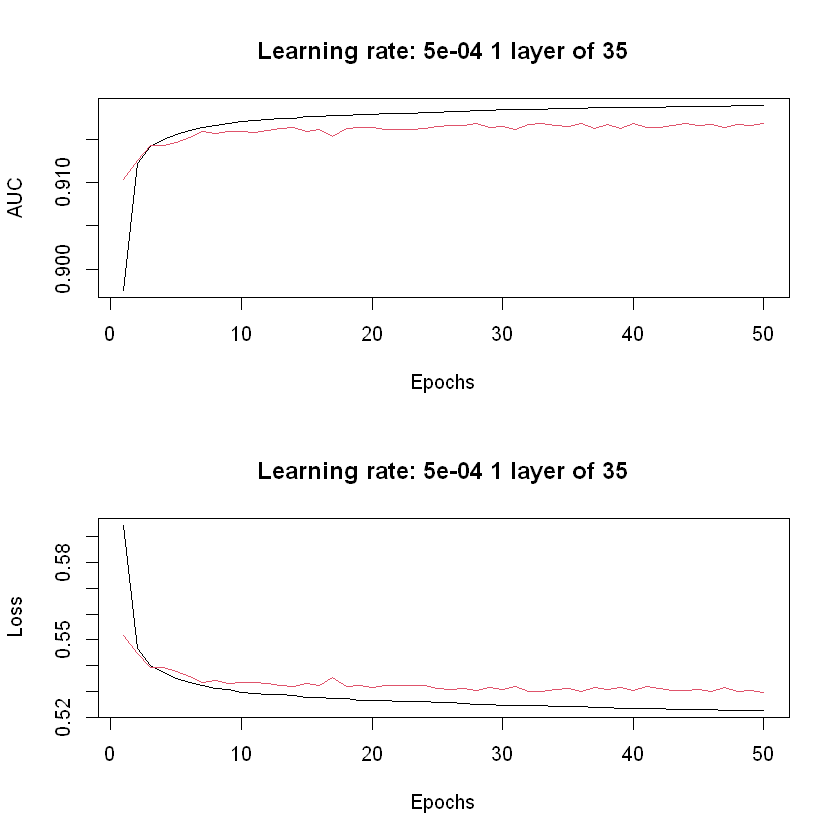

[1] "F1-Score Micro - 5 fold - Learning rate 0.005 :  0.75237250212175"
  |==========================================                            |  60%

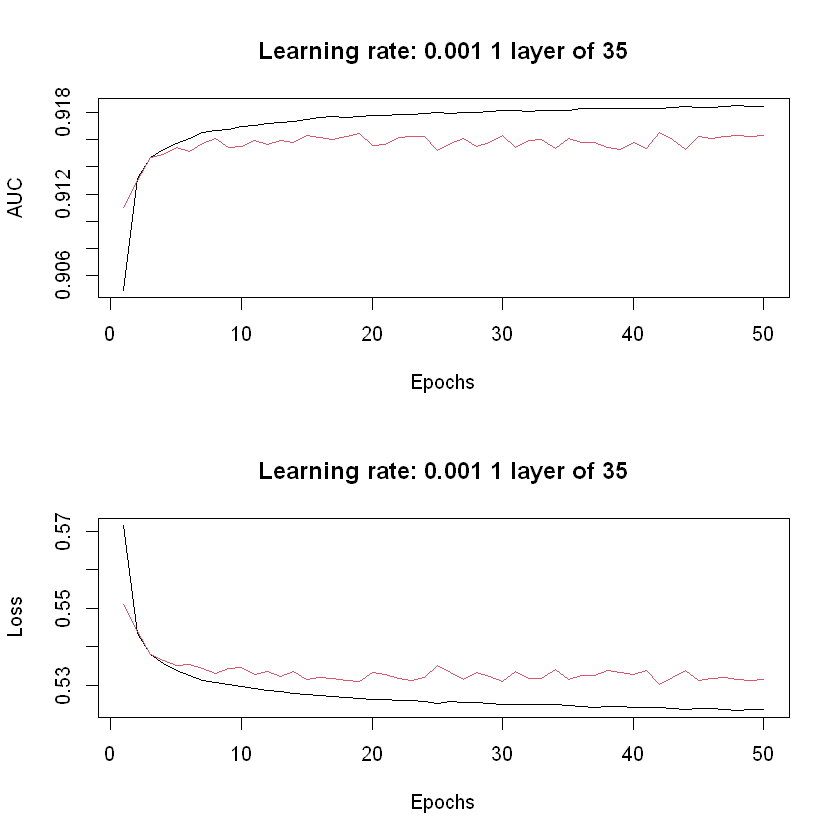

[1] "F1-Score Micro - 6 fold - Learning rate 1e-04 :  0.752063883959571"


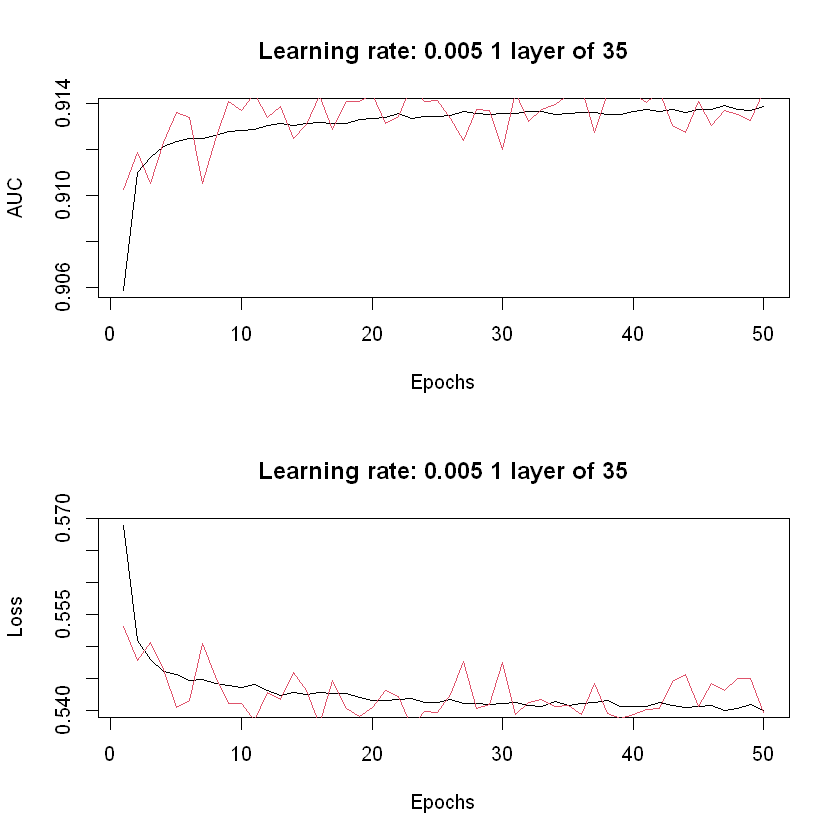

[1] "F1-Score Micro - 6 fold - Learning rate 5e-04 :  0.752565388473112"


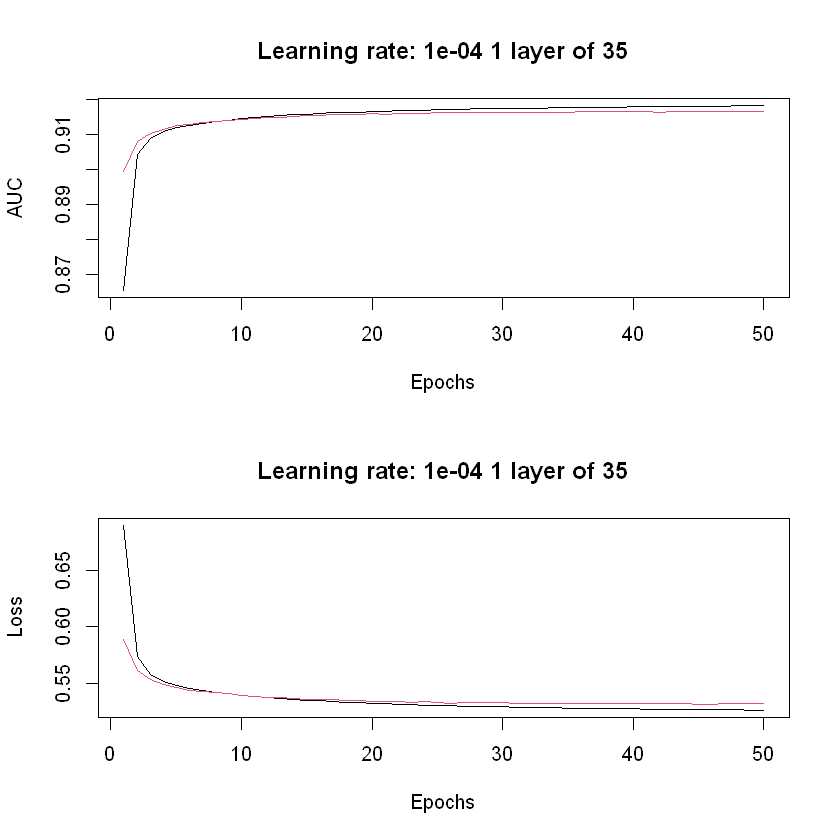

[1] "F1-Score Micro - 6 fold - Learning rate 0.001 :  0.751215184013579"


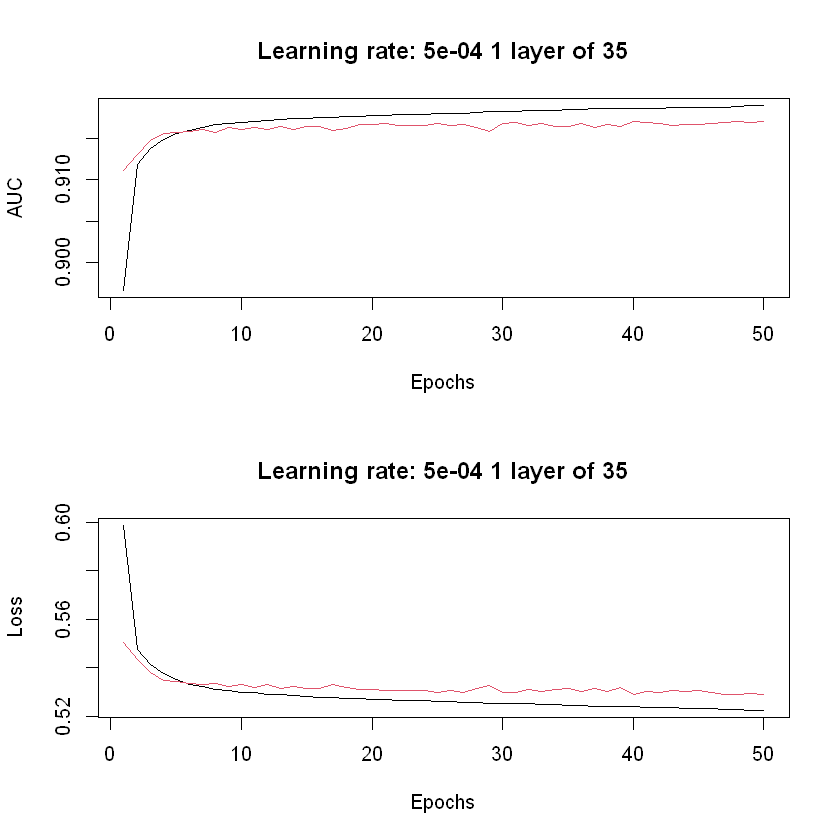

[1] "F1-Score Micro - 6 fold - Learning rate 0.005 :  0.745698634364632"
  |=================================================                     |  70%

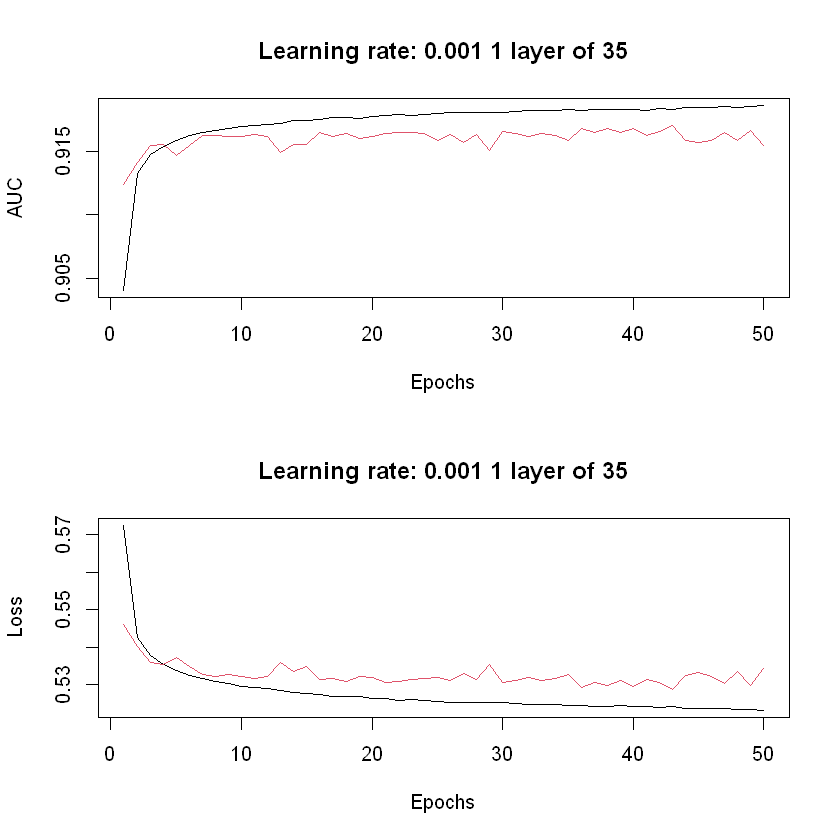

[1] "F1-Score Micro - 7 fold - Learning rate 1e-04 :  0.755883033716534"


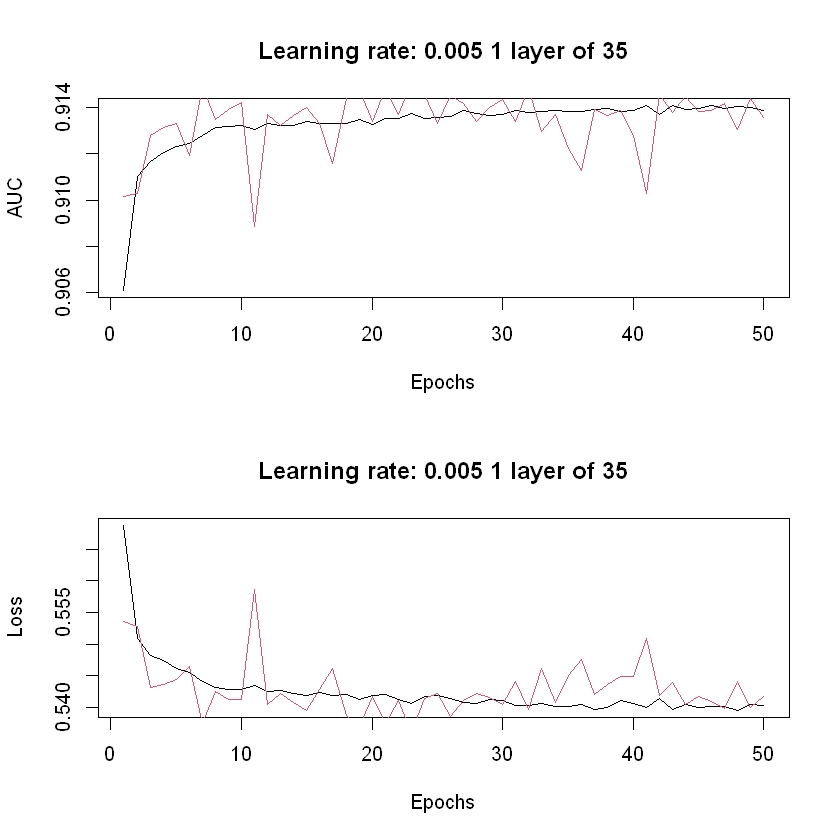

[1] "F1-Score Micro - 7 fold - Learning rate 5e-04 :  0.753414088419104"


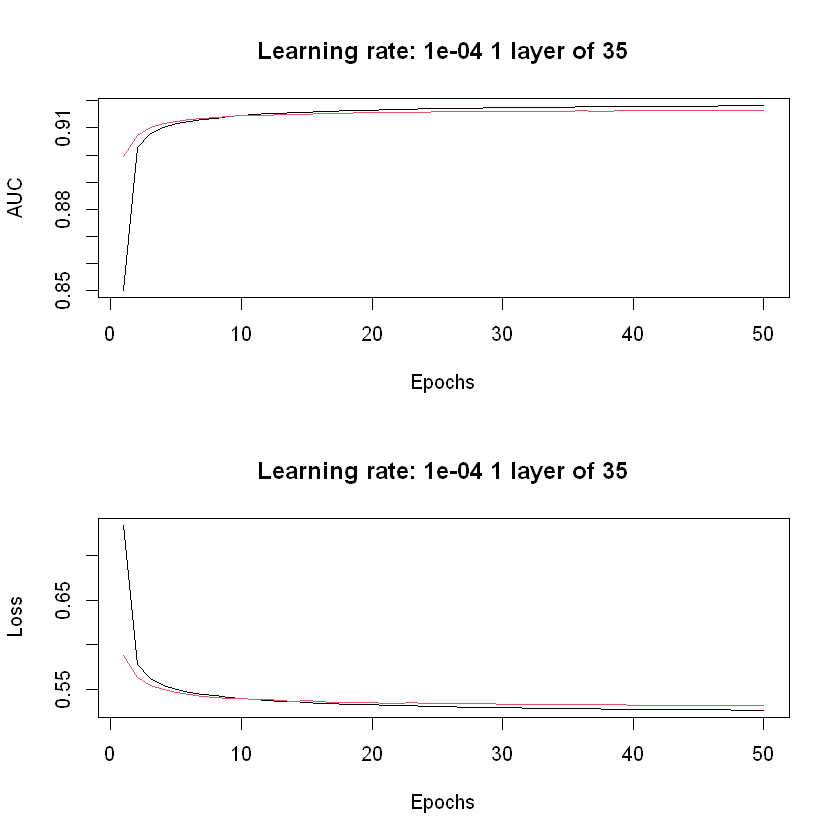

[1] "F1-Score Micro - 7 fold - Learning rate 0.001 :  0.754648561067819"


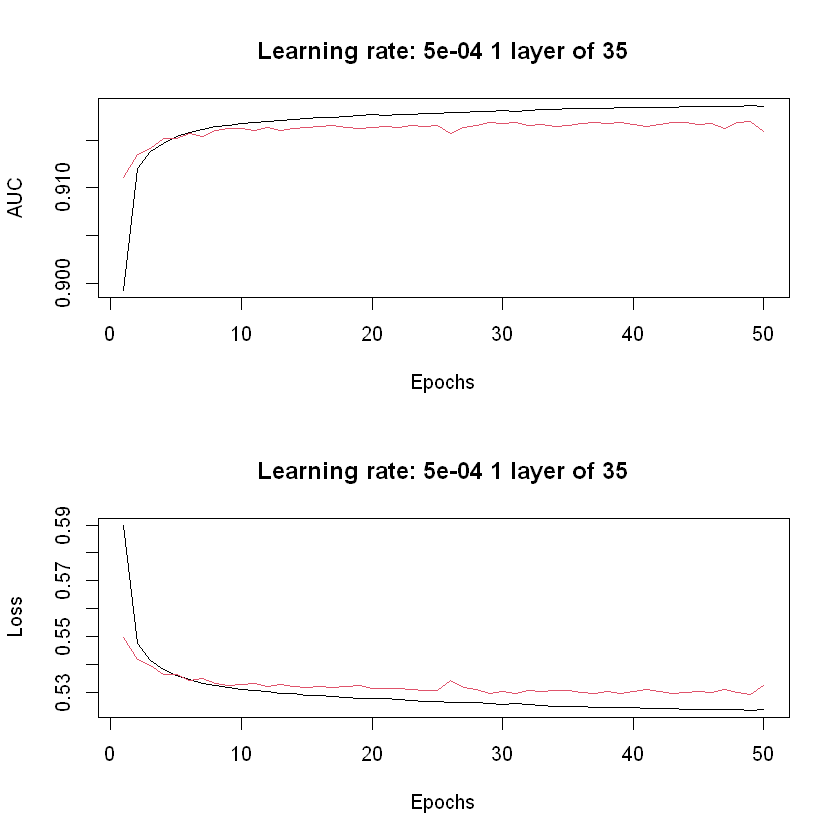

[1] "F1-Score Micro - 7 fold - Learning rate 0.005 :  0.752141038500116"
  |========================================================              |  80%

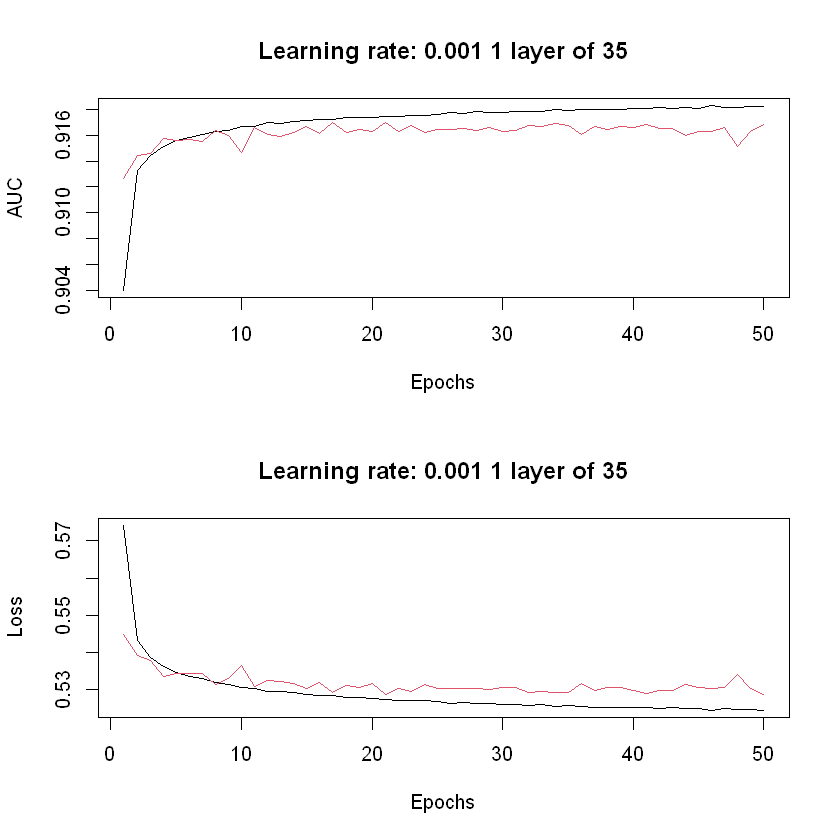

[1] "F1-Score Micro - 8 fold - Learning rate 1e-04 :  0.757889051770697"


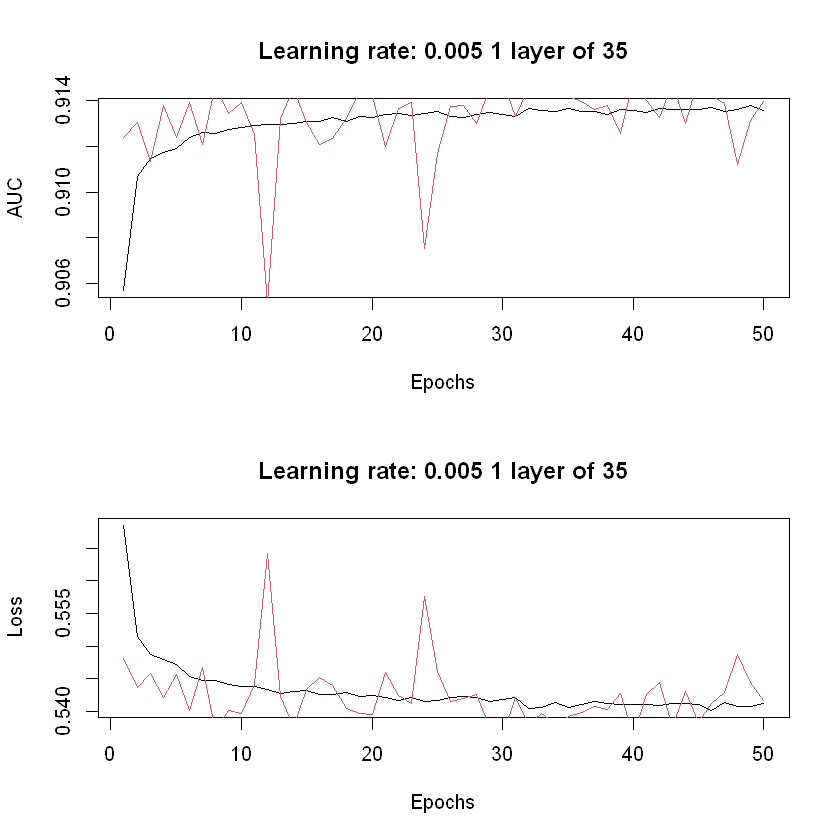

[1] "F1-Score Micro - 8 fold - Learning rate 5e-04 :  0.756191651878713"


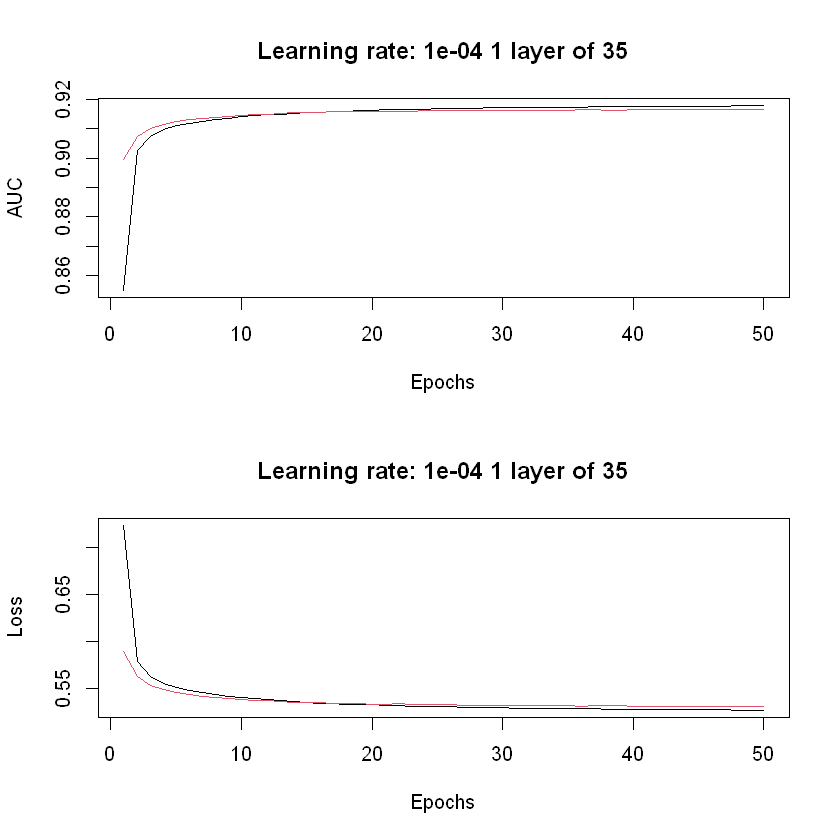

[1] "F1-Score Micro - 8 fold - Learning rate 0.001 :  0.758853483527506"


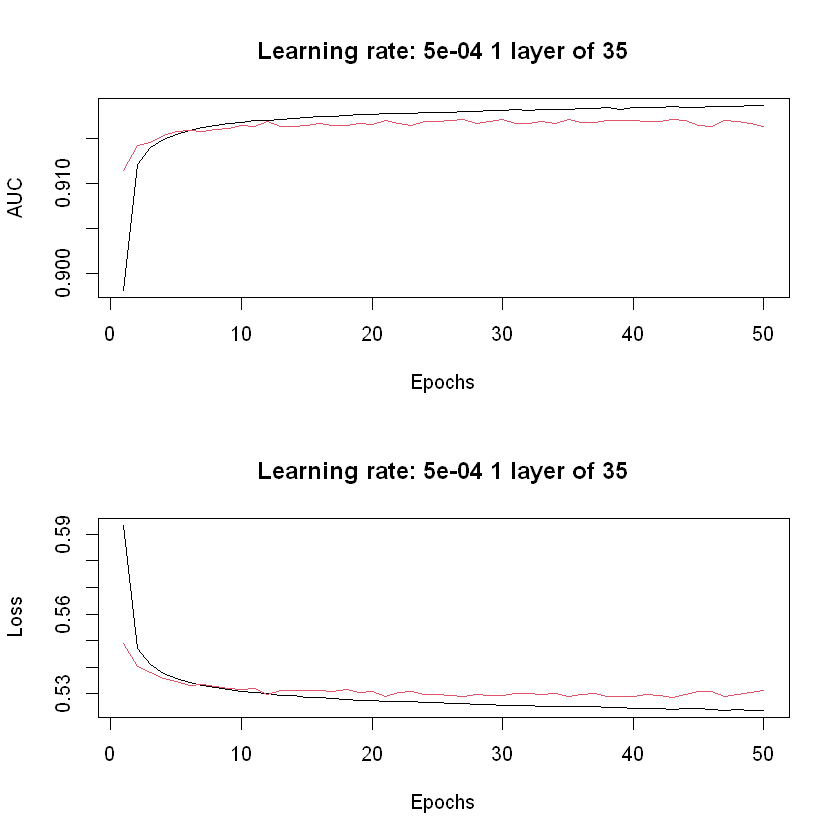

[1] "F1-Score Micro - 8 fold - Learning rate 0.005 :  0.743962657202376"
  |===============================================================       |  90%

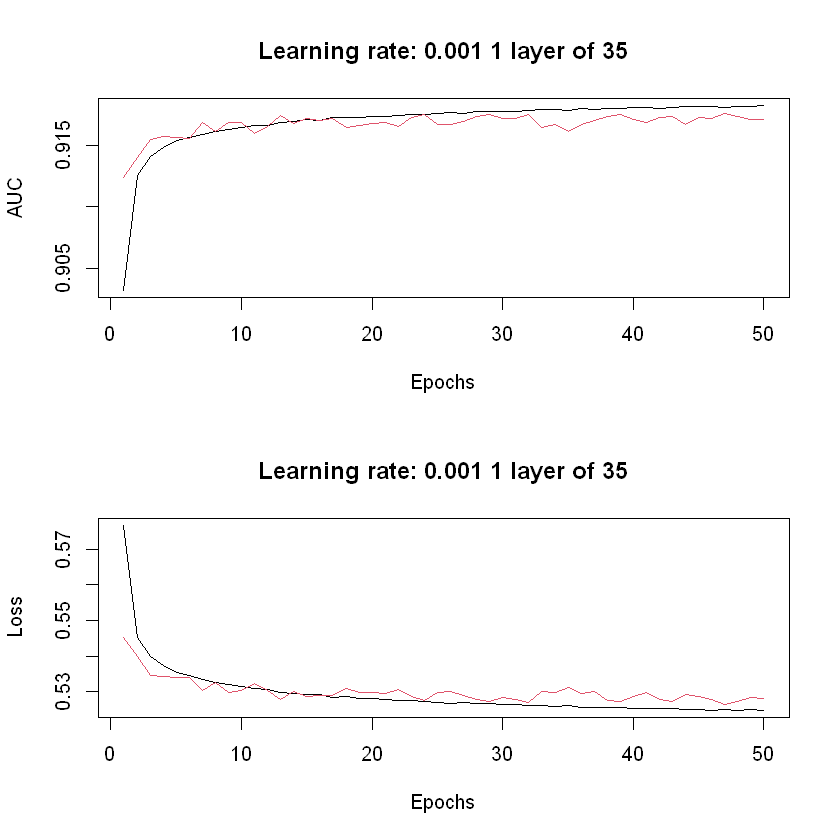

[1] "F1-Score Micro - 9 fold - Learning rate 1e-04 :  0.756268806419258"


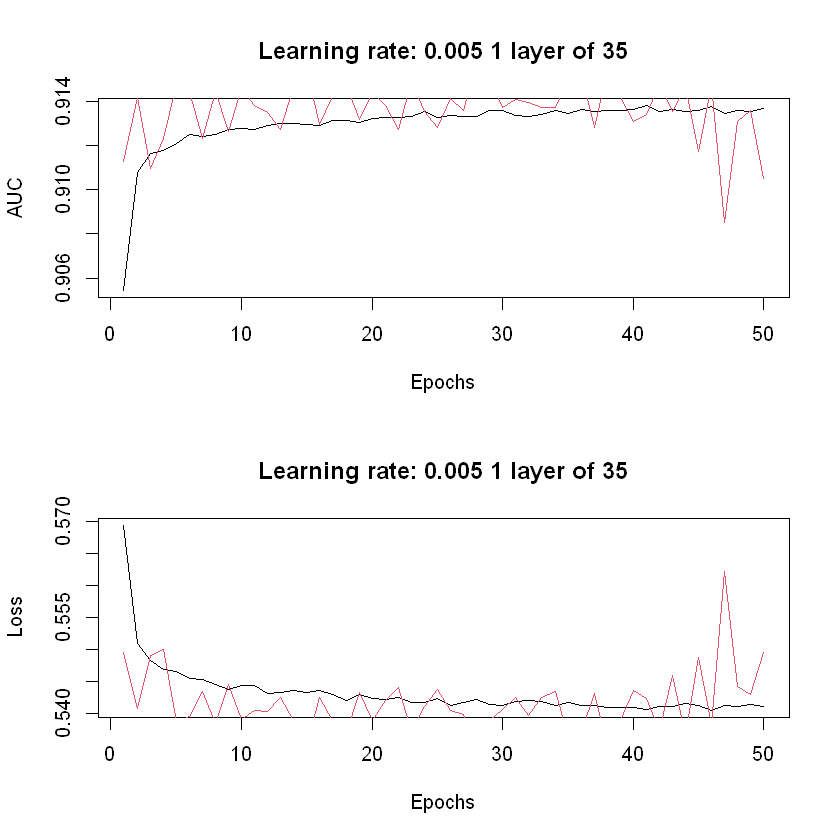

[1] "F1-Score Micro - 9 fold - Learning rate 5e-04 :  0.758969215338323"


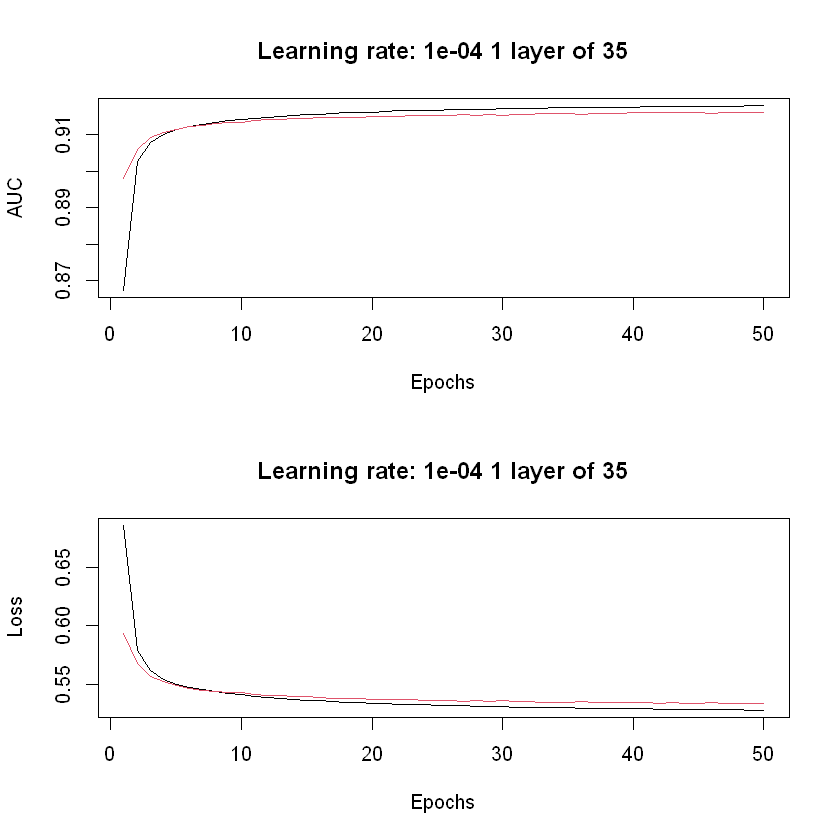

[1] "F1-Score Micro - 9 fold - Learning rate 0.001 :  0.755111488311087"


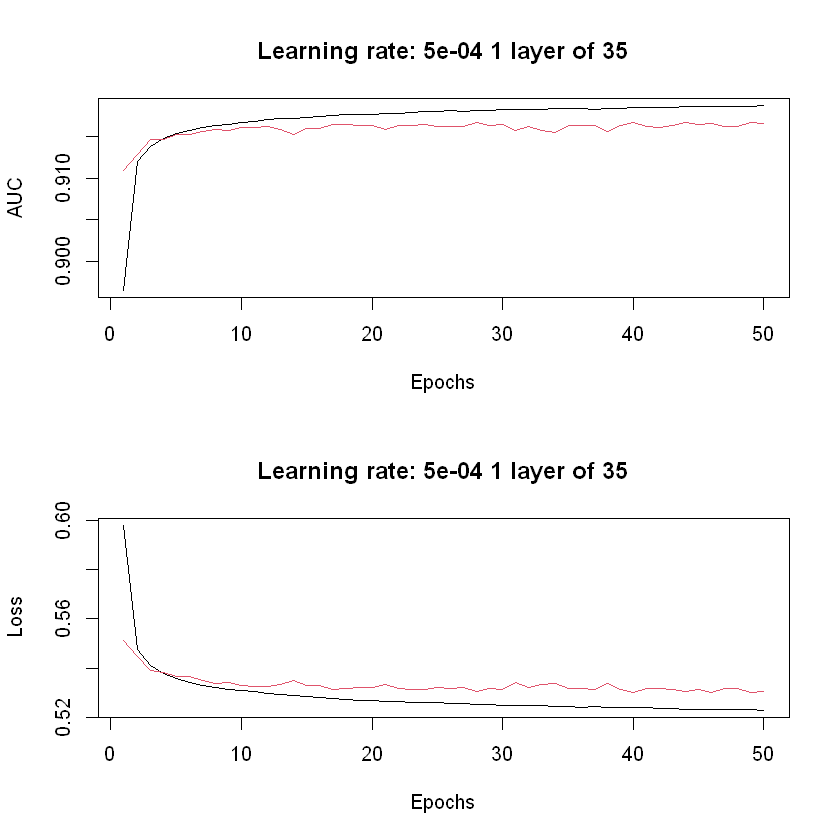

[1] "F1-Score Micro - 9 fold - Learning rate 0.005 :  0.751215184013579"
  |======================================================================| 100%

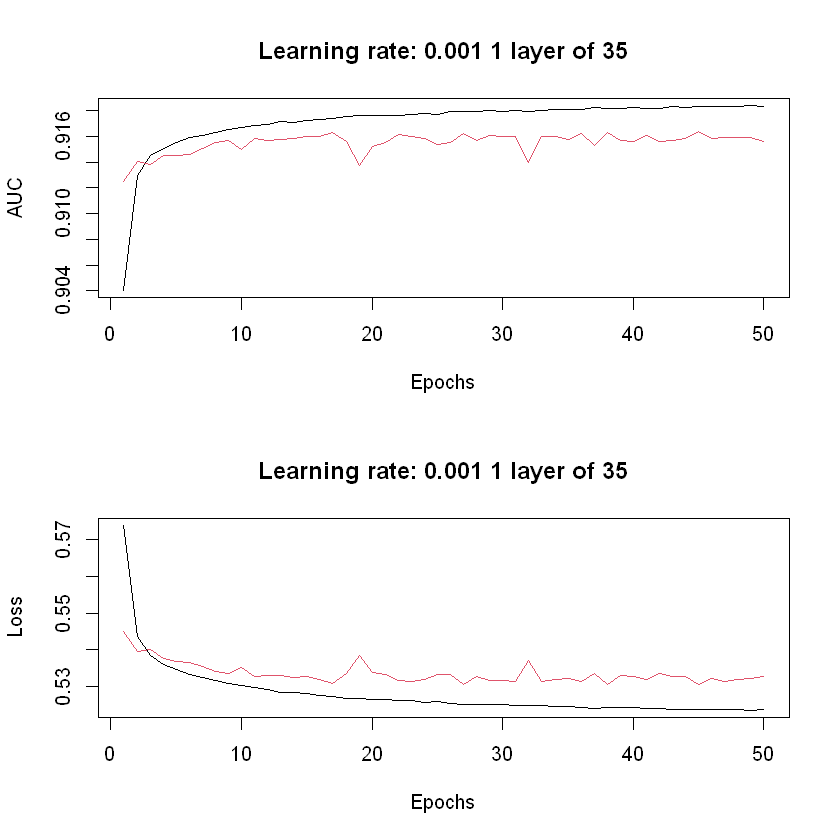

[1] "F1-Score Micro - 10 fold - Learning rate 1e-04 :  0.757071740053255"


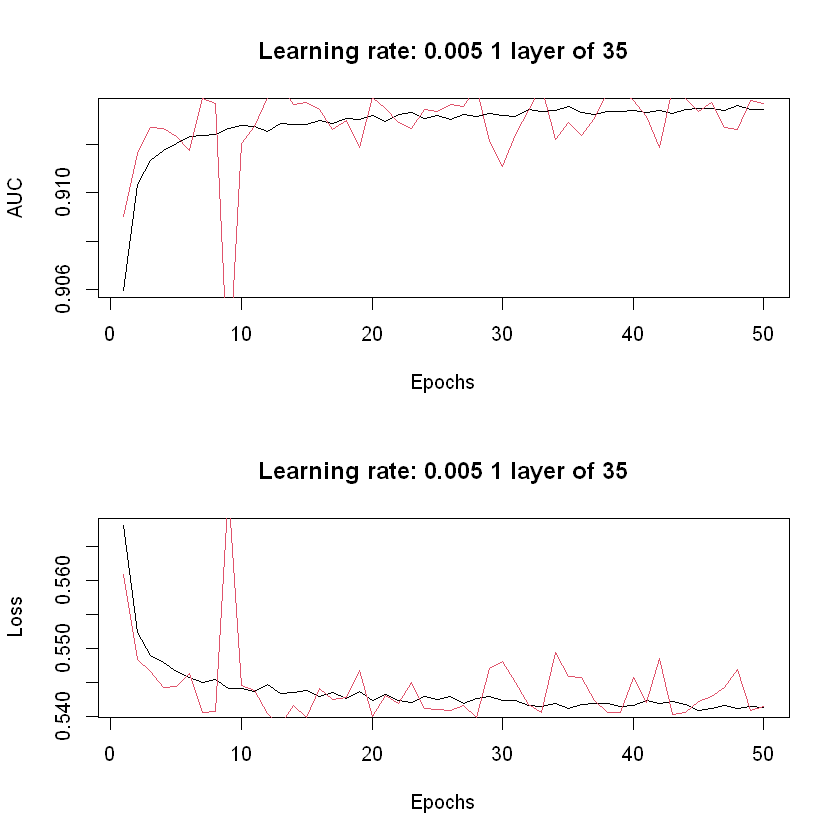

[1] "F1-Score Micro - 10 fold - Learning rate 5e-04 :  0.756724424034269"


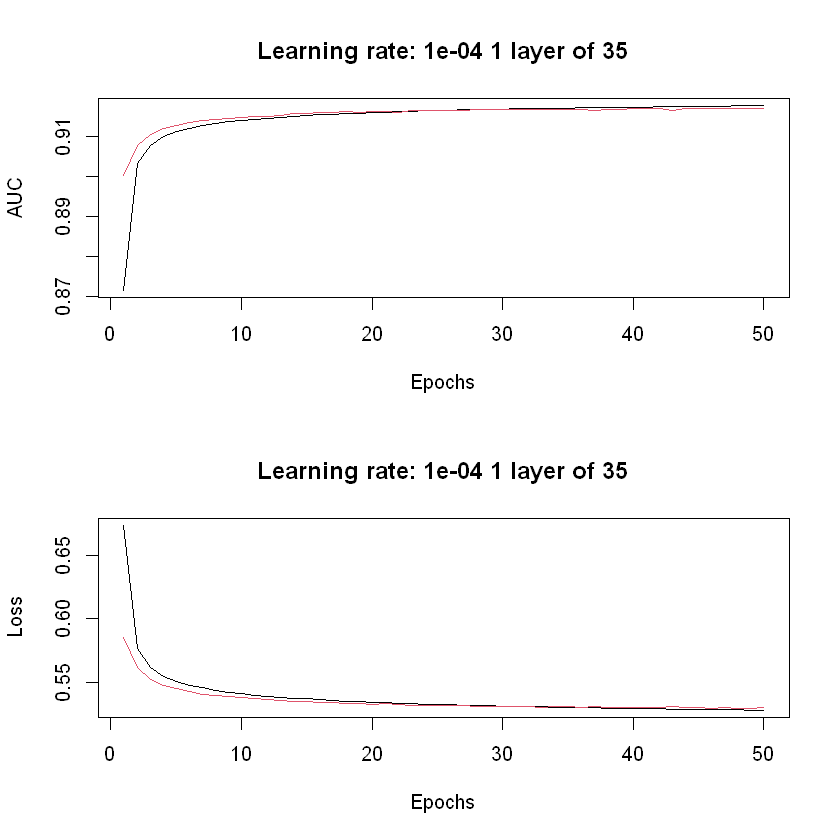

[1] "F1-Score Micro - 10 fold - Learning rate 0.001 :  0.754872071933007"


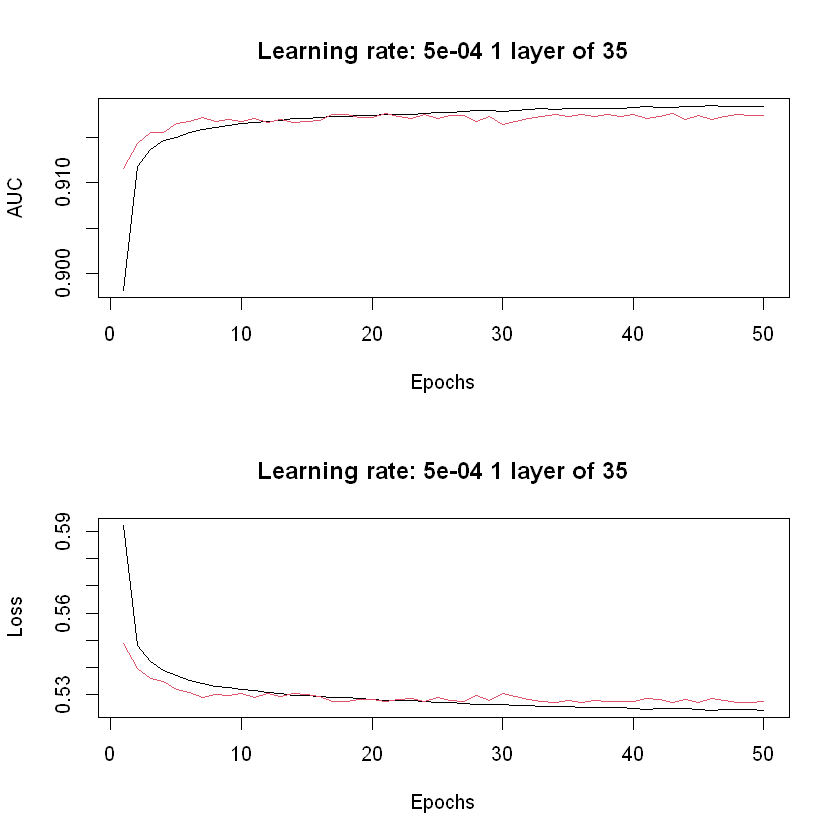

[1] "F1-Score Micro - 10 fold - Learning rate 0.005 :  0.7524408598001"


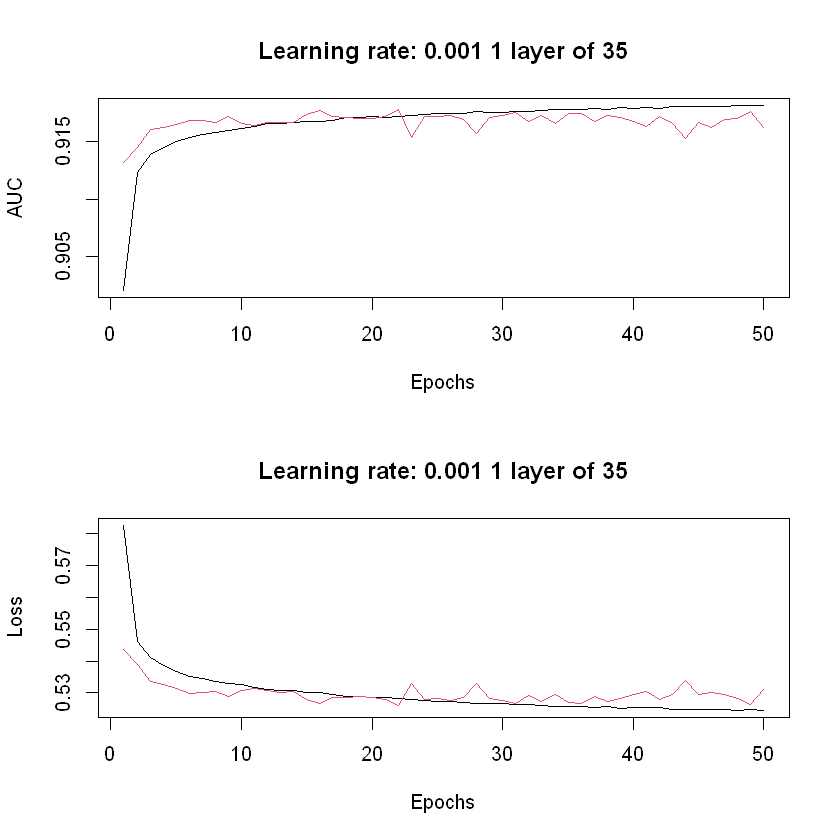

fold,mean_F1
<dbl>,<dbl>
1,0.7550150
2,0.7590174
3,0.7528644
4,0.7553237
5,0.7547450
6,0.7503858
7,0.7540217
8,0.7542242
9,0.7553912


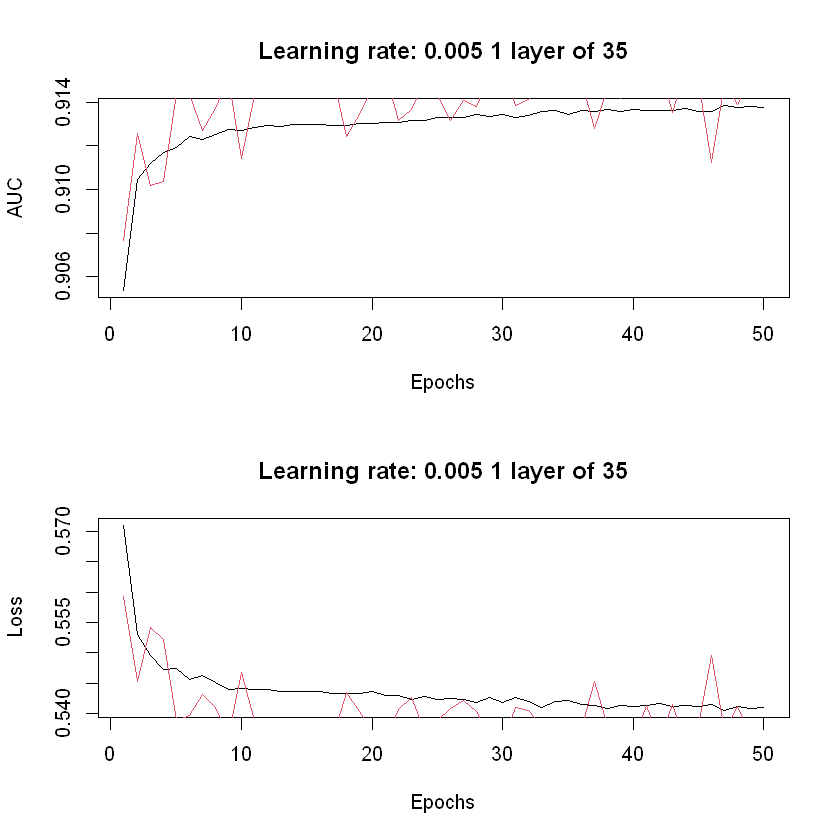

In [6]:
set.seed(2)
k = 5

accuracy_vec <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec)<-c('fold','learning_rate','F1')

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005,0.001,0.005)){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_variables]),
        as.matrix(train_data[,target_variables]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

        yhaty <- classConverter(yhat,test_data)
        accuracy_vec[nrow(accuracy_vec)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,]))
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec[nrow(accuracy_vec),3]))
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '1 layer of 37', 'fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x=x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '1 layer of 37', 'fold', i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history')
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
meanF1 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005,0.001,0.005)){
    meanF1[nrow(meanF1)+1,]<-c(i,mean(filter(accuracy_vec,(learning_rate==i))$F1))
}

accuracy_vec
meanF1

#358 min

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - Learning rate 1e-04 :  0.756538847311164"
[1] "F1-Score Micro - 1 fold - Learning rate 5e-04 :  0.757040351824705"


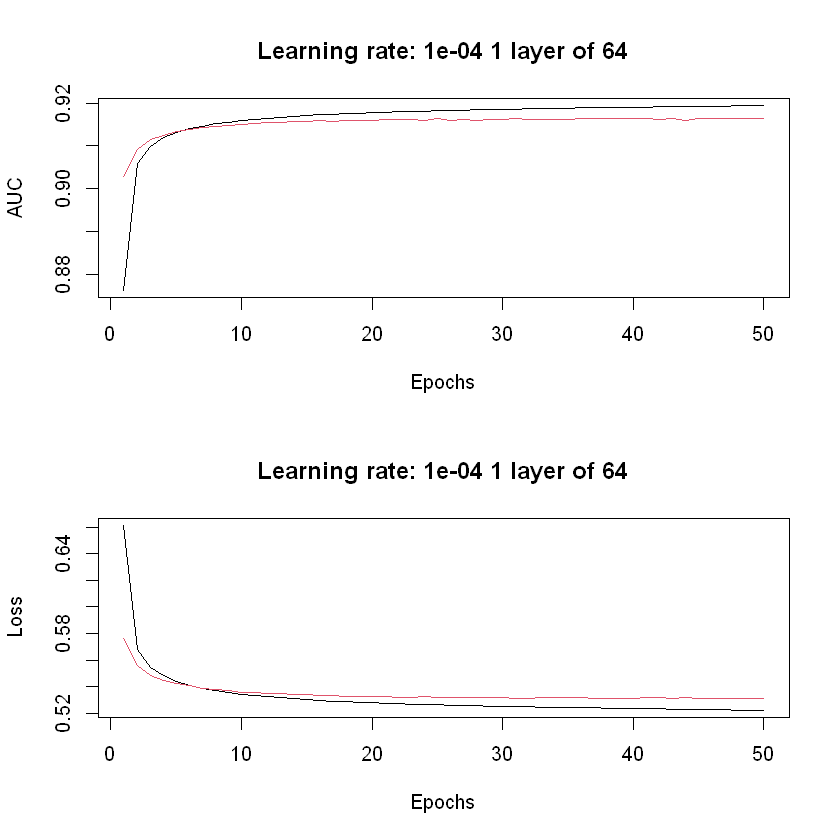

[1] "F1-Score Micro - 1 fold - Learning rate 0.001 :  0.75761901087879"


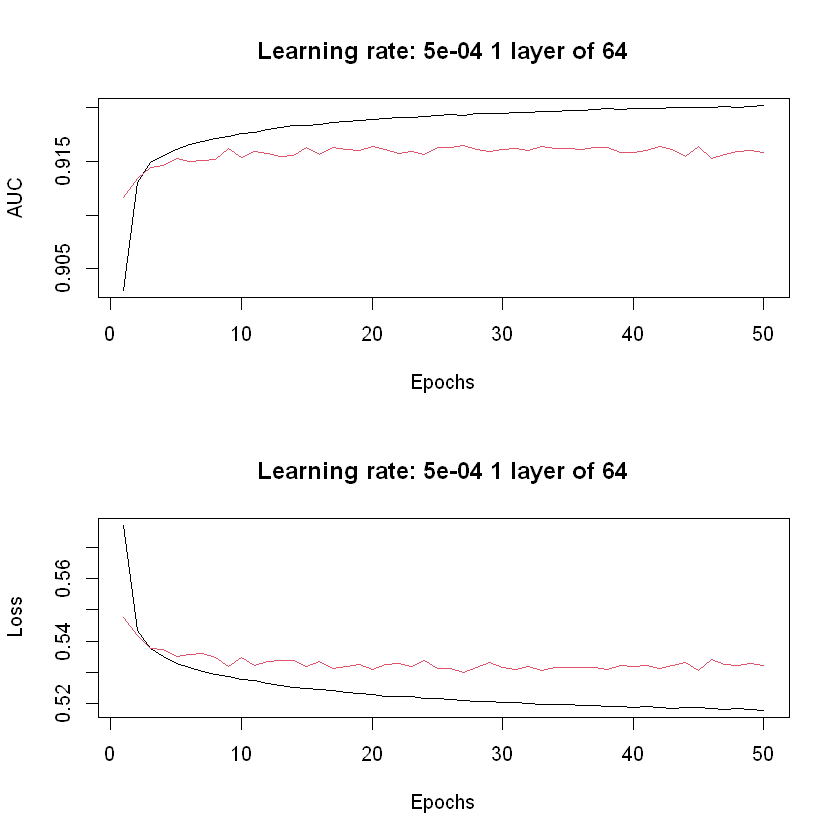

[1] "F1-Score Micro - 1 fold - Learning rate 0.005 :  0.754031324743461"
  |==============                                                        |  20%

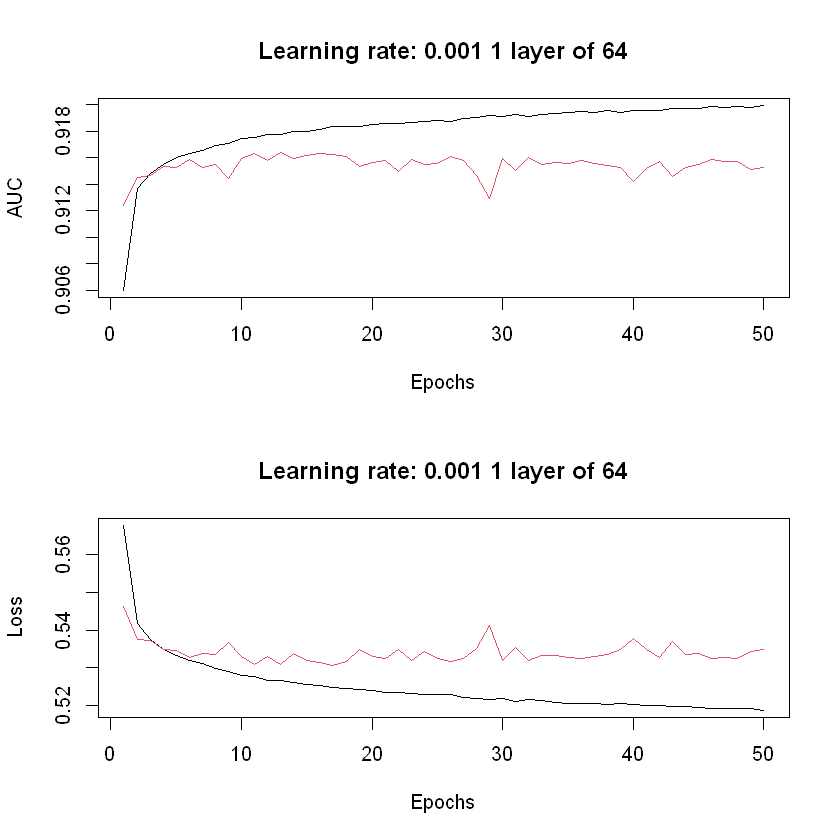

[1] "F1-Score Micro - 2 fold - Learning rate 1e-04 :  0.758313401743693"


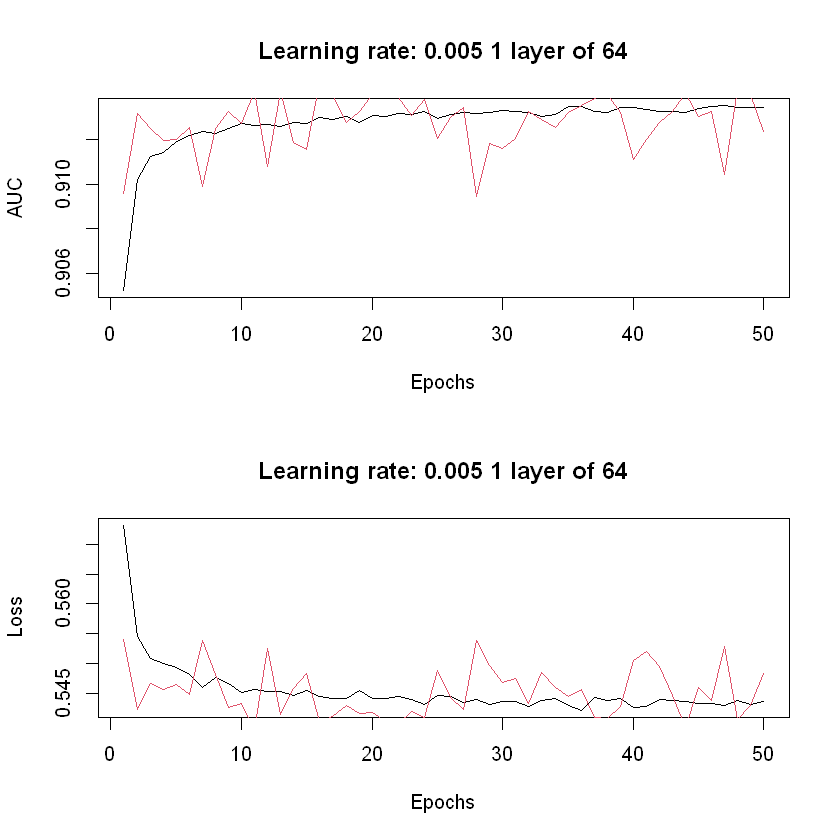

[1] "F1-Score Micro - 2 fold - Learning rate 5e-04 :  0.759547874392408"


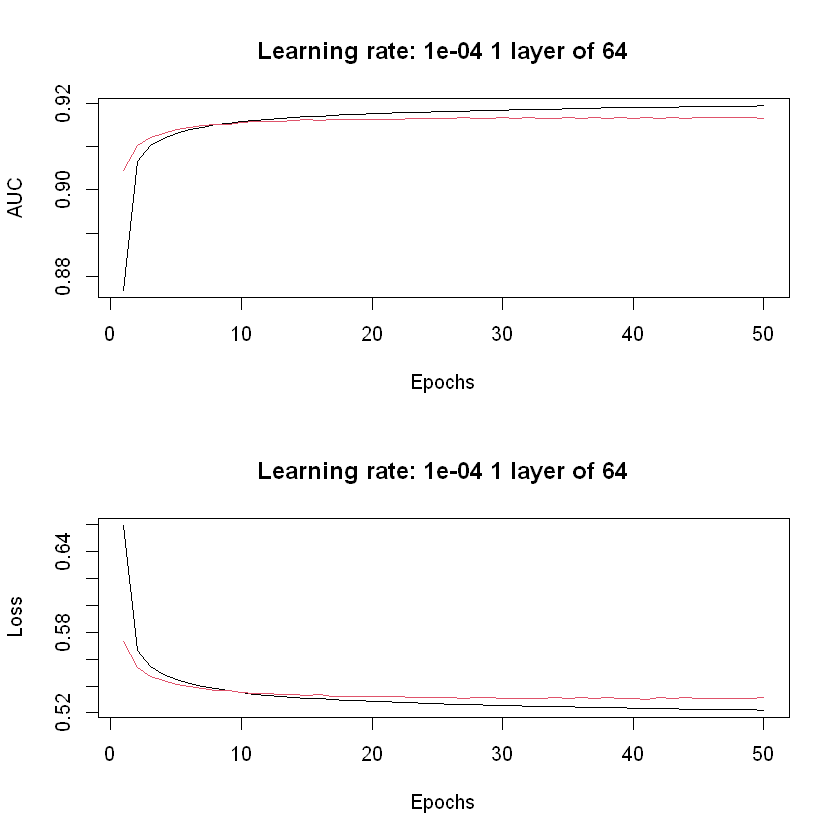

[1] "F1-Score Micro - 2 fold - Learning rate 0.001 :  0.758159092662603"


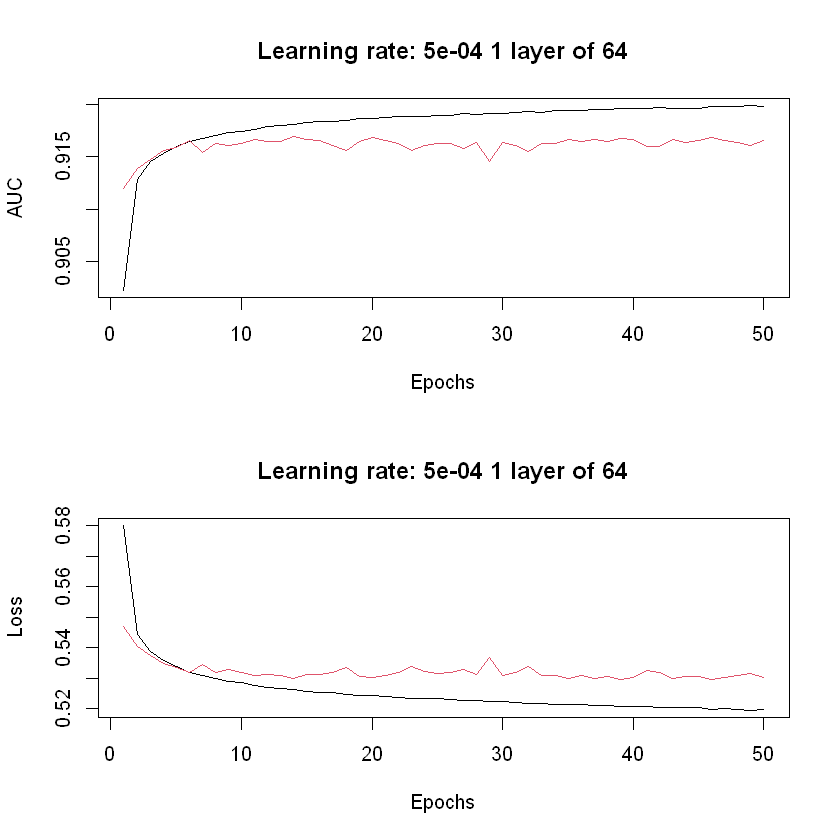

[1] "F1-Score Micro - 2 fold - Learning rate 0.005 :  0.757348969986884"
  |=====================                                                 |  30%

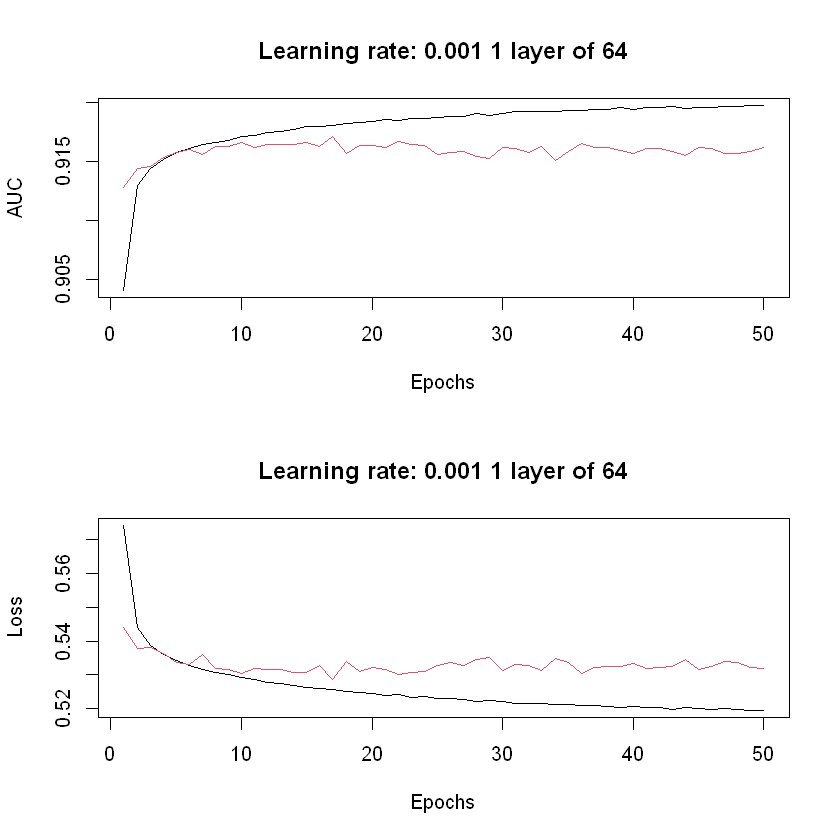

[1] "F1-Score Micro - 3 fold - Learning rate 1e-04 :  0.752796852094746"


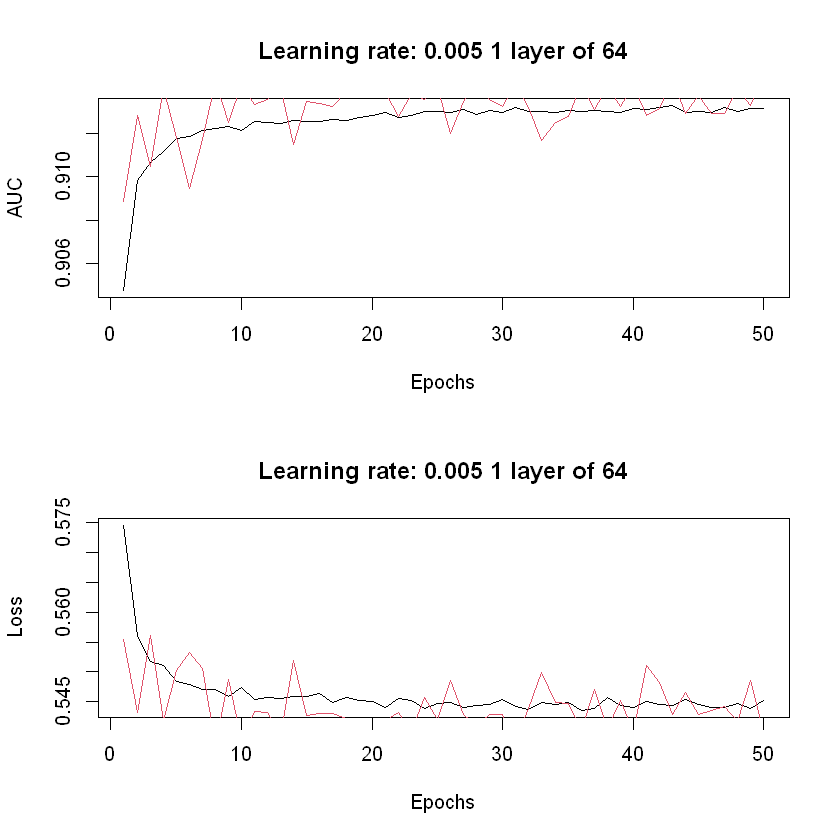

[1] "F1-Score Micro - 3 fold - Learning rate 5e-04 :  0.754301365635368"


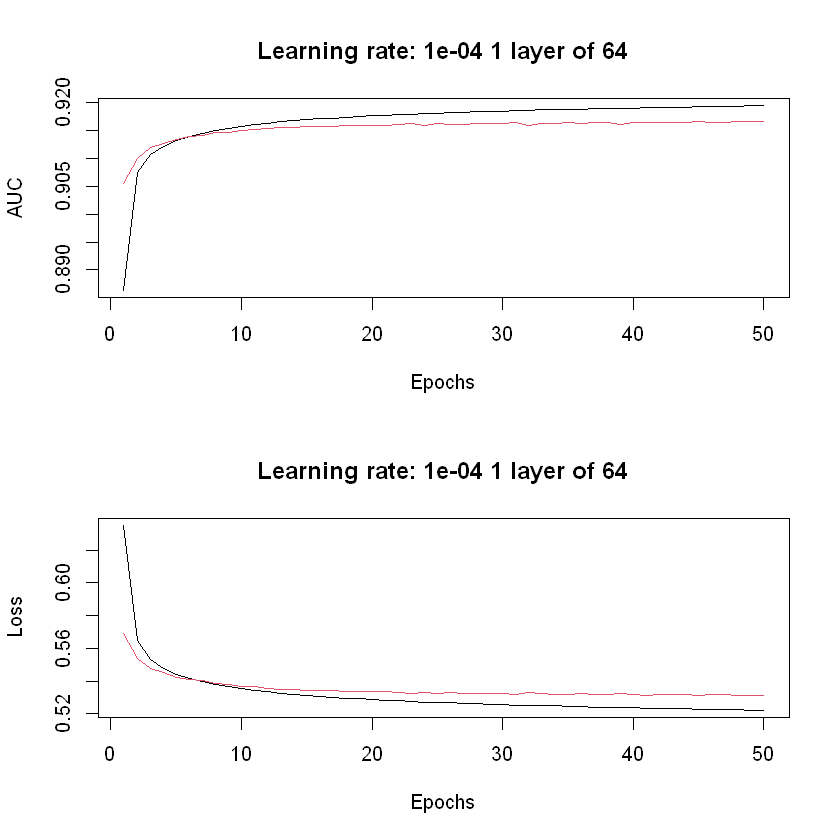

[1] "F1-Score Micro - 3 fold - Learning rate 0.001 :  0.754378520175912"


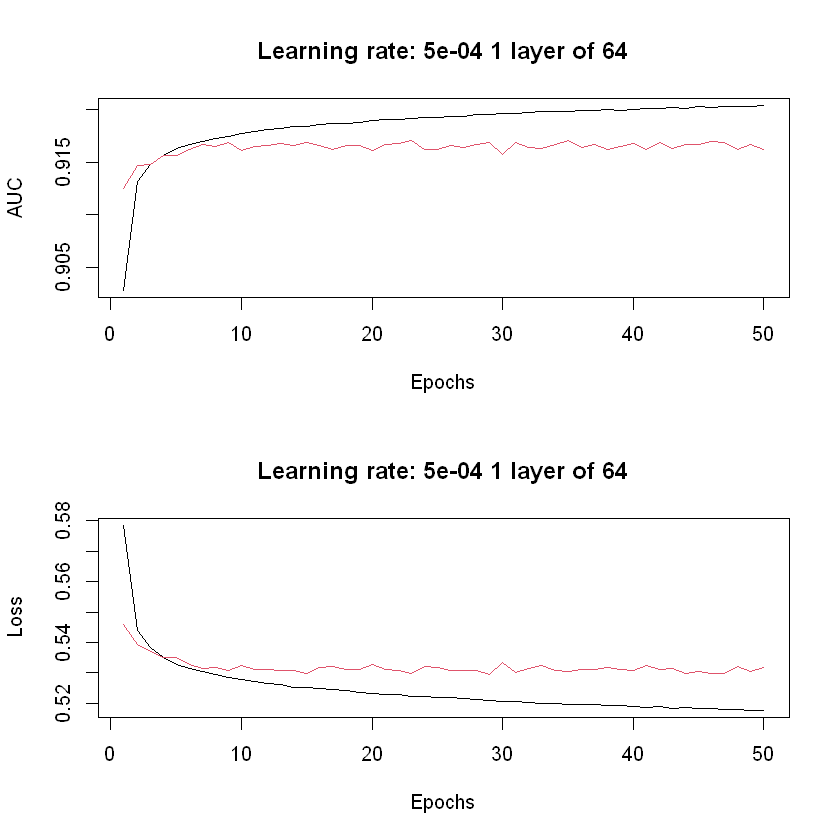

[1] "F1-Score Micro - 3 fold - Learning rate 0.005 :  0.750366484067587"
  |============================                                          |  40%

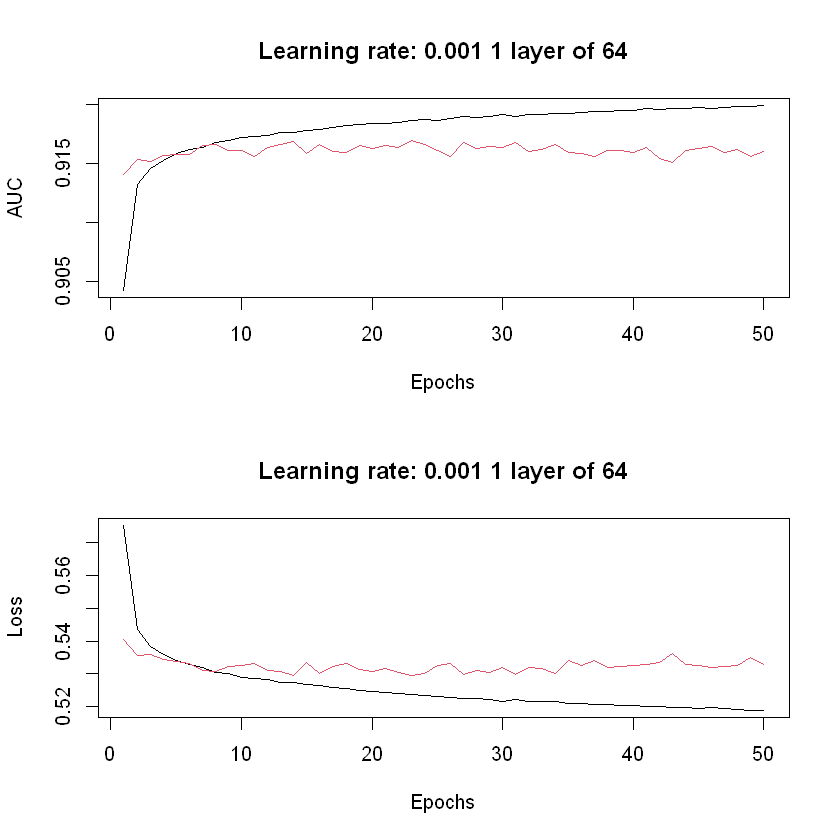

[1] "F1-Score Micro - 4 fold - Learning rate 1e-04 :  0.754571406527274"


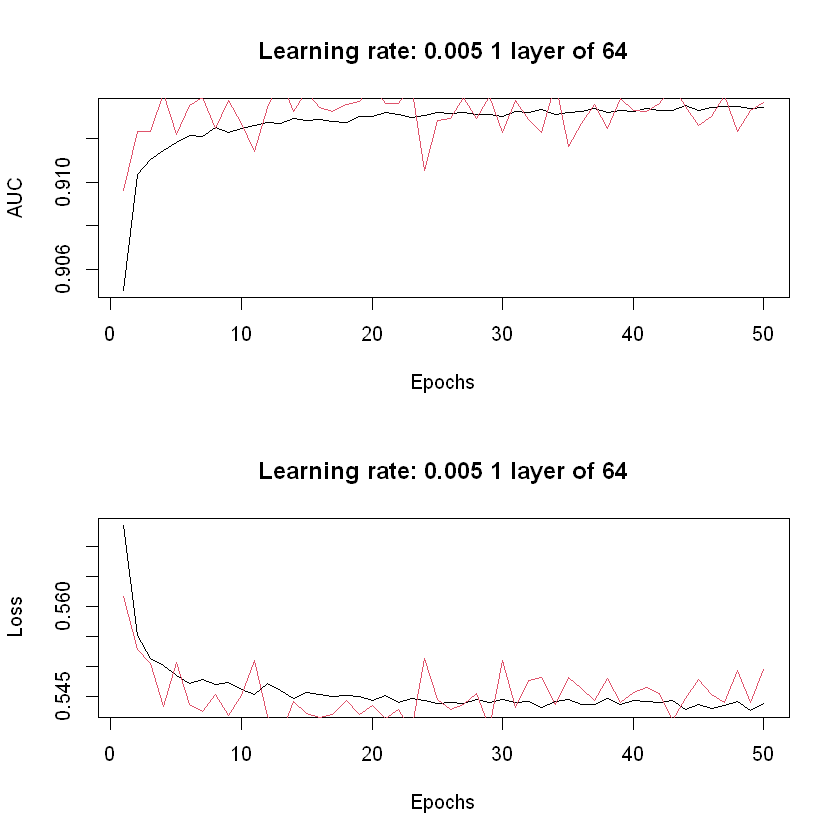

[1] "F1-Score Micro - 4 fold - Learning rate 5e-04 :  0.753452665689376"


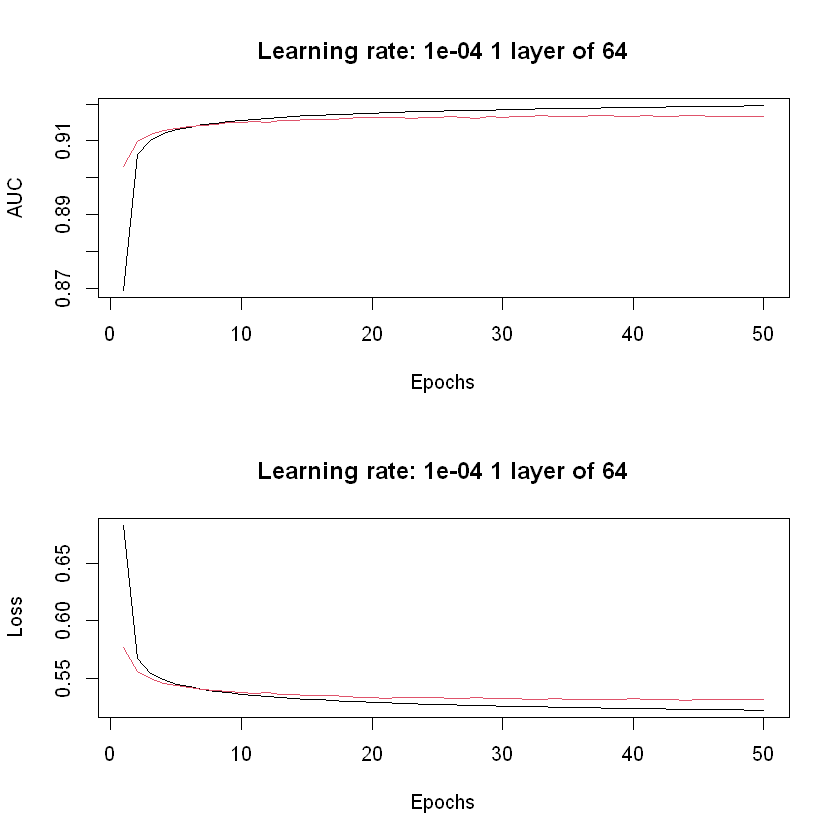

[1] "F1-Score Micro - 4 fold - Learning rate 0.001 :  0.753375511148831"


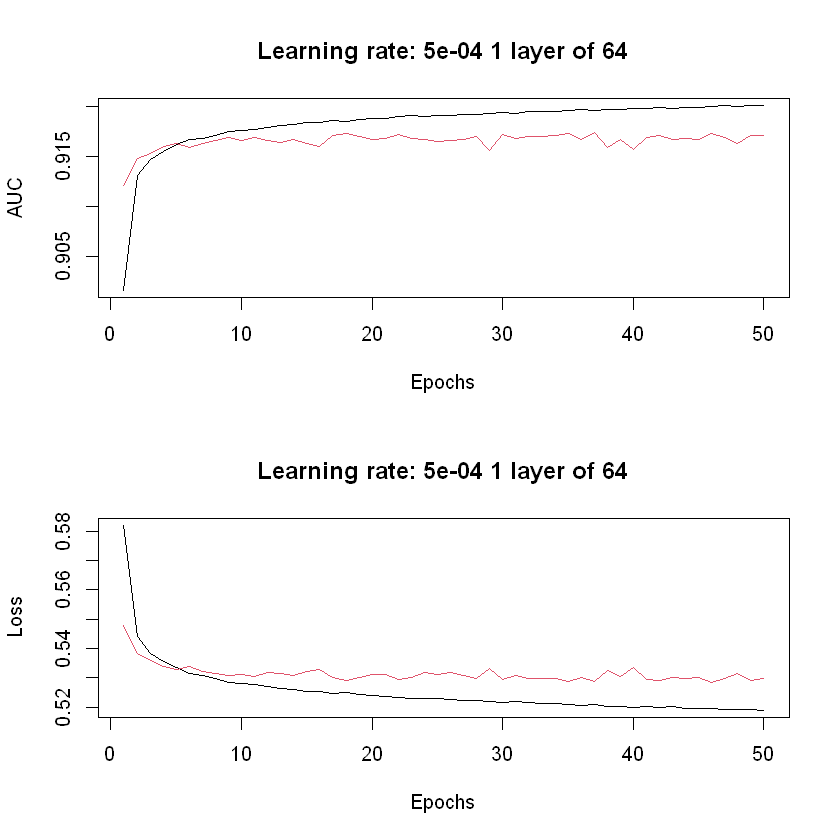

[1] "F1-Score Micro - 4 fold - Learning rate 0.005 :  0.749710670472957"
  |===================================                                   |  50%

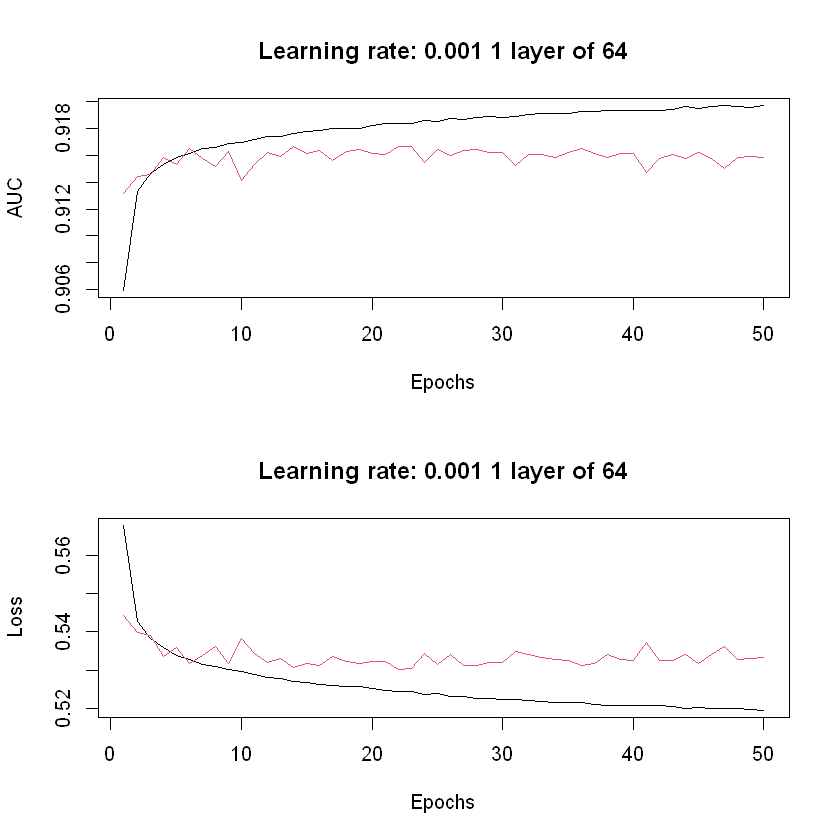

[1] "F1-Score Micro - 5 fold - Learning rate 1e-04 :  0.752179615770388"


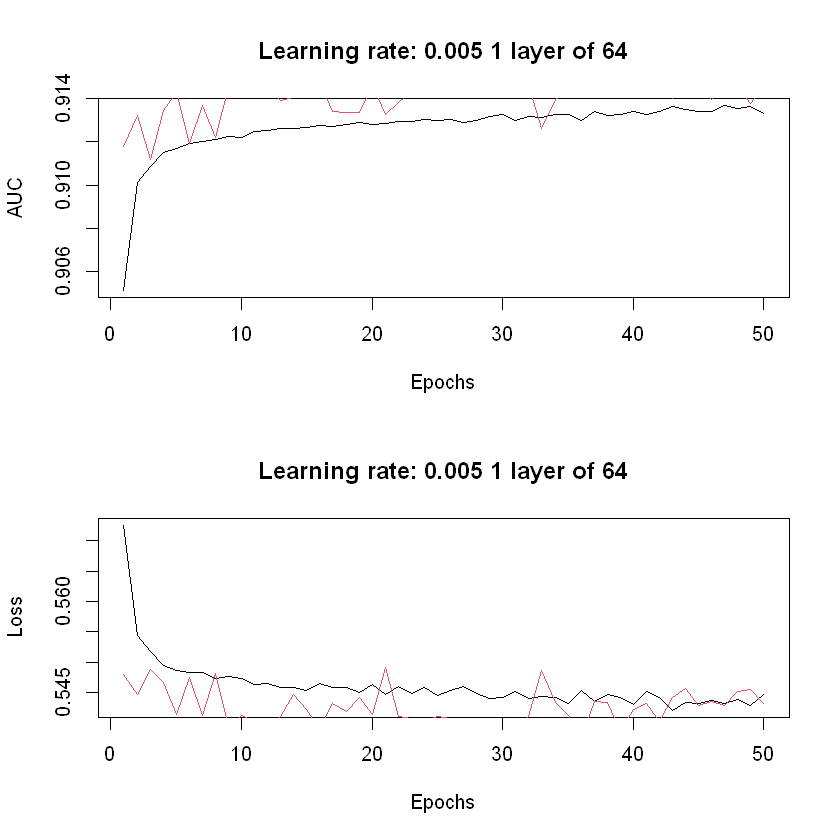

[1] "F1-Score Micro - 5 fold - Learning rate 5e-04 :  0.753182624797469"


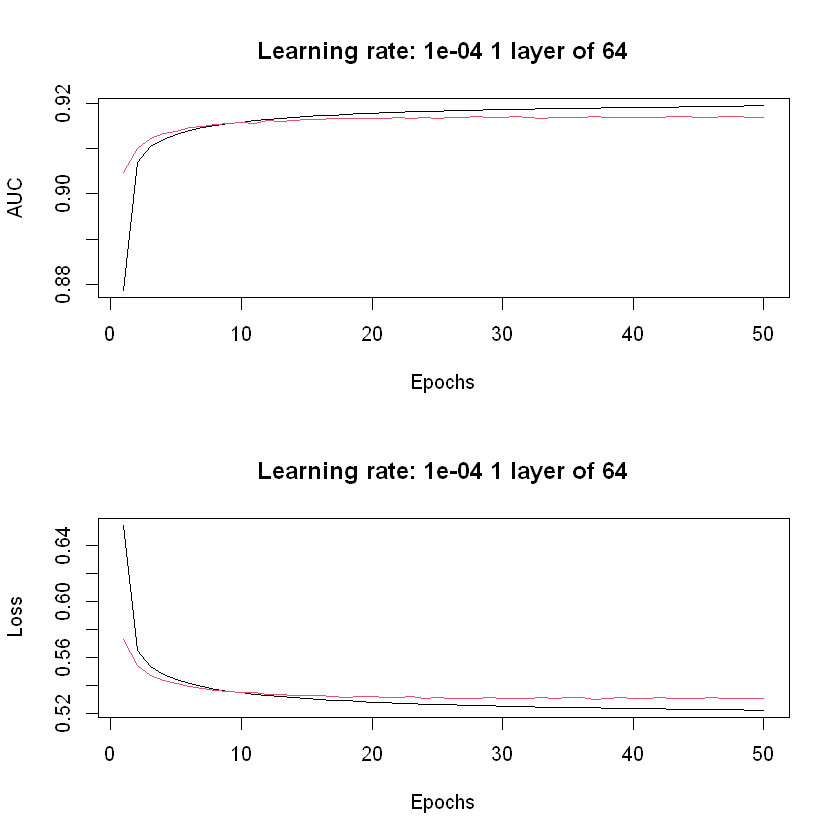

[1] "F1-Score Micro - 5 fold - Learning rate 0.001 :  0.749324897770234"


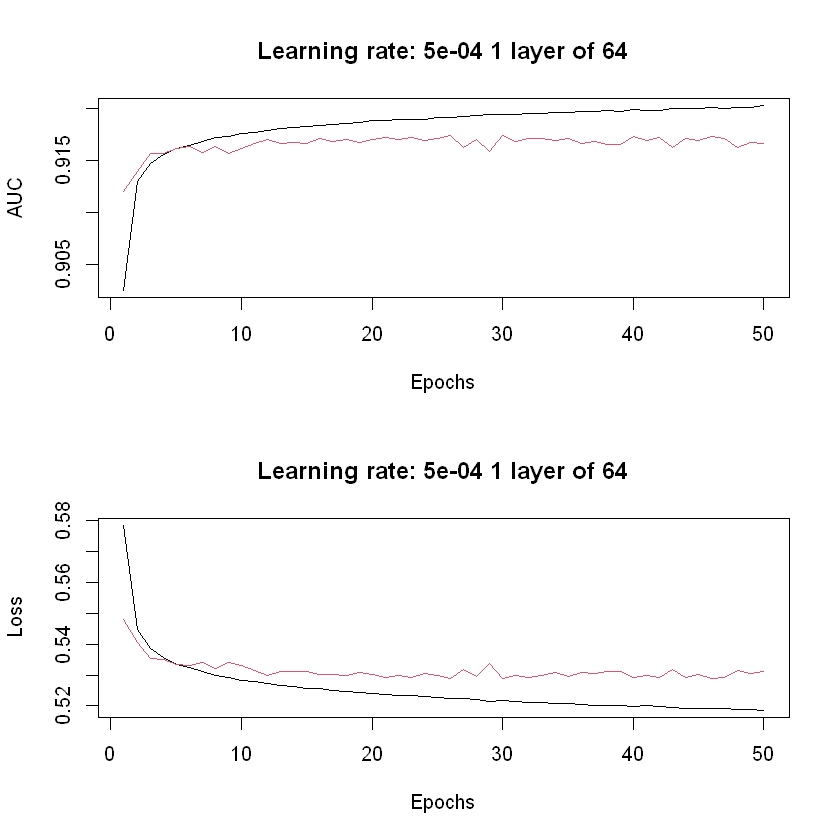

[1] "F1-Score Micro - 5 fold - Learning rate 0.005 :  0.748514775094514"
  |==========================================                            |  60%

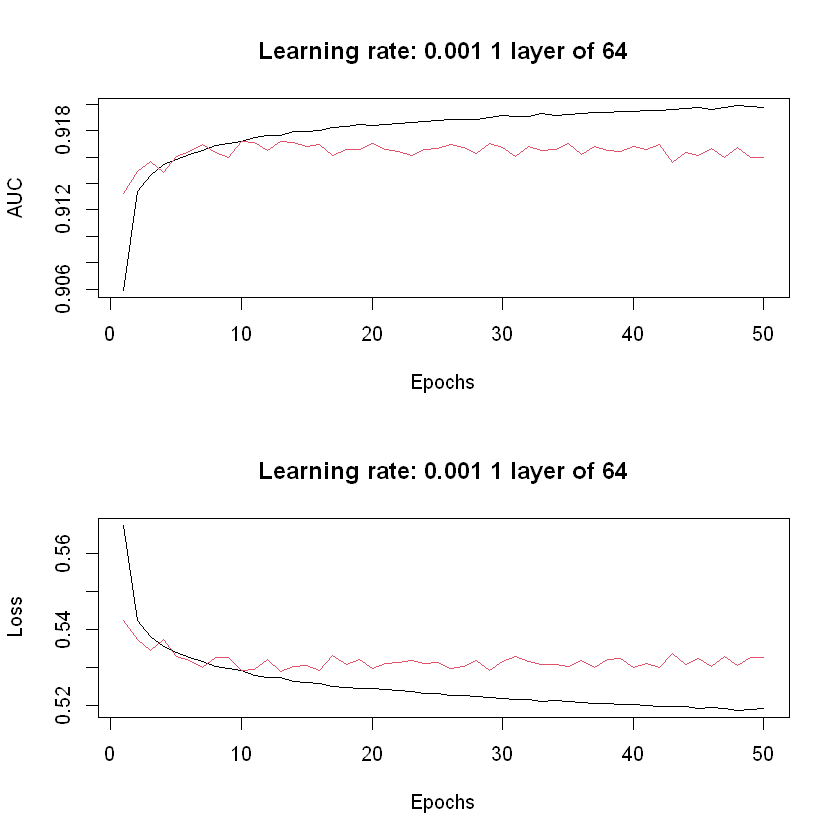

[1] "F1-Score Micro - 6 fold - Learning rate 1e-04 :  0.758467710824782"


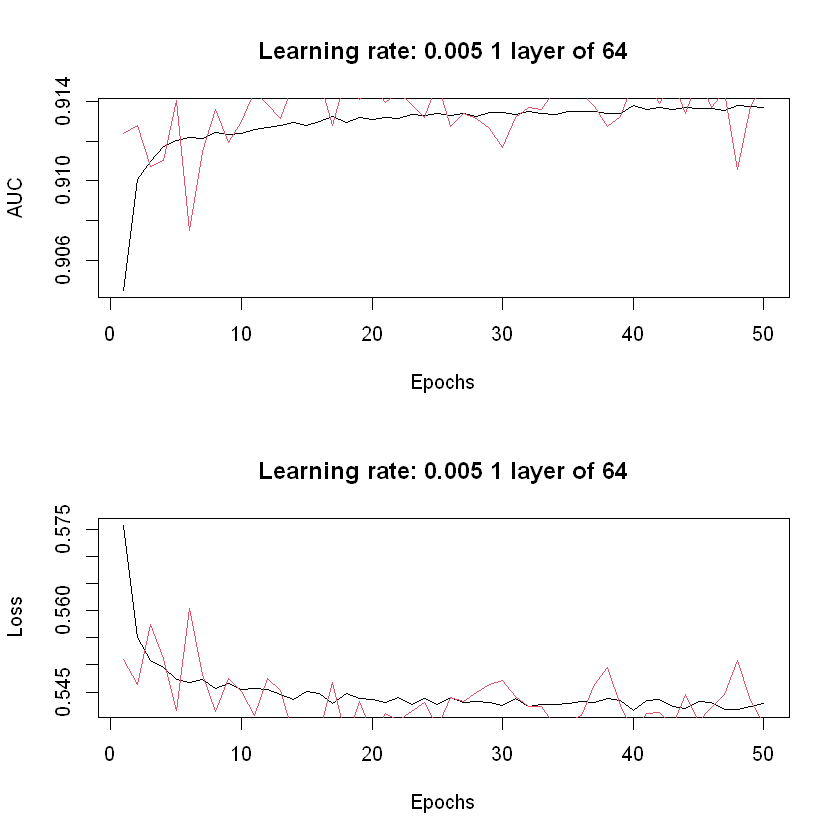

[1] "F1-Score Micro - 6 fold - Learning rate 5e-04 :  0.758660597176144"


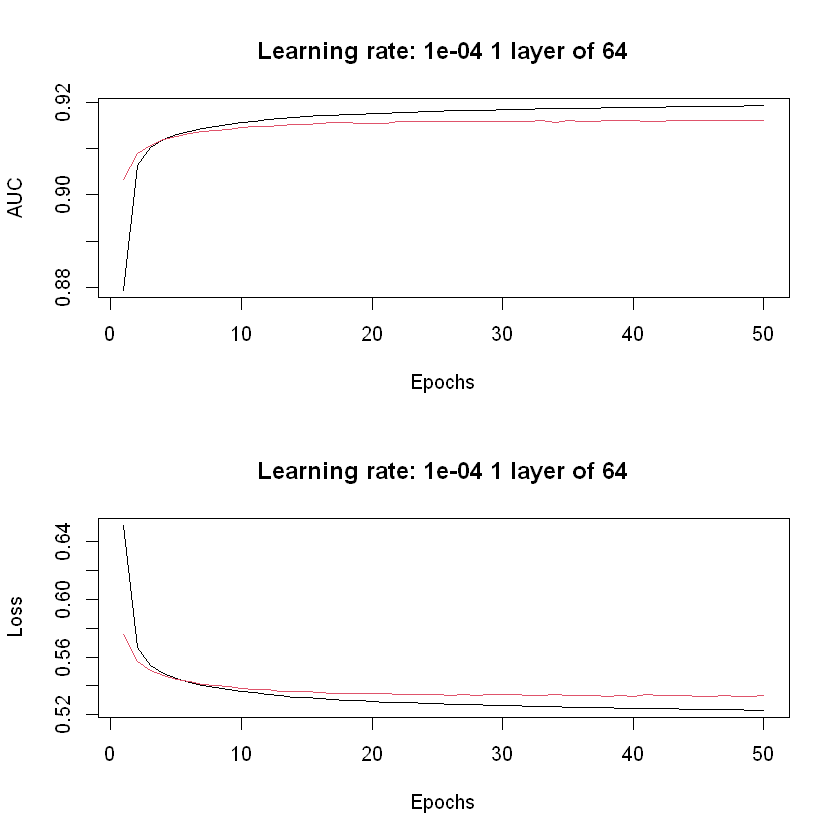

[1] "F1-Score Micro - 6 fold - Learning rate 0.001 :  0.757927629040969"


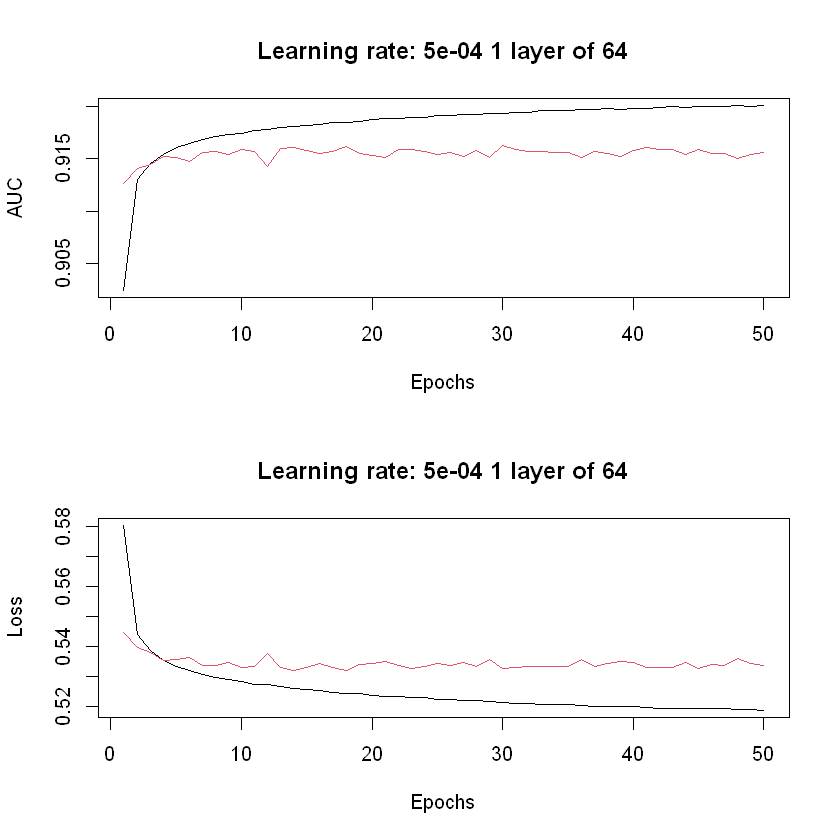

[1] "F1-Score Micro - 6 fold - Learning rate 0.005 :  0.753336933878559"
  |=================================================                     |  70%

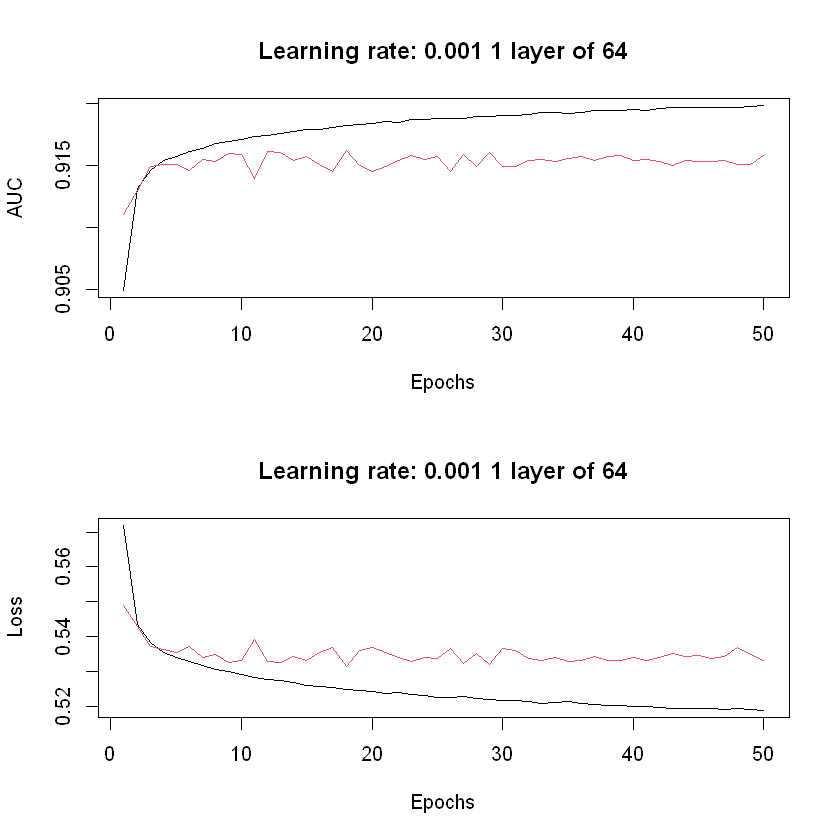

[1] "F1-Score Micro - 7 fold - Learning rate 1e-04 :  0.754880024689453"


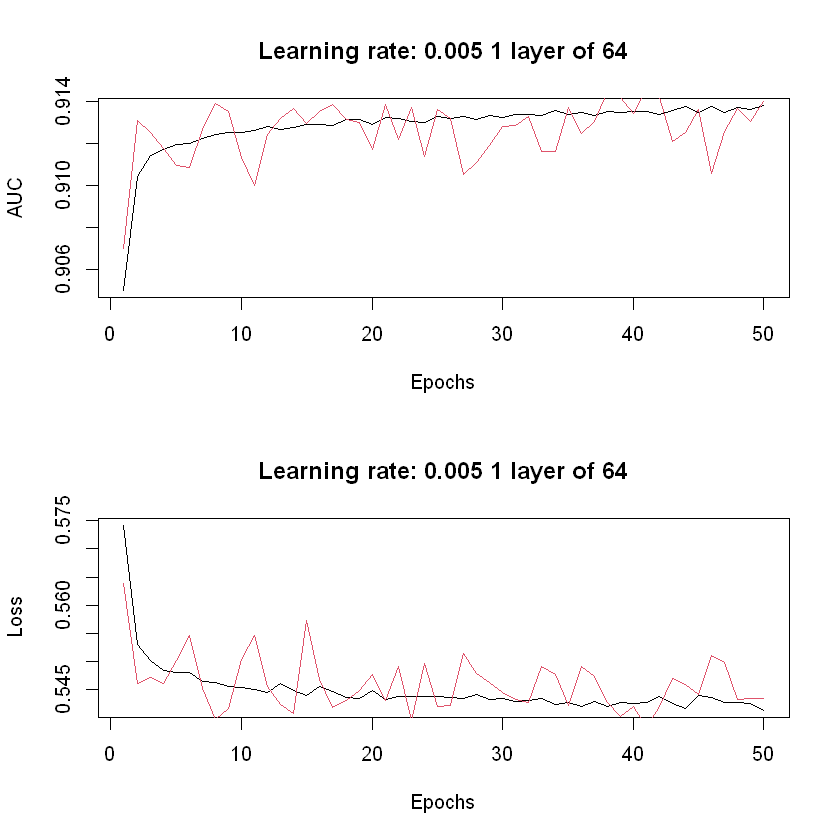

[1] "F1-Score Micro - 7 fold - Learning rate 5e-04 :  0.753336933878559"


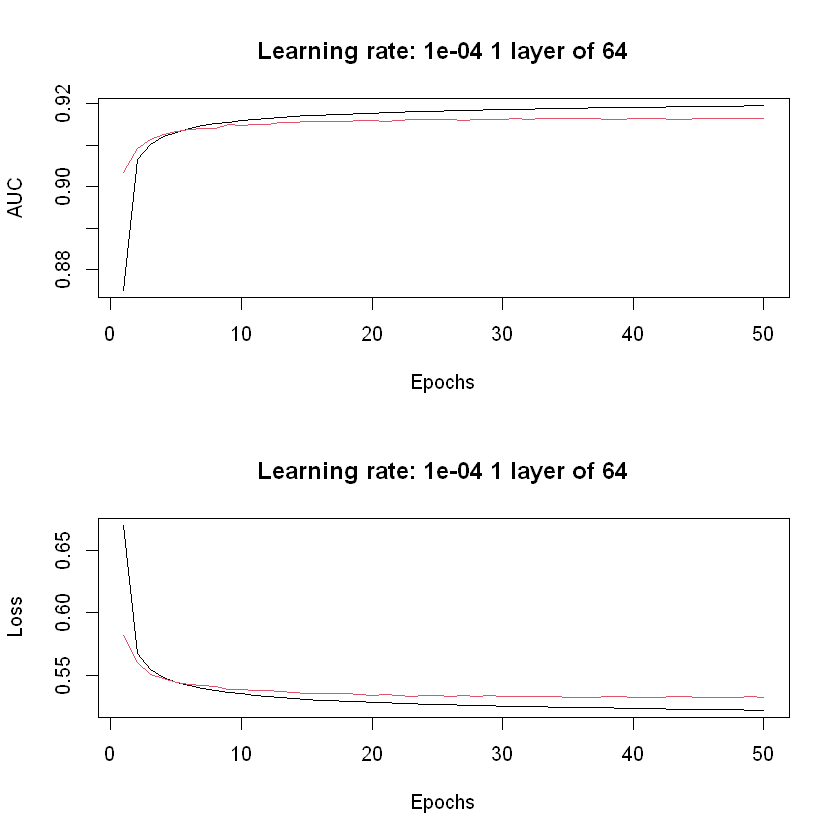

[1] "F1-Score Micro - 7 fold - Learning rate 0.001 :  0.753452665689376"


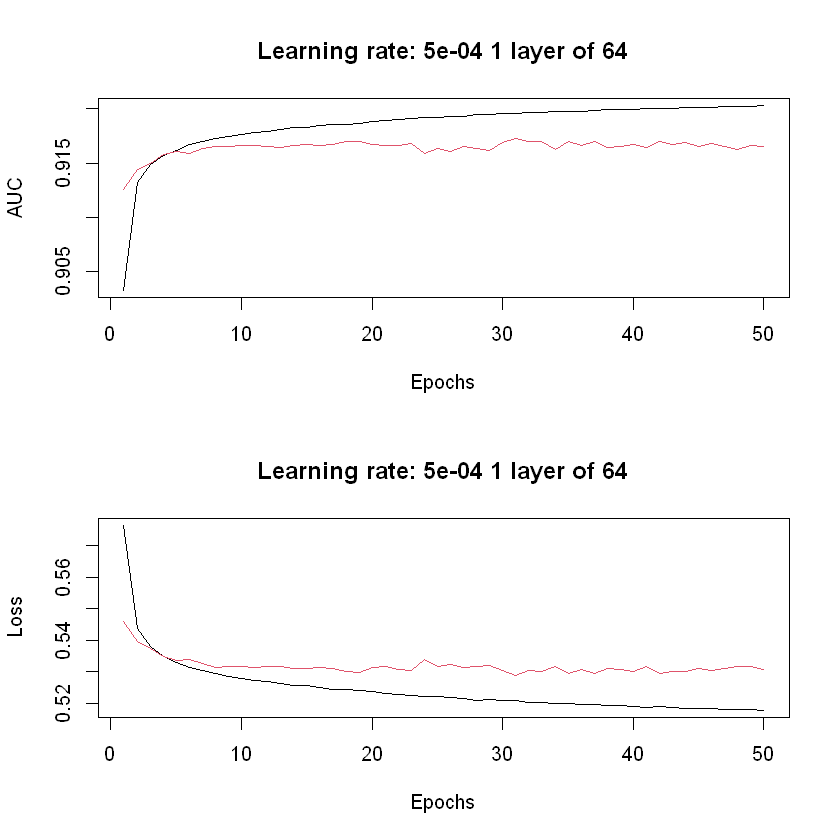

[1] "F1-Score Micro - 7 fold - Learning rate 0.005 :  0.74157086644549"
  |========================================================              |  80%

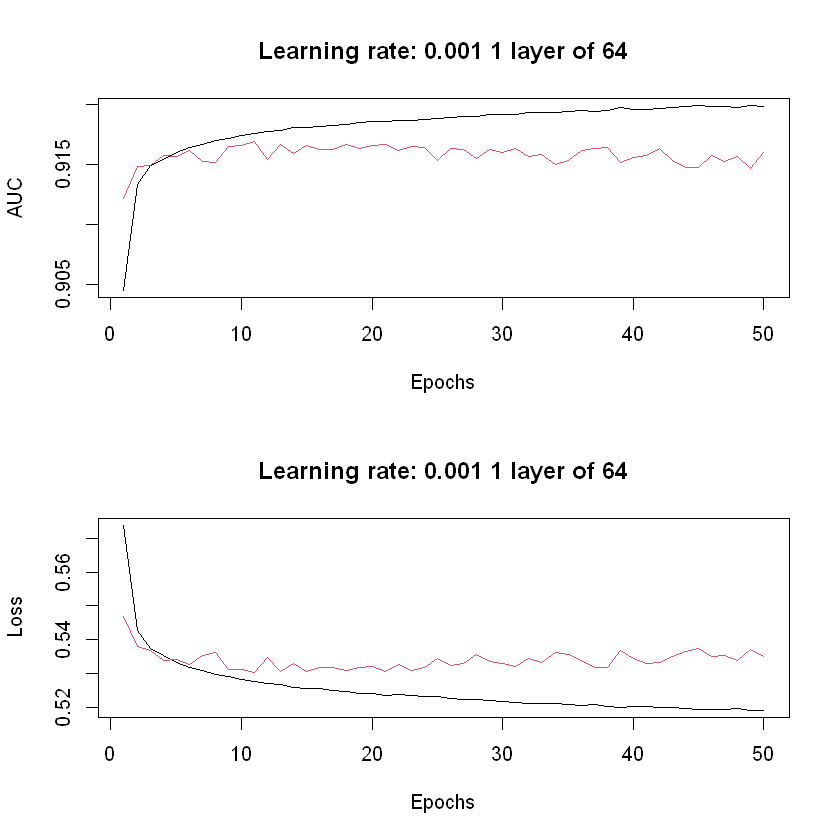

[1] "F1-Score Micro - 8 fold - Learning rate 1e-04 :  0.758197669932876"


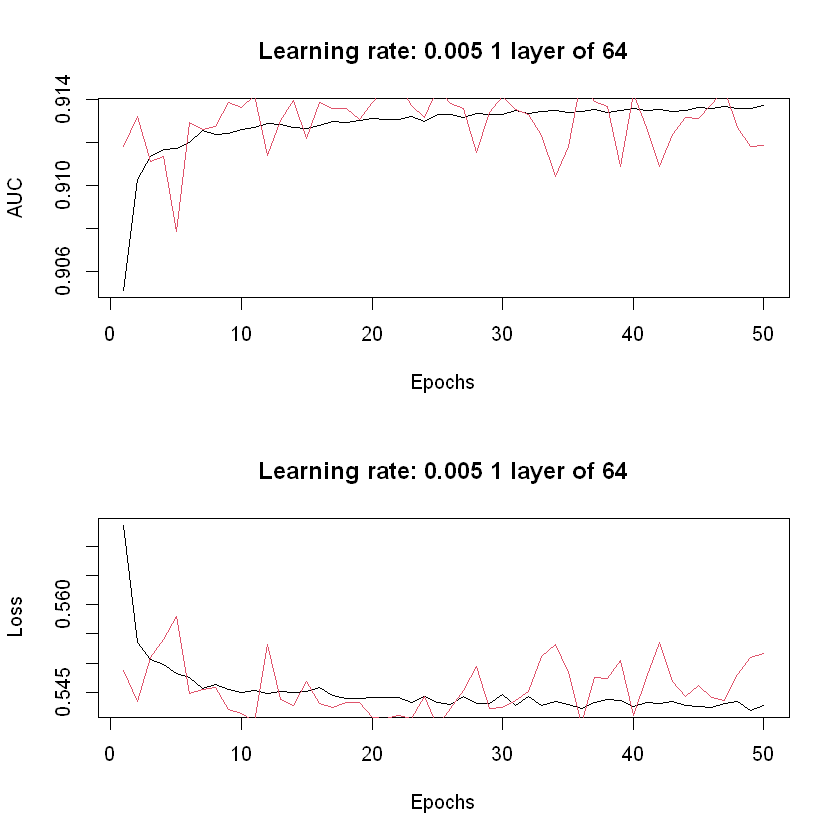

[1] "F1-Score Micro - 8 fold - Learning rate 5e-04 :  0.757156083635522"


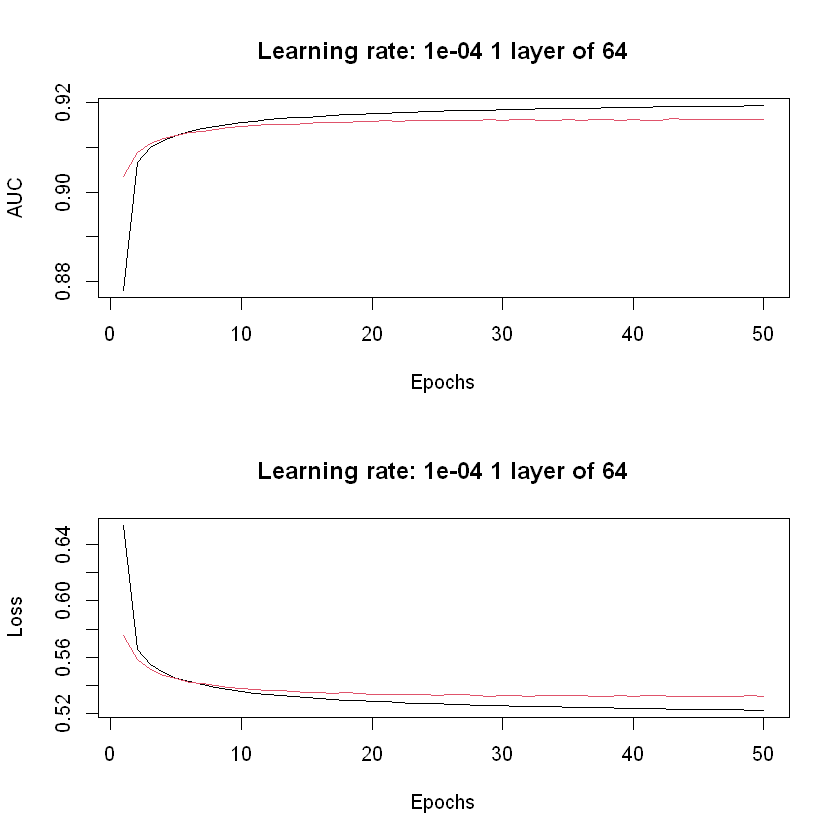

[1] "F1-Score Micro - 8 fold - Learning rate 0.001 :  0.755612992824628"


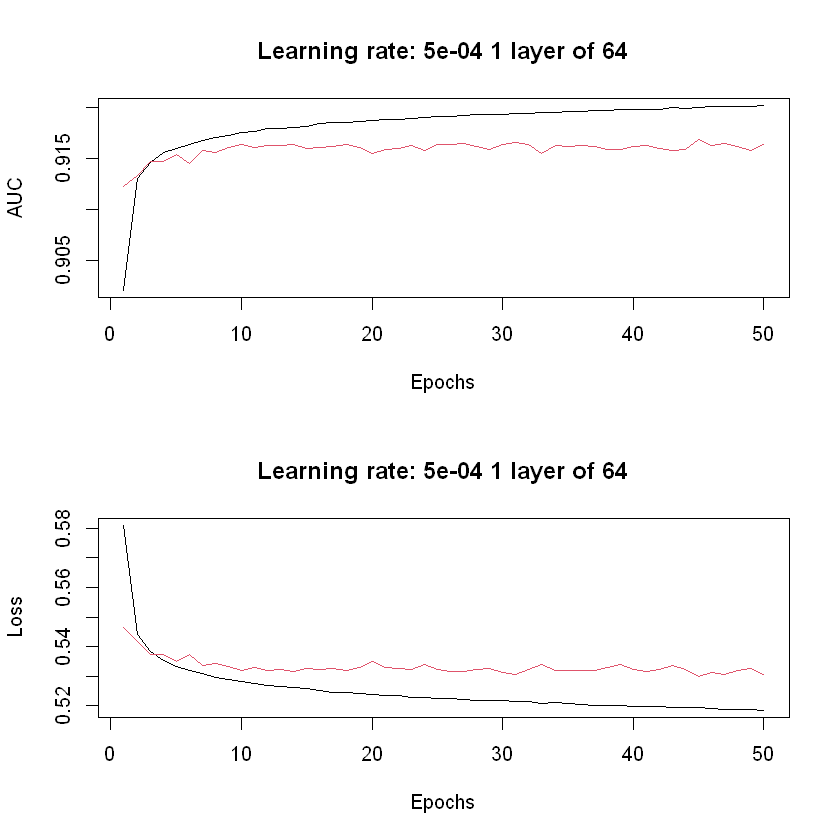

[1] "F1-Score Micro - 8 fold - Learning rate 0.005 :  0.754725715608363"
  |===============================================================       |  90%

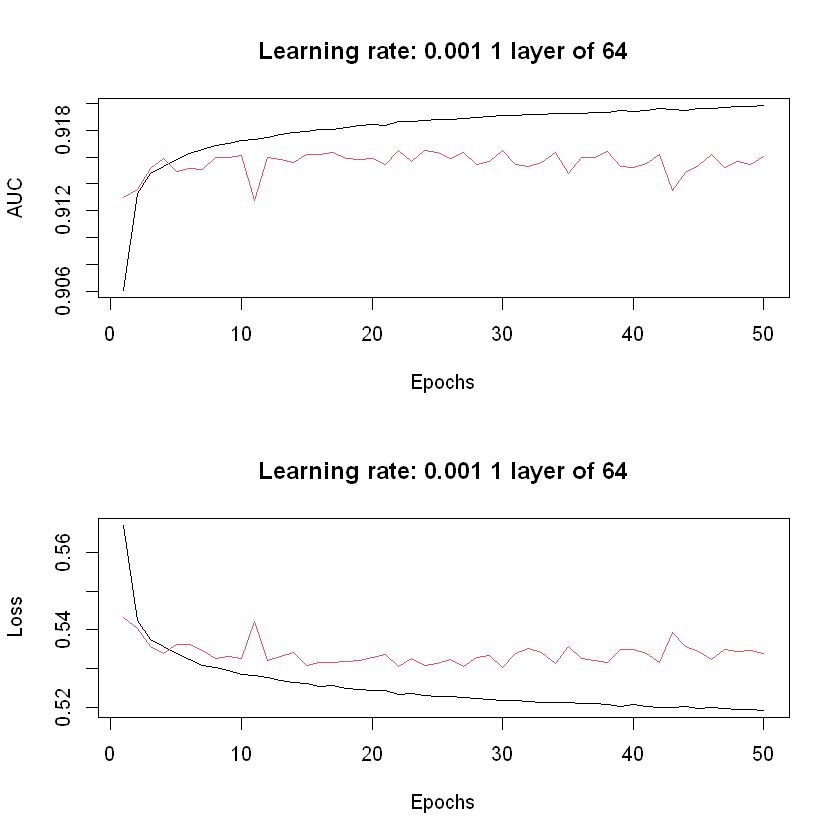

[1] "F1-Score Micro - 9 fold - Learning rate 1e-04 :  0.753182624797469"


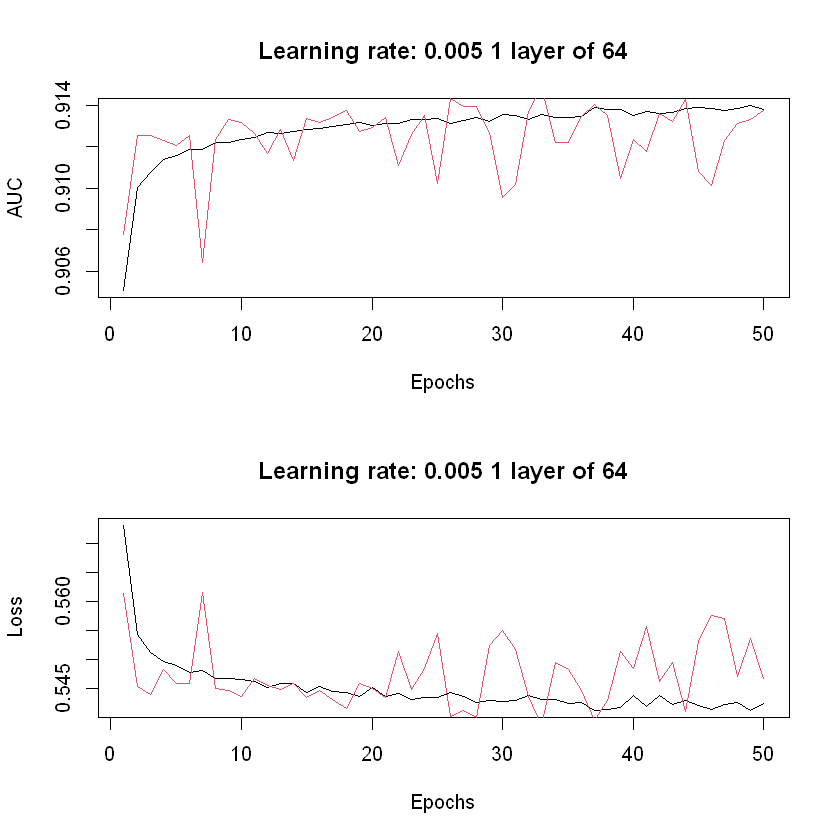

[1] "F1-Score Micro - 9 fold - Learning rate 5e-04 :  0.751523802175758"


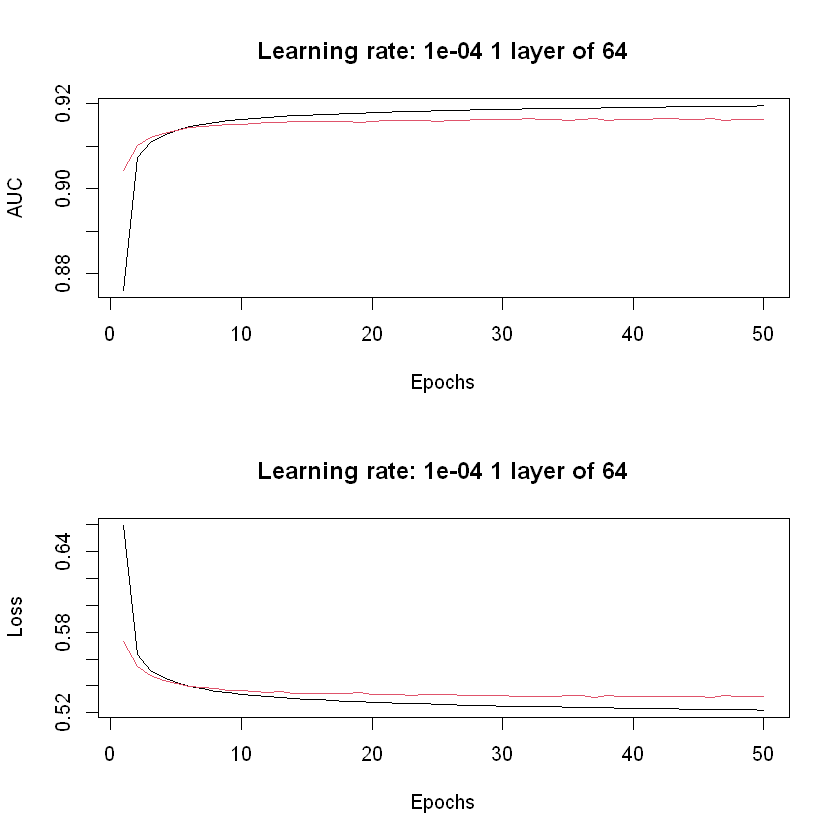

[1] "F1-Score Micro - 9 fold - Learning rate 0.001 :  0.74959493866214"


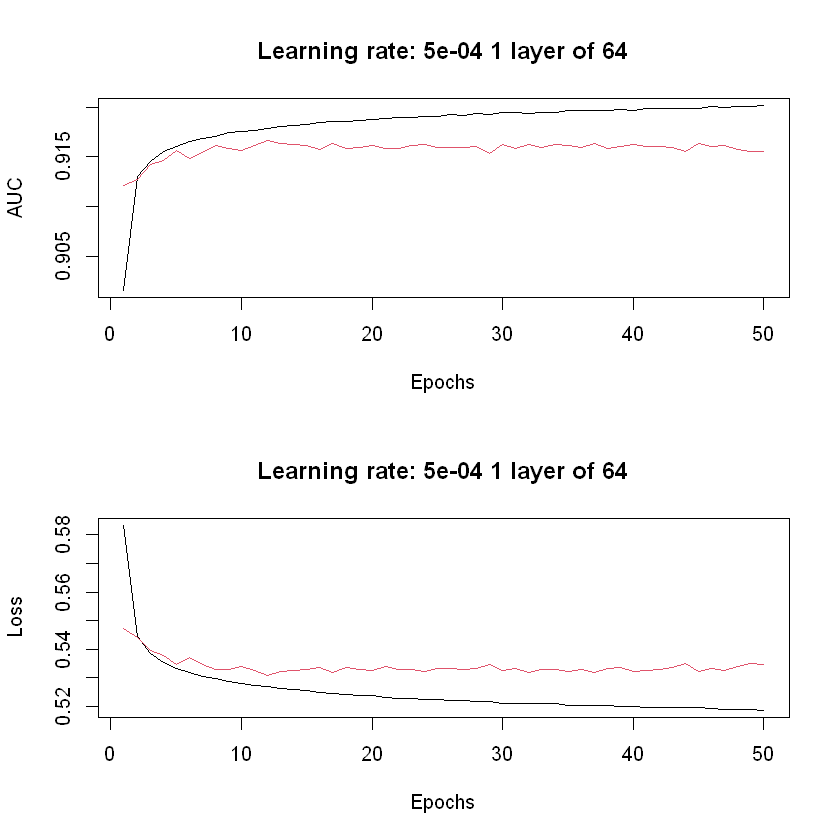

[1] "F1-Score Micro - 9 fold - Learning rate 0.005 :  0.750366484067587"
  |======================================================================| 100%

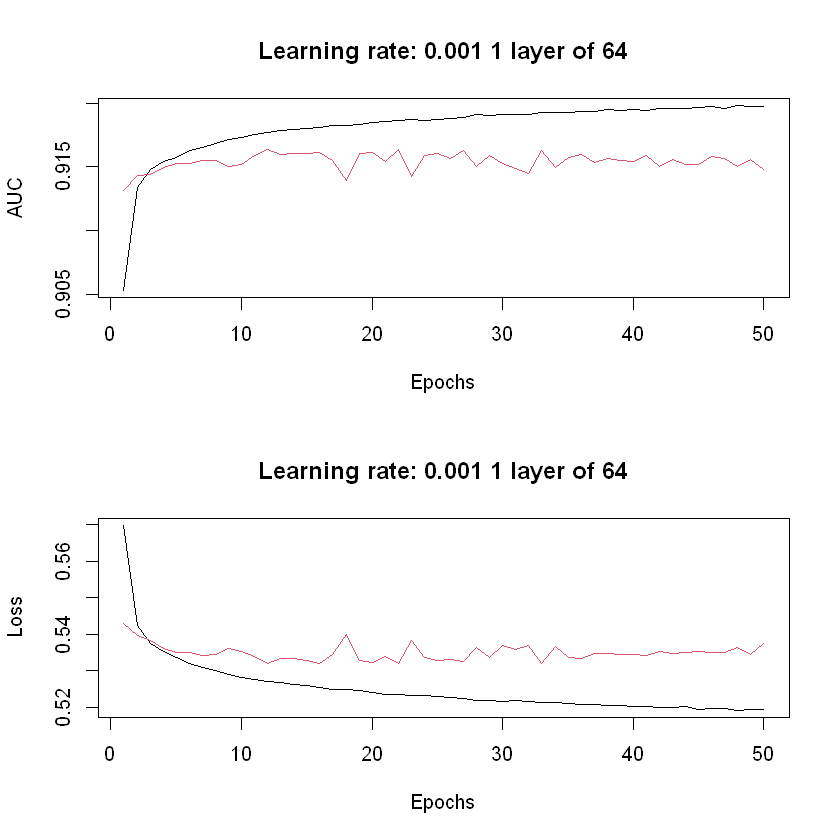

[1] "F1-Score Micro - 10 fold - Learning rate 1e-04 :  0.757727781422452"


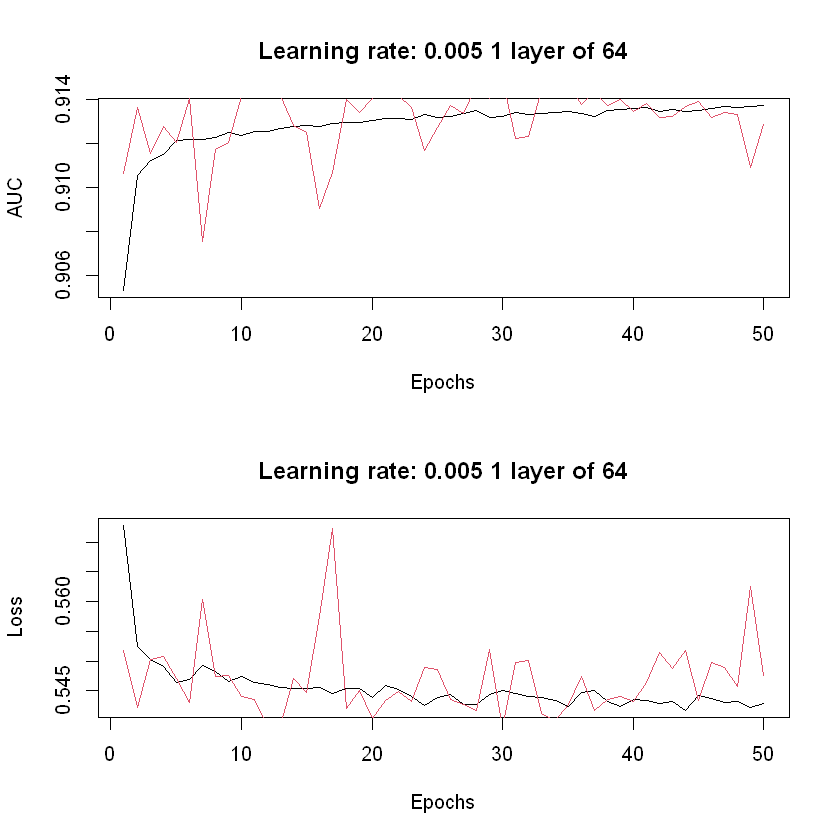

[1] "F1-Score Micro - 10 fold - Learning rate 5e-04 :  0.757882144097557"


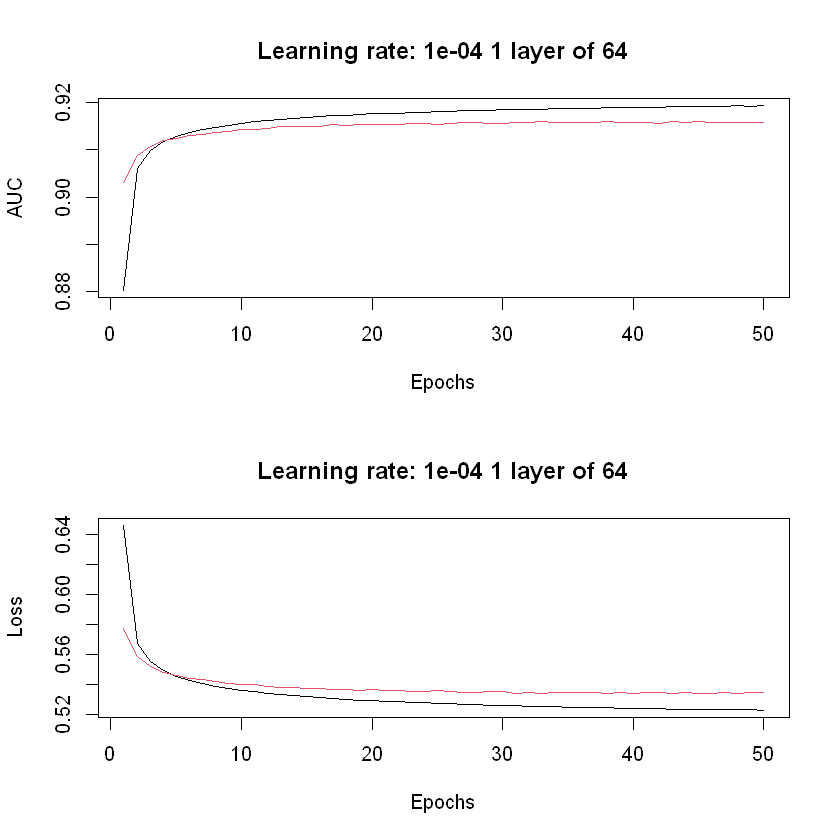

[1] "F1-Score Micro - 10 fold - Learning rate 0.001 :  0.757380465403465"


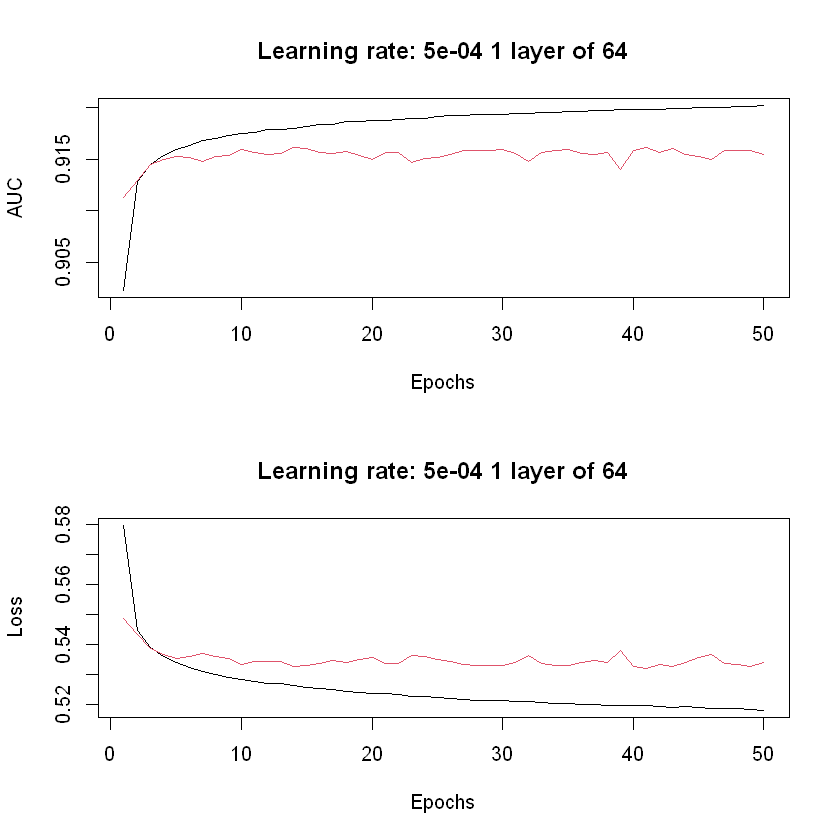

[1] "F1-Score Micro - 10 fold - Learning rate 0.005 :  0.75317408250685"


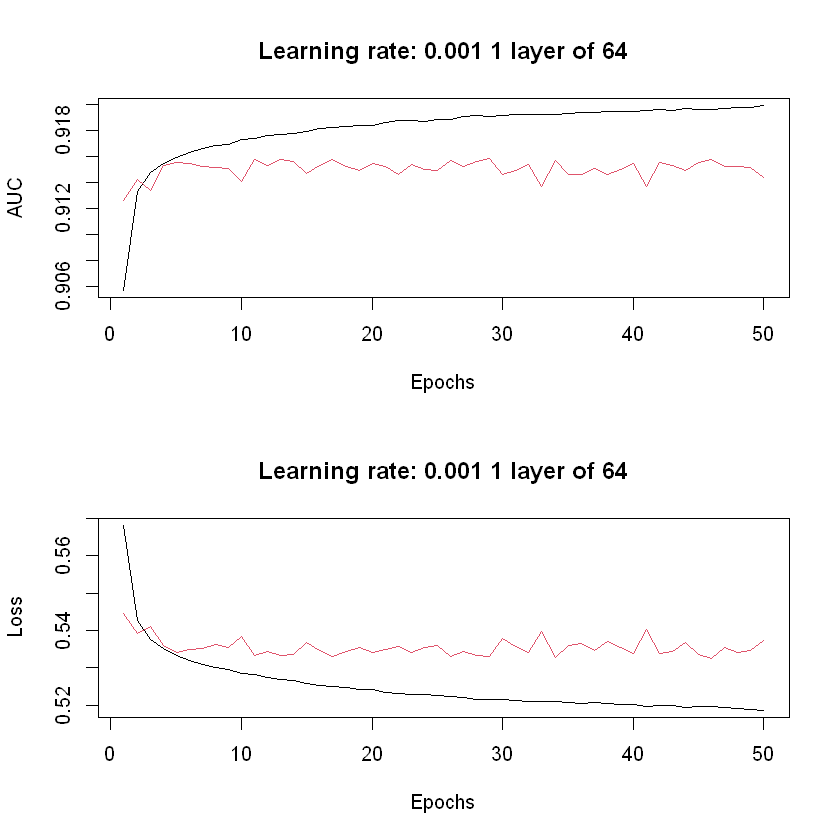

fold,mean_F1
<dbl>,<dbl>
1,0.7563074
2,0.7583423
3,0.7529608
4,0.7527776
5,0.7508005
6,0.7570982
7,0.7508101
8,0.7564231
9,0.7511670


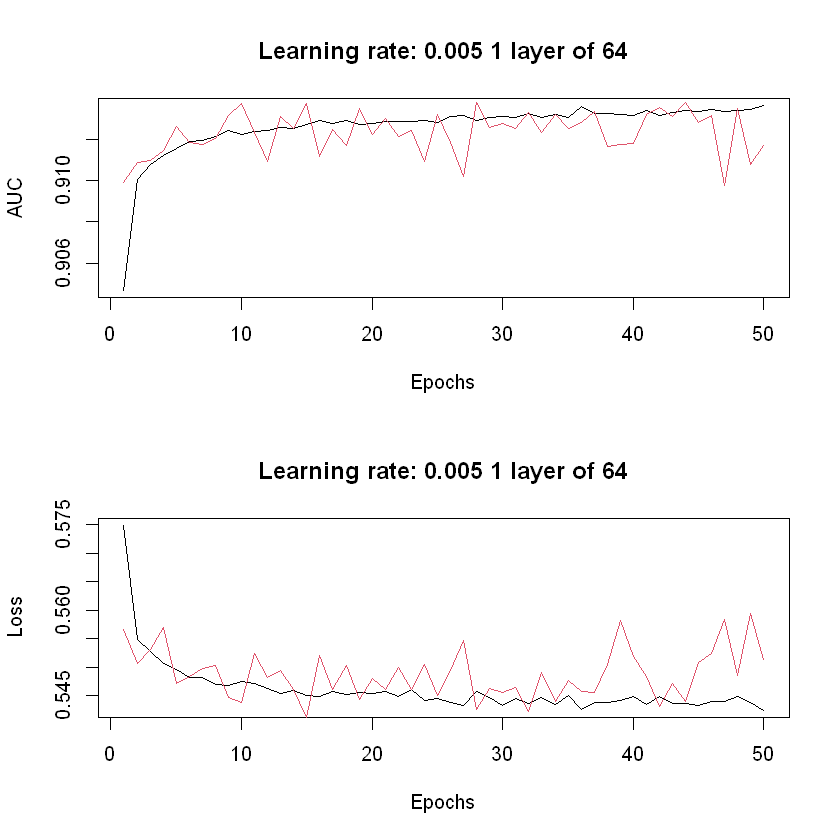

In [7]:
set.seed(2)
k = 10

accuracy_vec2 <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec2)<-c('fold','learning_rate','F1')

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005,0.001,0.005)){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(70, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_variables]),
        as.matrix(train_data[,target_variables]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

        yhaty <- classConverter(yhat,test_data)
        accuracy_vec2[nrow(accuracy_vec2)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,]))
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec2[nrow(accuracy_vec2),3]))
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '1 layer of 70','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '1 layer of 70','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history')
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
meanF1_2 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1_2)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005,0.001,0.005)){
    meanF1_2[nrow(meanF1_2)+1,]<-c(i,mean(filter(accuracy_vec2,(learning_rate==i))$F1))
}

accuracy_vec2
meanF1_2

#425 min

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - Learning rate 1e-04 :  0.756423115500347"
[1] "F1-Score Micro - 1 fold - Learning rate 5e-04 :  0.760666615230306"
  |==============                                                        |  20%

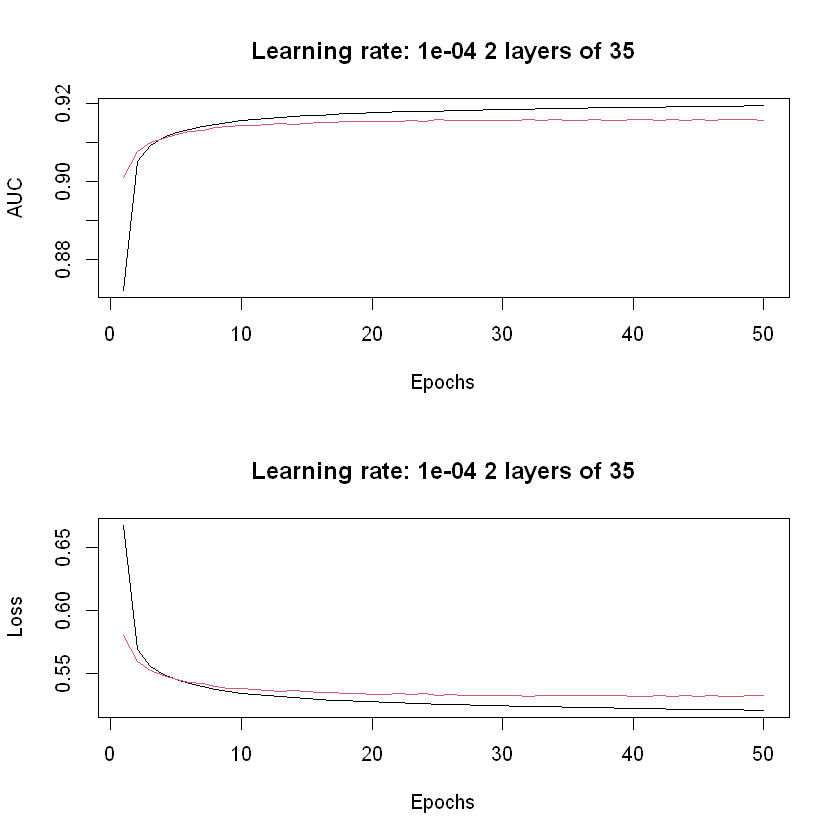

[1] "F1-Score Micro - 2 fold - Learning rate 1e-04 :  0.755883033716534"


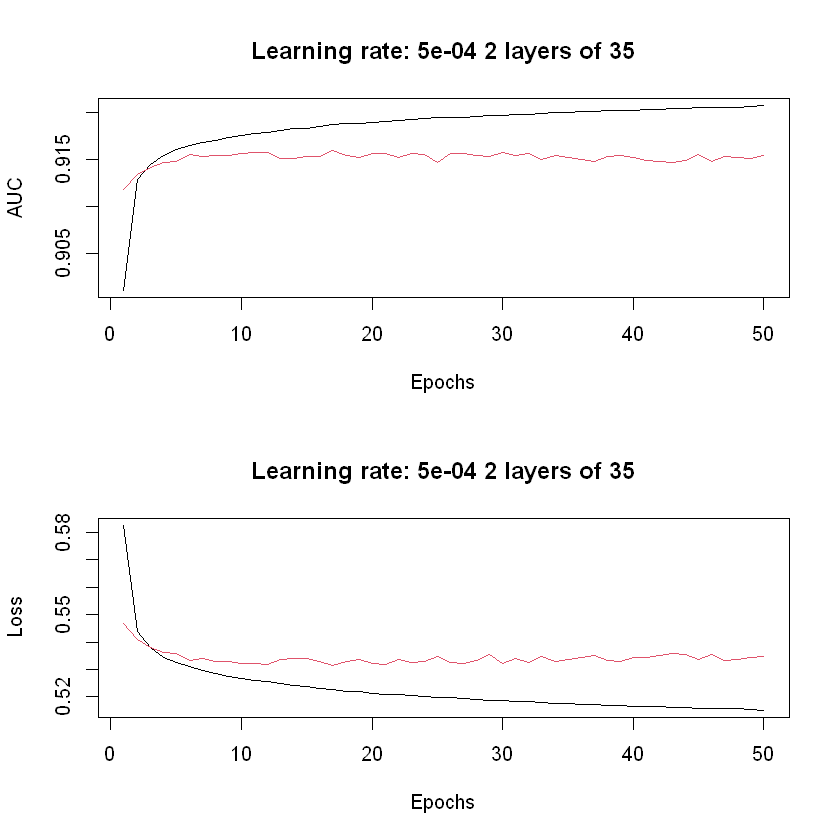

[1] "F1-Score Micro - 2 fold - Learning rate 5e-04 :  0.753414088419104"
  |=====================                                                 |  30%

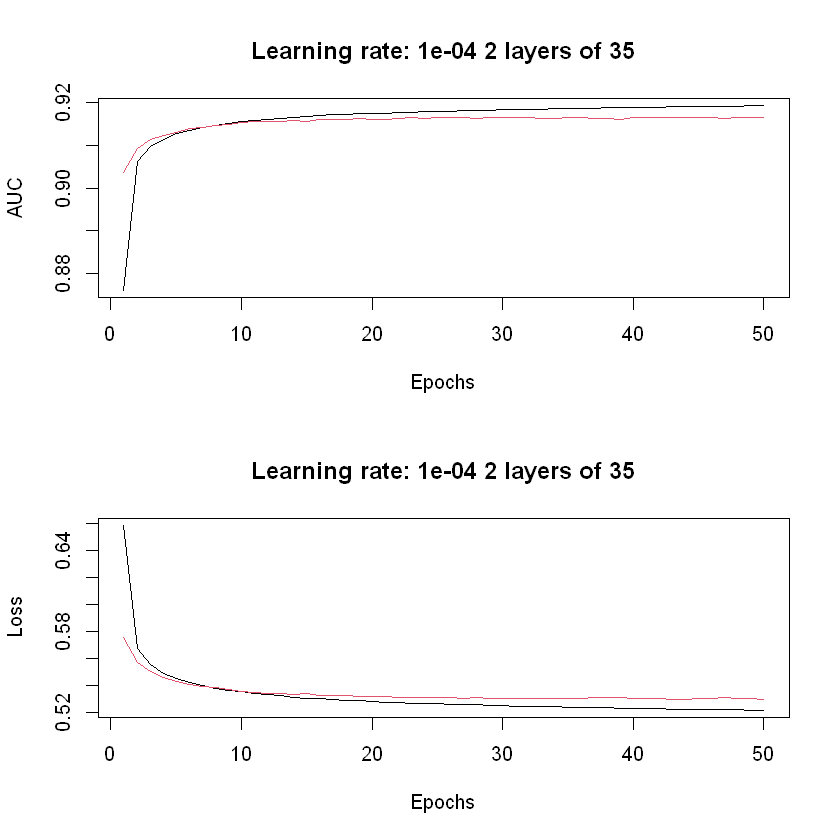

[1] "F1-Score Micro - 3 fold - Learning rate 1e-04 :  0.747704652418795"


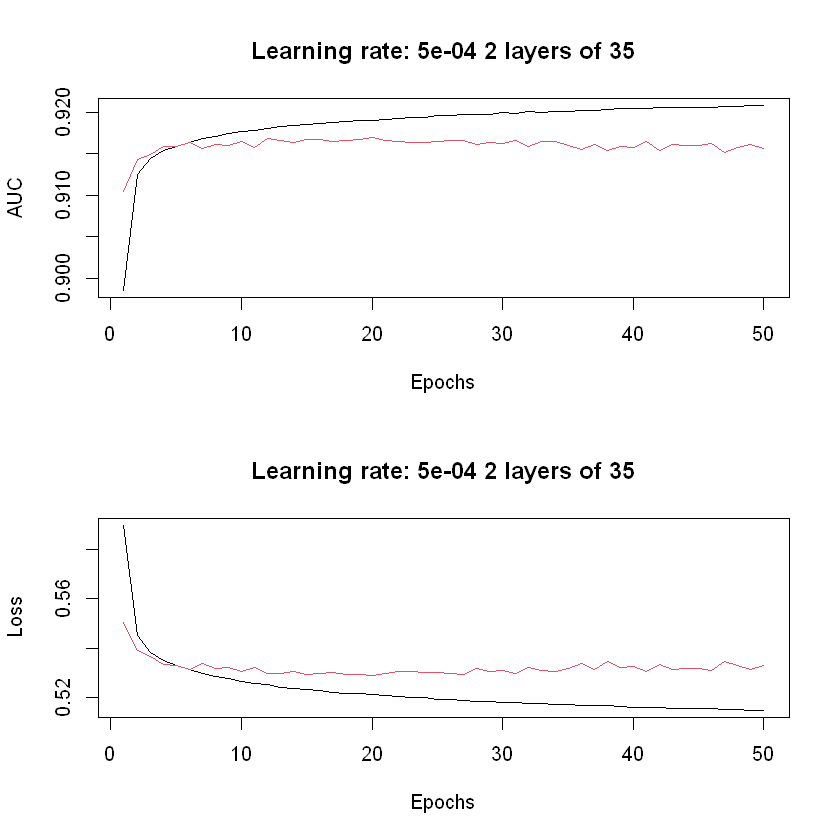

[1] "F1-Score Micro - 3 fold - Learning rate 5e-04 :  0.75171668852712"
  |============================                                          |  40%

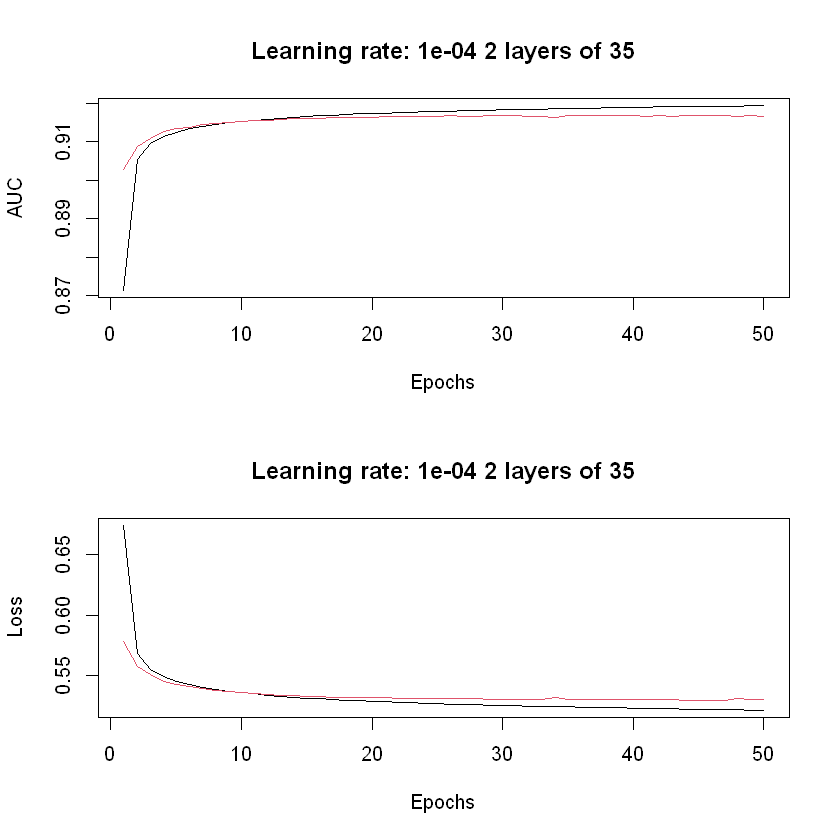

[1] "F1-Score Micro - 4 fold - Learning rate 1e-04 :  0.755342951932721"


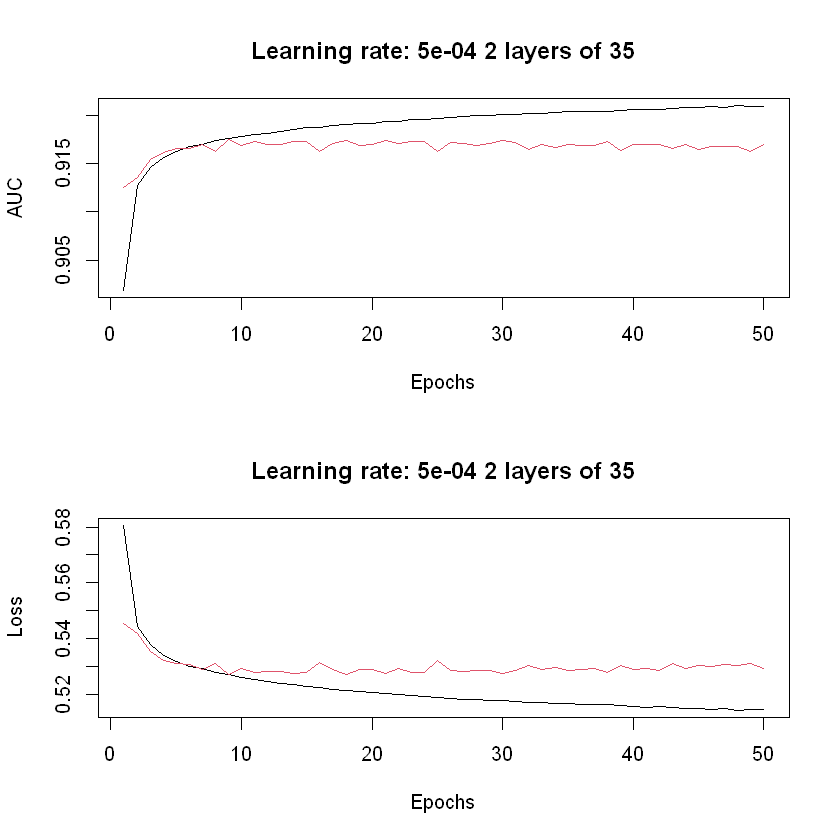

[1] "F1-Score Micro - 4 fold - Learning rate 5e-04 :  0.754687138338091"
  |===================================                                   |  50%

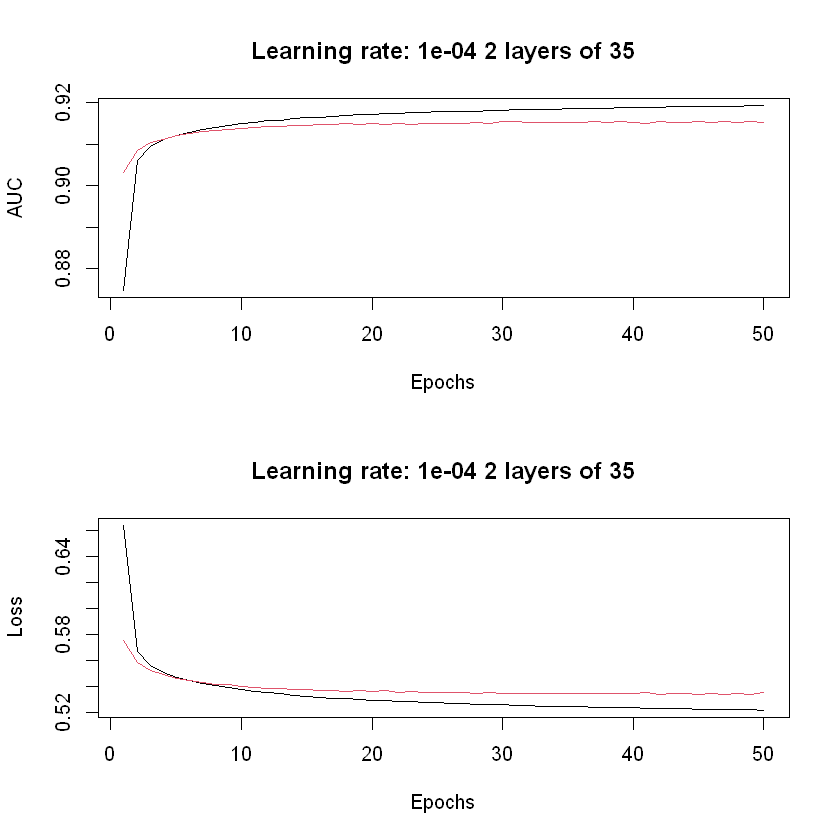

[1] "F1-Score Micro - 5 fold - Learning rate 1e-04 :  0.754108479284006"


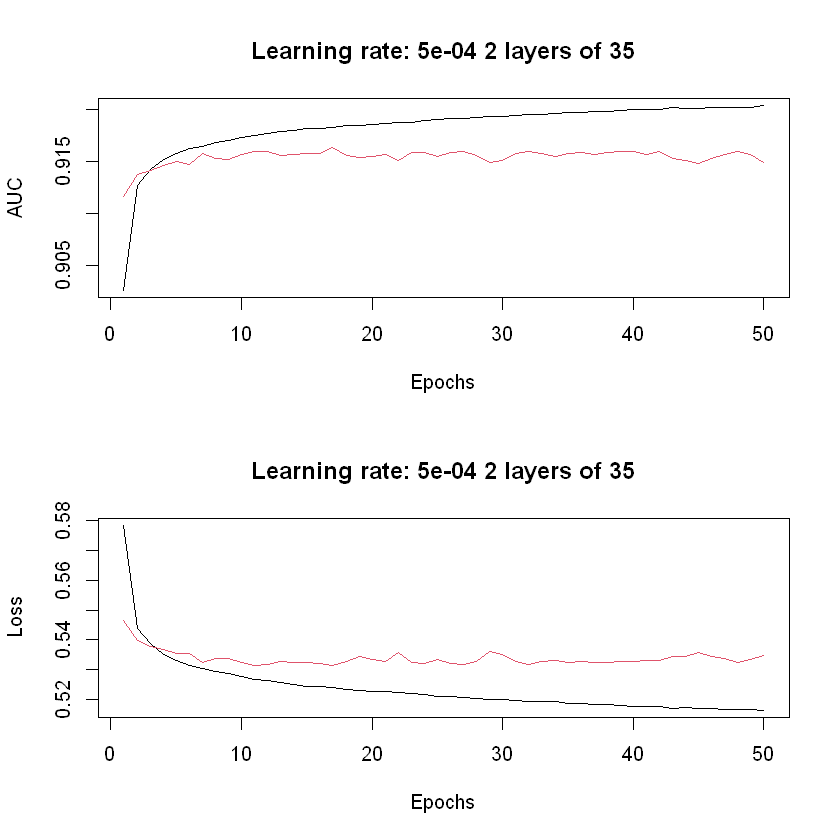

[1] "F1-Score Micro - 5 fold - Learning rate 5e-04 :  0.753452665689376"
  |==========================================                            |  60%

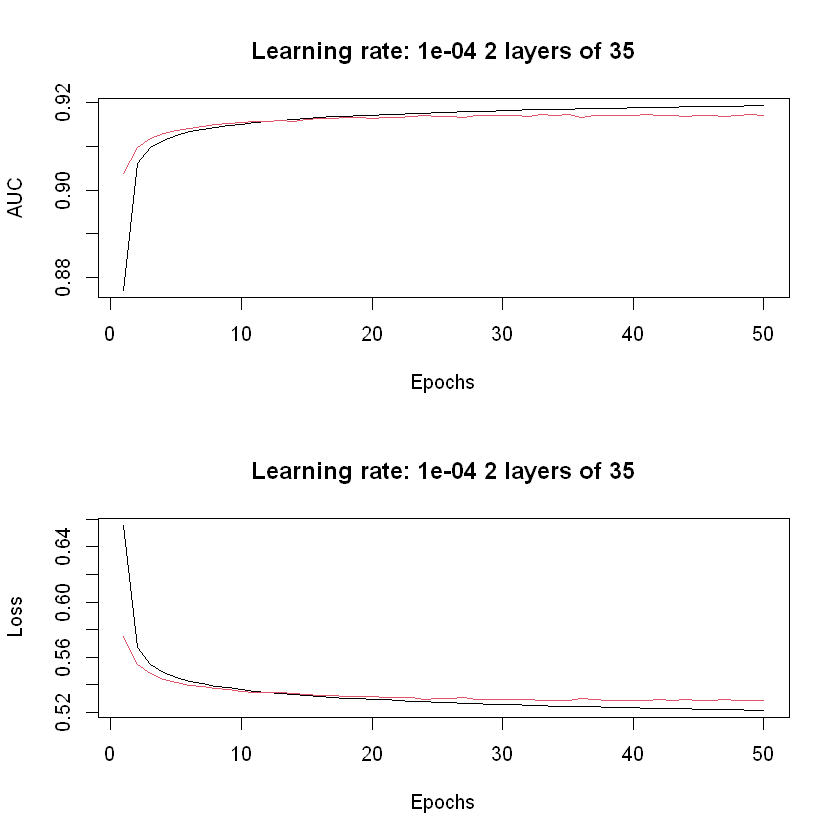

[1] "F1-Score Micro - 6 fold - Learning rate 1e-04 :  0.75646169277062"


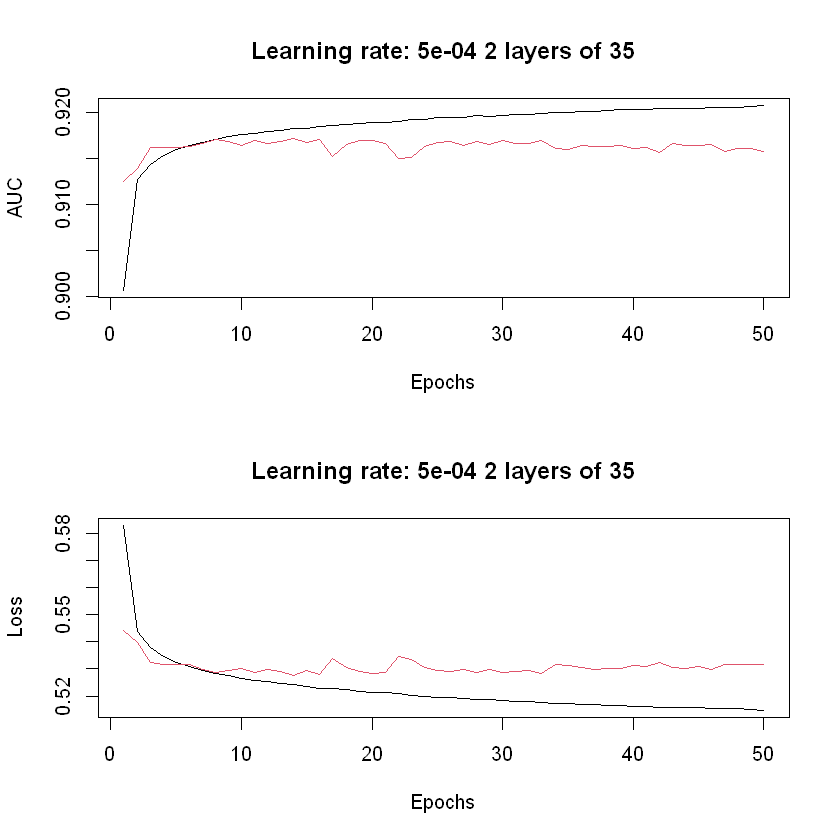

[1] "F1-Score Micro - 6 fold - Learning rate 5e-04 :  0.754301365635368"
  |=================================================                     |  70%

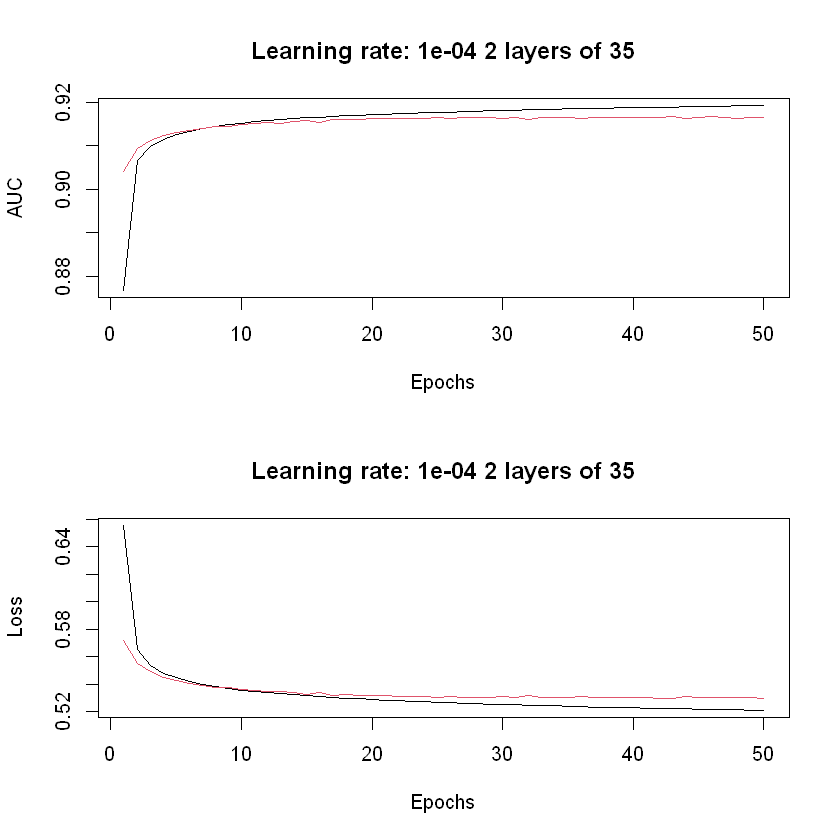

[1] "F1-Score Micro - 7 fold - Learning rate 1e-04 :  0.754802870148908"


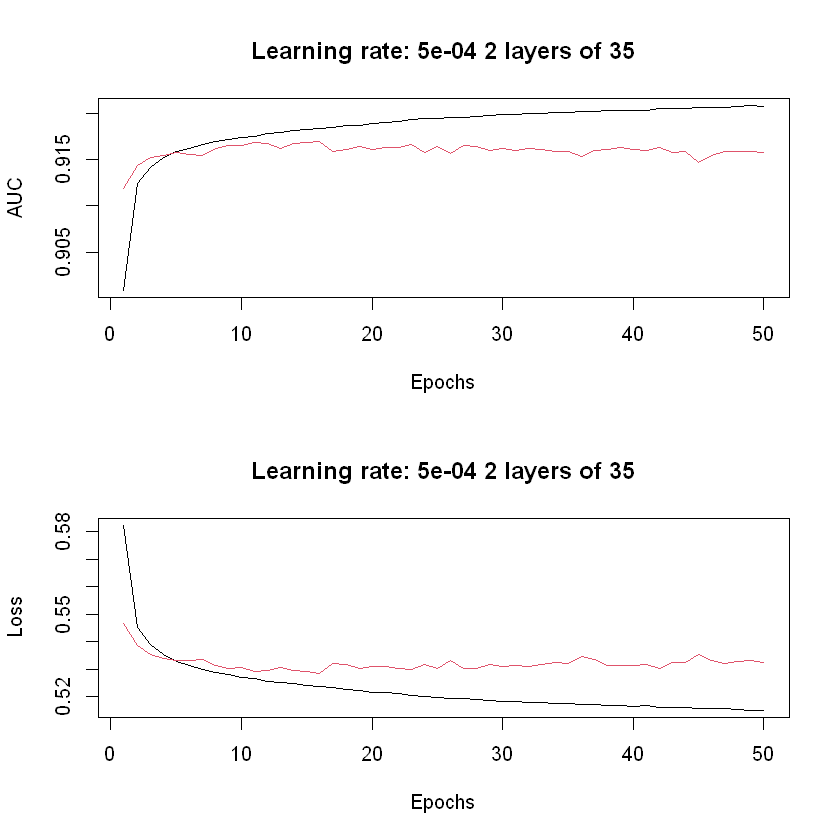

[1] "F1-Score Micro - 7 fold - Learning rate 5e-04 :  0.753915592932644"
  |========================================================              |  80%

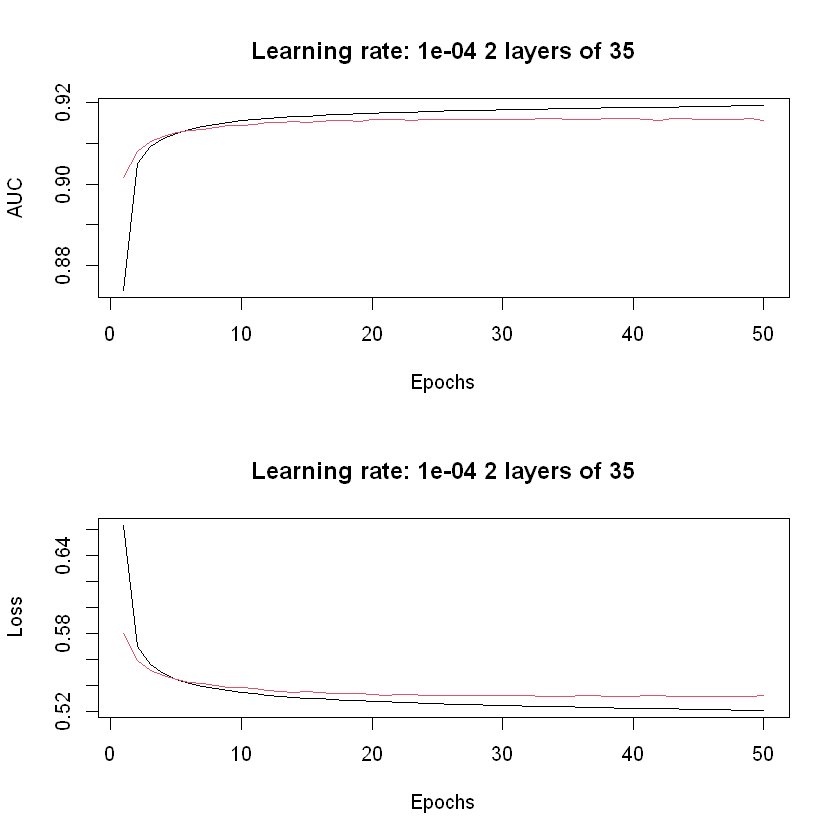

[1] "F1-Score Micro - 8 fold - Learning rate 1e-04 :  0.759547874392408"


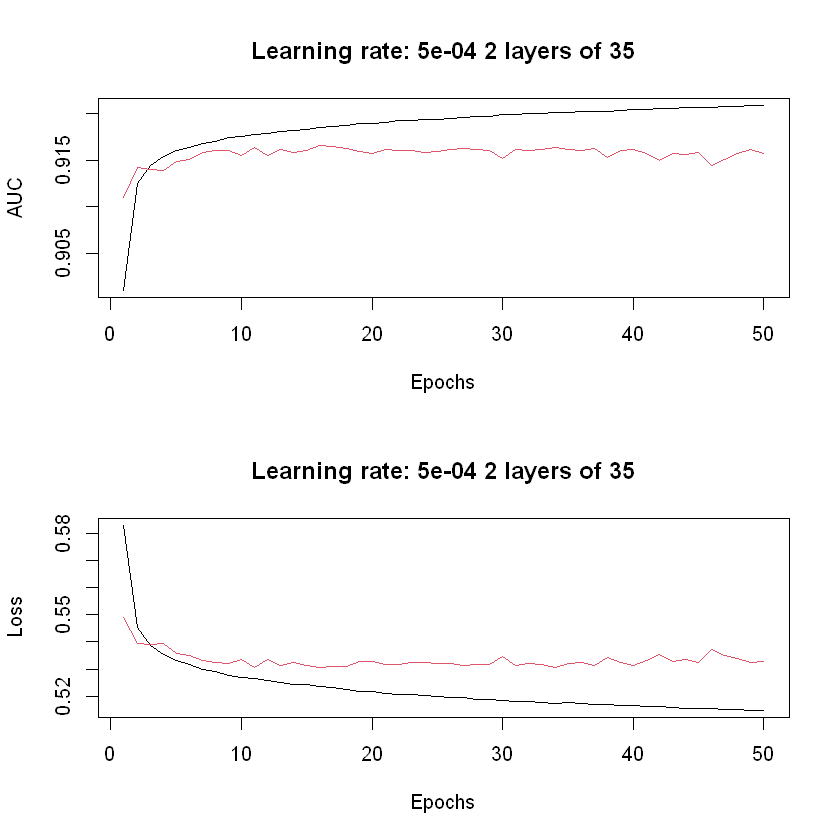

[1] "F1-Score Micro - 8 fold - Learning rate 5e-04 :  0.759354988041046"
  |===============================================================       |  90%

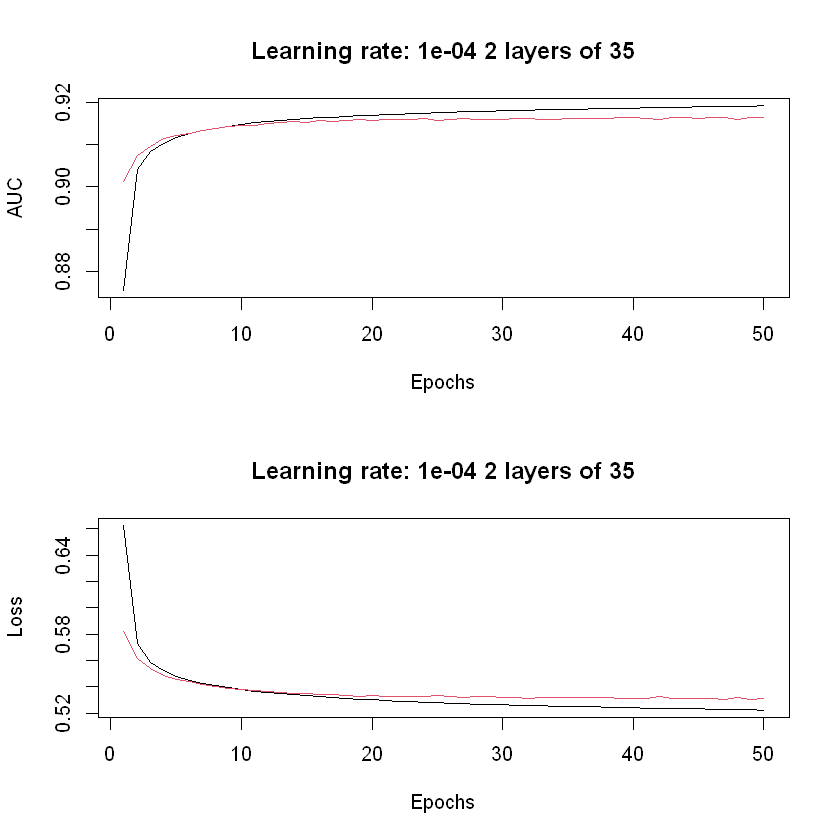

[1] "F1-Score Micro - 9 fold - Learning rate 1e-04 :  0.759702183473497"


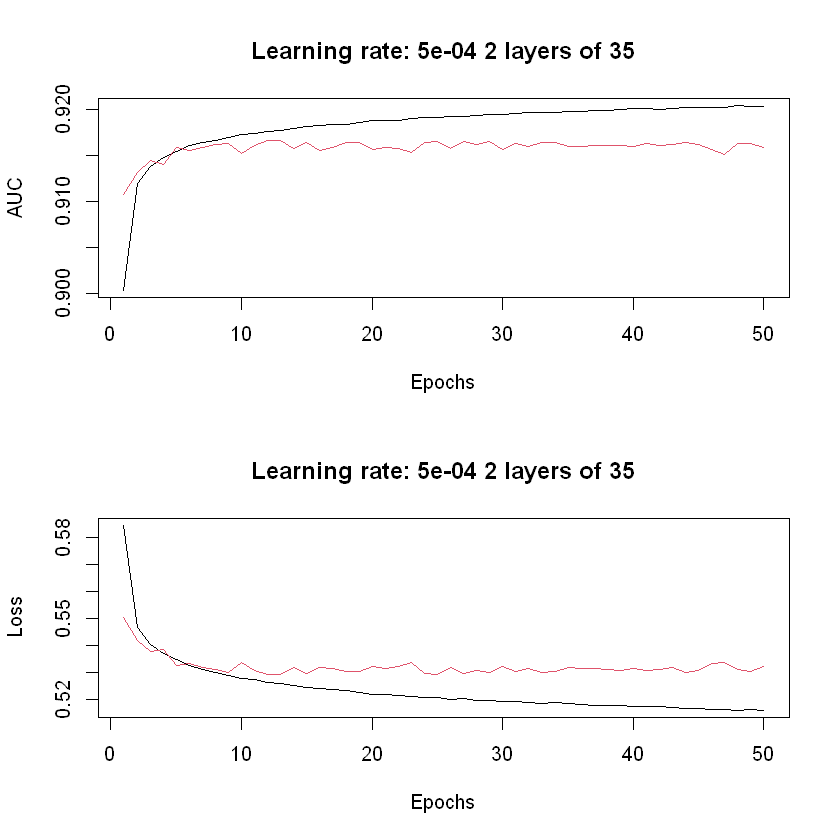

[1] "F1-Score Micro - 9 fold - Learning rate 5e-04 :  0.758660597176144"
  |======================================================================| 100%

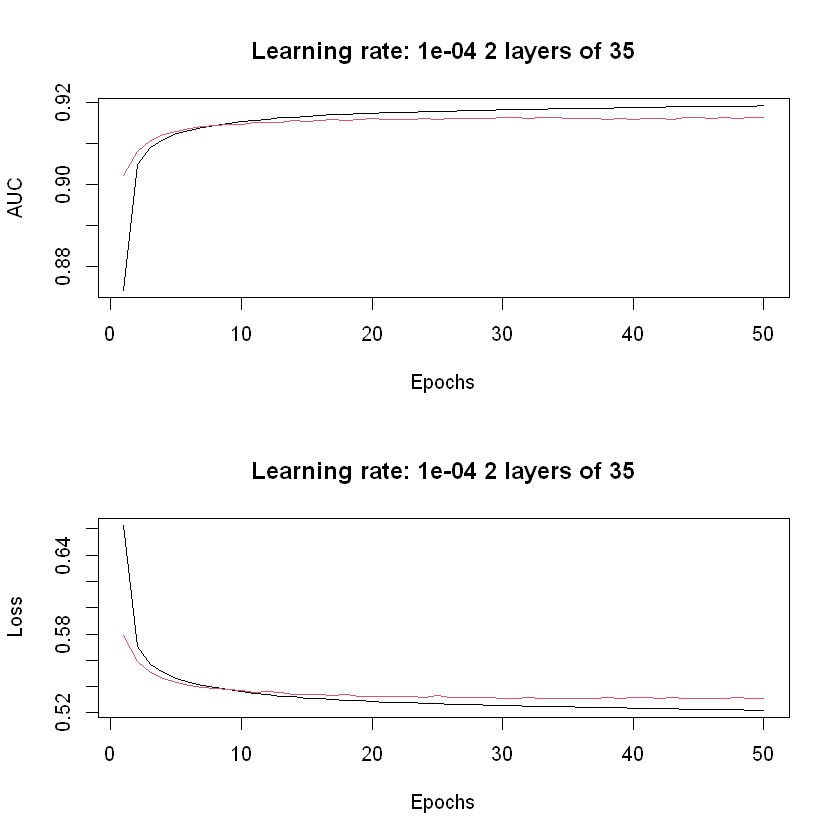

[1] "F1-Score Micro - 10 fold - Learning rate 1e-04 :  0.753714351869718"


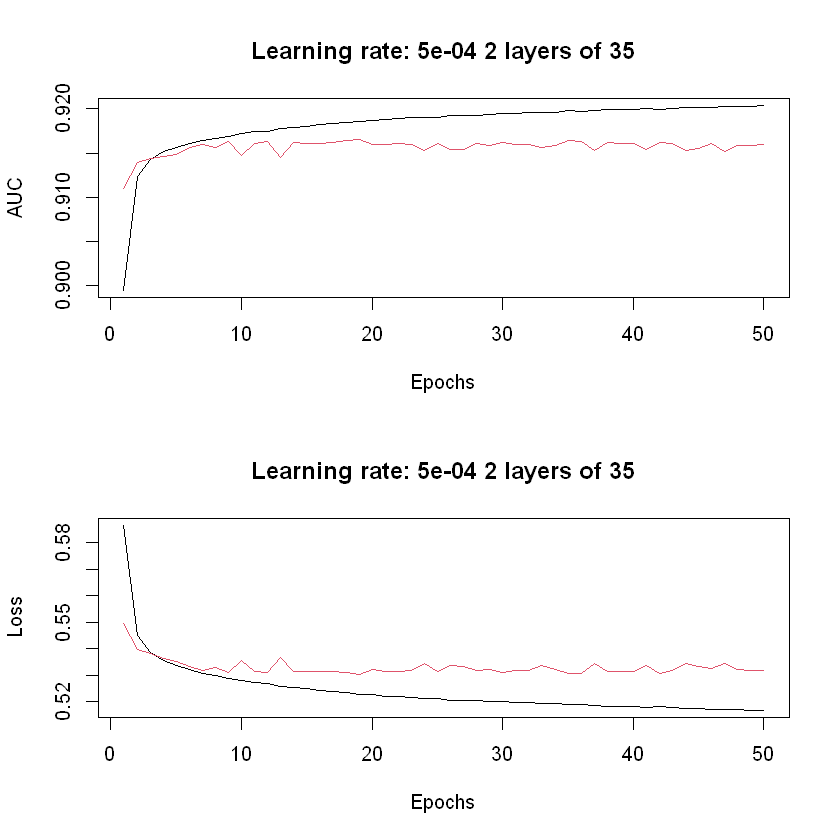

[1] "F1-Score Micro - 10 fold - Learning rate 5e-04 :  0.753830123876047"


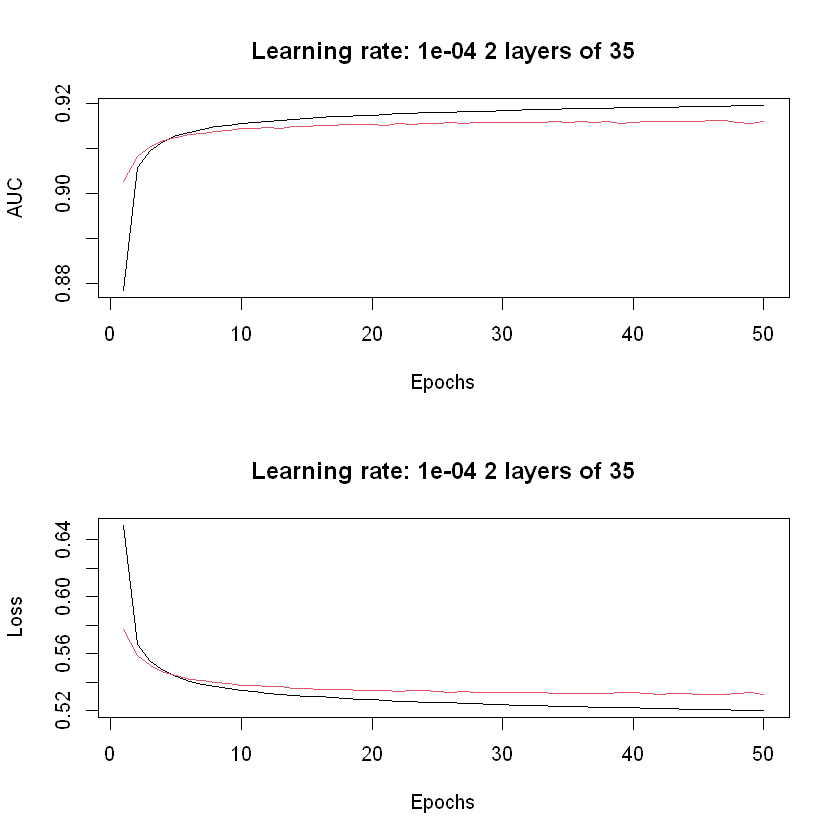

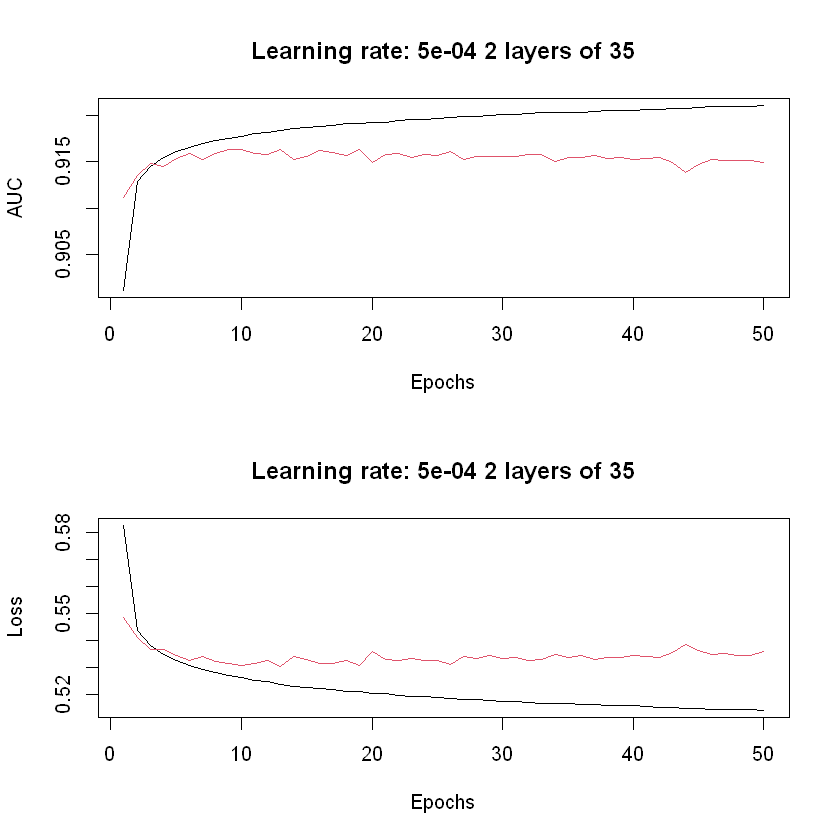

In [14]:
set.seed(2)
k = 10

accuracy_vec3 <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec3)<-c('fold','learning_rate','F1')

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005)){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(37, activation = 'relu') %>%
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_variables]),
        as.matrix(train_data[,target_variables]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

        yhaty <- classConverter(yhat,test_data)
        accuracy_vec3[nrow(accuracy_vec3)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,]))
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec3[nrow(accuracy_vec3),3]))
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '2 layers of 35','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '2 layers of 35','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history')
    }
}
meanF1_3 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1_3)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005)){
    meanF1_3[nrow(meanF1_3)+1,]<-c(i,mean(filter(accuracy_vec3,(learning_rate==i))$F1))
}
accuracy_vec3
meanF1_3
#219 min

In [15]:
meanF1_3
meanF1_2
meanF1

,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7553691
2,5e-04,0.7554000
3,1e-03,NaN
4,5e-03,NaN


,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7556856
2,5e-04,0.7556084
3,1e-03,0.7546826
4,5e-03,0.7513146


,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7561331
2,5e-04,0.7560559
3,1e-03,0.7555389
4,5e-03,0.7507784
